
# GAN-powered ML Improvement — Neuroblastoma EHRs (Colab)

_Colab-ready, modular notebook to enhance ML effectiveness on neuroblastoma-related datasets via **GAN-based augmentation**, **imputation**, and optional **Differential Privacy**._

**Last generated:** 2025-09-30 07:17 UTC


## Part 1 — Configuration & Setup (Mount dataset first)

In [54]:
# ▶ Dataset loaded directly from the Neuroblastoma EHRs Open Data Repository
# (Chicco et al., 2022) — no Google Drive or manual download needed.

DATA_PATH = 'https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/GSE3960_cleaned_data.csv'

# Project flags
USE_GPU = False
ENABLE_DIFFERENTIAL_PRIVACY = False
RANDOM_SEED = 42

print('Configured DATA_PATH =', DATA_PATH)


Configured DATA_PATH = https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/GSE3960_cleaned_data.csv


In [55]:
# Part 1 — Configuration & Setup (URL-based, no Drive mount required)

import os, subprocess, json

# DATA_PATH is already set to the public URL in the cell above.
# No Google Drive mount is needed — pandas reads CSVs from URLs directly.

# --- Runtime & training configuration ---
ENABLE_DIFFERENTIAL_PRIVACY = False
RANDOM_SEED = 42

# --- GPU detection (same logic as before) ---
AUTO_SELECT_GPU = True
FORCE_CPU = False
USE_GPU = False

def _probe_nvidia_smi():
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader,nounits'],
            stderr=subprocess.STDOUT
        )
        first = out.decode('utf-8').strip().splitlines()[0]
        name, mem = [x.strip() for x in first.split(',')]
        return name, int(mem)
    except Exception:
        return None, None

GPU_NAME, GPU_MEM_MB = _probe_nvidia_smi()

try:
    import torch
    CUDA_OK = torch.cuda.is_available()
except Exception:
    CUDA_OK = False

if FORCE_CPU:
    DEVICE = 'cpu'; USE_GPU = False
elif AUTO_SELECT_GPU and CUDA_OK:
    DEVICE = 'cuda'; USE_GPU = True
else:
    DEVICE = 'cuda' if (not AUTO_SELECT_GPU and CUDA_OK) else 'cpu'
    USE_GPU = (DEVICE == 'cuda')

def recommended_batch_size(default_cpu=256, default_gpu=1024):
    if not USE_GPU or GPU_MEM_MB is None: return default_cpu
    if GPU_MEM_MB >= 22000: return max(default_gpu, 2048)
    if GPU_MEM_MB >= 15000: return max(default_gpu, 1536)
    if GPU_MEM_MB >= 8000:  return max(default_gpu, 1024)
    return 768

print('[Runtime]')
print(f'  DEVICE            : {DEVICE}')
print(f'  USE_GPU           : {USE_GPU}')
print(f'  GPU_NAME          : {GPU_NAME}')
print(f'  GPU_MEM_MB        : {GPU_MEM_MB}')
print(f'  SUGGESTED BATCH   : {recommended_batch_size()}')
print(f'  DATA_PATH         : {DATA_PATH}')


[Runtime]
  DEVICE            : cuda
  USE_GPU           : True
  GPU_NAME          : NVIDIA L4
  GPU_MEM_MB        : 23034
  SUGGESTED BATCH   : 2048
  DATA_PATH         : https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/GSE3960_cleaned_data.csv


### Part 1b — Environment installs

In [56]:
# Part 1b — Environment installs

# --- Core scientific stack ---
!pip -q install pandas numpy scikit-learn matplotlib plotly requests beautifulsoup4 ipywidgets==8.1.2

# --- Clean previous conflicting installs (if any) ---
!pip -q uninstall -y sdv sdmetrics ctgan || true

# --- SDV (will pull a compatible sdmetrics) ---
# Try latest 1.27.x first; if dependency resolver fails, fall back to 1.26.x
!pip -q install "sdv>=1.27,<1.28" || pip -q install "sdv>=1.26,<1.27"

# --- Optional extras (do not block if unavailable) ---
# Additional imputers (optional). Safe to skip if not needed.
!pip -q install fancyimpute || echo "fancyimpute not available; skipping."

# Time-series/tabular generative models (optional). Skip if wheel is not provided for this Python.
!pip -q install ydata-synthetic || echo "ydata-synthetic not available for this Python; skipping."

# Differential Privacy (DP-SGD). Skip safely if incompatible with current PyTorch/CPU runtime.
!pip -q install opacus || echo "opacus not available for this Python; skipping."

# --- Sanity check: print resolved versions (ensure sdv pulled sdmetrics) ---
import importlib, sys
try:
    import sdv
    print("sdv version:", sdv.__version__)
    try:
        import sdmetrics
        print("sdmetrics version:", sdmetrics.__version__)
    except Exception as e:
        print("sdmetrics import error:", e)
except Exception as e:
    print("sdv import error:", e)


ERROR: Ignored the following versions that require a different python version: 0.0.0 Requires-Python >=3.6, <3.9; 0.1.1 Requires-Python >=3.6, <3.9; 0.1.2 Requires-Python >=3.6, <3.9; 0.1.3 Requires-Python >=3.6, <3.9; 0.10.0 Requires-Python >=3.8, <3.11; 0.2.0 Requires-Python >=3.6, <3.9; 0.2.1 Requires-Python >=3.6, <3.9; 0.2.2 Requires-Python >=3.6, <3.9; 0.2.3 Requires-Python >=3.6, <3.9; 0.2.4 Requires-Python >=3.6, <3.9; 0.3.0 Requires-Python >=3.6, <3.9; 0.3.1 Requires-Python >=3.6, <3.9; 0.3.2 Requires-Python >=3.6, <3.9; 0.3.3 Requires-Python >=3.6, <3.9; 0.3.4 Requires-Python >=3.6, <3.9; 0.4.0 Requires-Python >=3.6, <3.9; 0.5.0 Requires-Python >=3.6, <3.9; 0.6.0 Requires-Python >=3.6, <3.9; 0.6.1 Requires-Python >=3.6, <3.9; 0.7.0 Requires-Python >=3.6, <3.9; 0.7.1 Requires-Python >=3.6, <3.9; 0.8.0 Requires-Python >=3.6, <3.9; 0.9.0 Requires-Python >=3.8, <3.11; 1.0.0 Requires-Python >=3.8, <3.11; 1.0.1 Requires-Python >=3.8, <3.11; 1.1.0 Requires-Python >=3.9, <3.11; 1.2.0

In [57]:
# ============================================================
# Validation strategy configuration
# ============================================================
# Repeated hold-out (Monte Carlo cross-validation. Each iteration: independent stratified random split.
# Use N_REPEATS=100 for final results, N_REPEATS=10 for quick tests.

N_REPEATS = 100          # number of repeated hold-out iterations

HOLDOUT_TEST_SIZE = 0.20  # 80/20 train/test per iteration

print(f"Validation: Repeated hold-out with {N_REPEATS} iterations, "
      f"test_size={HOLDOUT_TEST_SIZE}")

Validation: Repeated hold-out with 100 iterations, test_size=0.2


## Part 2 — Dataset Ingestion & Basic Profiling

In [58]:

import pandas as pd, numpy as np, json, os, io, sys, math, warnings
warnings.filterwarnings('ignore')

def load_table(path_or_url: str) -> pd.DataFrame:
    lower = path_or_url.lower()
    if lower.endswith('.csv'):   return pd.read_csv(path_or_url)
    if lower.endswith('.tsv') or lower.endswith('.txt'): return pd.read_csv(path_or_url, sep='\t')
    if lower.endswith('.xlsx') or lower.endswith('.xls'): return pd.read_excel(path_or_url)
    if lower.endswith('.json'):  return pd.read_json(path_or_url)
    try:
        return pd.read_csv(path_or_url)
    except Exception:
        return pd.read_csv(path_or_url, sep='\t')

df = load_table(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
profile = {
    "rows": int(len(df)),
    "cols": int(df.shape[1]),
    "missing_rate_overall": float(df.isna().mean().mean()),
    "numeric_cols": int((df.dtypes != 'object').sum()),
    "categorical_cols": int((df.dtypes == 'object').sum())
}
print(json.dumps(profile, indent=2))


Shape: (101, 8)


,age_diagnosis_days,INSS_stage,MYCN_amplification,1p36_LOH,1p23_LOH,unbalanced11qLOH,17q_gain,tumor_percentage
0,9,1,0,0.0,0,0,0.0,90.0
1,12,1,0,0.0,0,0,0.0,90.0
2,17,1,0,0.0,0,0,0.0,100.0
3,19,1,0,0.0,1,0,0.0,95.0
4,26,1,0,0.0,0,0,0.0,NaN


{
  "rows": 101,
  "cols": 8,
  "missing_rate_overall": 0.035891089108910895,
  "numeric_cols": 6,
  "categorical_cols": 2
}


In [59]:
# ============================================================
# Part 2b — Evaluation helper: all reviewer-requested metrics
# ============================================================
# Computes 7 metrics per iteration:
#   - AUROC, AUPRC  (threshold-free, rank-based)
#   - MCC, Sensitivity, Specificity, Precision, NPV  (threshold = 0.5)
#
# Usage:  row = compute_all_metrics(y_true, y_proba)
# Returns a dict ready to be appended to fold_results list.
# ============================================================

import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
)

CLASSIFICATION_THRESHOLD = 0.5   # transparent, standard

def compute_all_metrics(y_true, y_proba, threshold=CLASSIFICATION_THRESHOLD):
    """
    Compute all reviewer-requested metrics from true labels and
    predicted probabilities for the positive class.

    Returns
    -------
    dict with keys: auroc, auprc, mcc, sensitivity, specificity,
                    precision, npv
    """
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_proba).ravel()

    # --- Threshold-free ---
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    # --- Threshold-dependent ---
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    mcc = matthews_corrcoef(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # TNR
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # PPV
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0.0   # negative predictive value

    return {
        "auroc":       auroc,
        "auprc":       auprc,
        "mcc":         mcc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision":   precision,
        "npv":         npv,
    }


# Ordered list of all metric names (used downstream for iteration)
ALL_METRICS = ["auroc", "auprc", "mcc", "sensitivity", "specificity", "precision", "npv"]

# Human-readable labels for plots and tables
METRIC_LABELS = {
    "auroc":       "AUROC",
    "auprc":       "AUPRC",
    "mcc":         "MCC",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "precision":   "Precision",
    "npv":         "NPV",
}

print(f"✅ compute_all_metrics() ready — {len(ALL_METRICS)} metrics, threshold={CLASSIFICATION_THRESHOLD}")

✅ compute_all_metrics() ready — 7 metrics, threshold=0.5


## Part 3 — Target definition & leakage-safe splits

In [60]:
# Part 3 — Target definition & leakage-safe splits


# --- (Optionally) set the target manually here ---
# Example: TARGET_COLUMN = "MYCN_amplification"
# Example: TARGET_COLUMN = "INSS_stage"
TARGET_COLUMN = None  # leave as None to auto-select

# Choose task type: "classification" or "regression".
# If invalid or left None, it will be inferred below.
TASK_TYPE = "classification"

import pandas as pd
from sklearn.model_selection import train_test_split

# --- 1) Summarise columns to help target selection ---
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nunique": df.nunique(dropna=True),
    "missing_rate": df.isna().mean()
}).sort_values(["nunique", "missing_rate"], ascending=[True, True])

print("Columns summary (top 30 shown):")
try:
    display(summary.head(30))
except Exception:
    print(summary.head(30).to_string())

# --- 2) Propose sensible target candidates ---
NAME_HINTS = ["mycn", "inss", "stage", "status", "class", "label", "diagnosis", "outcome", "response", "risk"]
# Small-cardinality columns (good for classification)
small_card = summary.index[
    (summary["nunique"] >= 2) &
    (summary["nunique"] <= 10) &
    (summary["missing_rate"] < 0.60)
].tolist()

# Name-hinted subset of small-card columns, in a priority order
name_small = [c for c in df.columns if any(h in c.lower() for h in NAME_HINTS)]
name_small = [c for c in name_small if c in small_card]

# Priority within name hints: try to pick particularly relevant biomedical targets first
PRIORITY_ORDER = ["mycn", "inss", "stage", "status", "diagnosis", "outcome", "class", "response", "risk"]
def priority_key(c):
    lc = c.lower()
    for i, k in enumerate(PRIORITY_ORDER):
        if k in lc:
            return i
    return len(PRIORITY_ORDER)

name_small_sorted = sorted(name_small, key=priority_key)

# --- 3) Decide TARGET_COLUMN & TASK_TYPE ---
auto_selected = None
auto_task = None

if TARGET_COLUMN is None:
    if name_small_sorted:
        auto_selected = name_small_sorted[0]
        auto_task = "classification"
    elif small_card:
        # Choose the smallest-cardinality column; prefer integer/object over float for cleaner classes
        sc_df = summary.loc[small_card].copy()
        sc_df["dtype_rank"] = sc_df["dtype"].apply(lambda t: 0 if t.startswith("int") or t=="object" else (1 if t.startswith("float") else 2))
        sc_df = sc_df.sort_values(["nunique", "dtype_rank", "missing_rate"])
        auto_selected = sc_df.index[0]
        auto_task = "classification"
    else:
        # Fallback: pick a high-cardinality numeric column and treat as regression
        high_num = summary[(summary["nunique"] >= 20) & (summary["dtype"].str.contains("int|float"))]
        if len(high_num):
            auto_selected = high_num.index[0]
            auto_task = "regression"
        else:
            auto_selected = None

    TARGET_COLUMN = auto_selected

# If task was not explicitly valid, infer from selected target
if TASK_TYPE not in ("classification", "regression"):
    TASK_TYPE = auto_task if auto_task is not None else "classification"

print("Proposed TARGET candidates (small-cardinality):", small_card)
print("Name-hinted small-card candidates:", name_small_sorted)
print("Chosen TARGET_COLUMN:", TARGET_COLUMN)
print("Chosen TASK_TYPE:", TASK_TYPE)
assert TARGET_COLUMN is not None, (
    "Please set TARGET_COLUMN to the correct column name (see the 'summary' table above)."
)

# --- 4) Prepare y and optional normalisation for binary strings ---
y = df[TARGET_COLUMN].copy()

def _normalise_binary_series(s: pd.Series) -> pd.Series:
    # Map common biomedical/boolean strings to {0,1}; leave others untouched
    mapping = {
        "yes": 1, "y": 1, "true": 1, "t": 1, "pos": 1, "positive": 1, "amplified": 1, "amplification": 1,
        "no": 0,  "n": 0, "false": 0, "f": 0, "neg": 0, "negative": 0, "not amplified": 0, "wildtype": 0
    }
    def _map_val(v):
        if pd.isna(v): return pd.NA
        s = str(v).strip().lower()
        return mapping[s] if s in mapping else v
    return s.map(_map_val)

# Apply normalisation for object-like low-cardinality targets (classification)
if TASK_TYPE == "classification" and y.dtype == "object" and y.nunique(dropna=True) <= 10:
    y = _normalise_binary_series(y)

# --- 5) Build X by dropping the target ---
X = df.drop(columns=[TARGET_COLUMN])

# --- 6) Leakage-safe splits with safe stratification ---
train_size, val_size = 0.70, 0.15
test_size = 1.0 - (train_size + val_size)

def stratify_if_safe(labels: pd.Series):
    # Use stratification only if every class has at least 2 samples
    vc = labels.value_counts(dropna=False)
    if (vc.min() >= 2) and (vc.nunique() >= 2):
        return labels
    return None

if TASK_TYPE == "classification":
    stratify_arg = stratify_if_safe(y)
else:
    stratify_arg = None

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=(1.0 - train_size),
    stratify=stratify_arg,
    random_state=RANDOM_SEED
)

# Second split
rel_val = val_size / (val_size + test_size)
if TASK_TYPE == "classification":
    stratify_tmp = stratify_if_safe(y_tmp)
else:
    stratify_tmp = None

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=(1.0 - rel_val),
    stratify=stratify_tmp,
    random_state=RANDOM_SEED
)

# --- 7) Report shapes and class balance ---
print("Split shapes:")
print("  X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

if TASK_TYPE == "classification":
    print("y_train distribution:")
    try:
        display(pd.Series(y_train).value_counts(dropna=False))
    except Exception:
        print(pd.Series(y_train).value_counts(dropna=False).to_string())


Columns summary (top 30 shown):


,dtype,nunique,missing_rate
MYCN_amplification,int64,2,0.000000
1p36_LOH,float64,2,0.009901
17q_gain,float64,2,0.118812
INSS_stage,int64,3,0.000000
1p23_LOH,object,3,0.009901
unbalanced11qLOH,object,3,0.009901
tumor_percentage,float64,20,0.138614
age_diagnosis_days,int64,97,0.000000


Proposed TARGET candidates (small-cardinality): ['MYCN_amplification', '1p36_LOH', ' 17q_gain', 'INSS_stage', '1p23_LOH', 'unbalanced11qLOH']
Name-hinted small-card candidates: ['MYCN_amplification', 'INSS_stage']
Chosen TARGET_COLUMN: MYCN_amplification
Chosen TASK_TYPE: classification
Split shapes:
  X_train: (70, 7) X_val: (15, 7) X_test: (16, 7)
y_train distribution:


,count
MYCN_amplification,
0,56
1,14


## Part 4 — Preprocessing & Imputation

In [61]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

num_cols = [c for c in X_train.columns if str(X_train[c].dtype) != 'object']
cat_cols = [c for c in X_train.columns if c not in num_cols]

imputation_strategy = 'iterative'  # 'mean' | 'median' | 'most_frequent' | 'iterative' | 'gain'
scale_numeric = True
onehot_categoricals = True

num_steps = []
if imputation_strategy in ['mean','median','most_frequent']:
    num_steps.append(('impute', SimpleImputer(strategy=imputation_strategy)))
elif imputation_strategy == 'iterative':
    num_steps.append(('impute', IterativeImputer(random_state=RANDOM_SEED, sample_posterior=True, max_iter=15)))
else:
    num_steps.append(('impute', IterativeImputer(random_state=RANDOM_SEED, sample_posterior=True)))

if scale_numeric:
    num_steps.append(('scale', StandardScaler()))

num_pipe = Pipeline(num_steps)
cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                     ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False if onehot_categoricals else True))])

pre = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])
Xtr = pre.fit_transform(X_train); Xva = pre.transform(X_val); Xte = pre.transform(X_test)
print('Transformed shapes:', Xtr.shape, Xva.shape, Xte.shape)

if imputation_strategy == 'gain':
    print('GAIN wiring note: apply GAIN on raw tables pre-split to avoid leakage, then repeat splitting.')


Transformed shapes: (70, 11) (15, 11) (16, 11)


In [62]:
# Part 4b — Advanced imputation & comparison (pre-augmentation)

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression

# Identify numeric and categorical columns from training data
num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in X_train.columns if (not pd.api.types.is_numeric_dtype(df[c]))]

def build_pre(imputer_kind="simple"):
    """Return a ColumnTransformer with the requested imputer for numeric columns."""
    if imputer_kind == "knn":
        num_imputer = KNNImputer(n_neighbors=5, weights="distance")
    elif imputer_kind == "iterative":
        num_imputer = IterativeImputer(random_state=RANDOM_SEED, max_iter=15, sample_posterior=False)
    else:
        num_imputer = SimpleImputer(strategy="median")

    pre_local = ColumnTransformer(
        transformers=[
            ("num", make_pipeline(num_imputer, StandardScaler()), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)
        ],
        remainder="drop",
        sparse_threshold=0.3
    )
    return pre_local

# Optional: try fancyimpute (MICE) if available
has_fancy = False
try:
    from fancyimpute import IterativeImputer as FIter
    has_fancy = True
except Exception:
    pass

candidates = ["simple", "knn", "iterative"] + (["fancy"] if has_fancy else [])

def pre_for(kind):
    if kind == "fancy":
        pre_f = ColumnTransformer(
            transformers=[
                ("num", make_pipeline(FIter(verbose=False), StandardScaler()), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)
            ],
            remainder="drop",
            sparse_threshold=0.3
        )
        return pre_f
    return build_pre(kind)

# Quick CV to rank imputers (on the current TRAIN only)
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
kf = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE, random_state=RANDOM_SEED)

scores = []
for kind in candidates:
    iter_metrics = {m: [] for m in ALL_METRICS}
    for tr_idx, va_idx in kf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        pipe = make_pipeline(pre_for(kind), clf)
        pipe.fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_va)[:, 1]
        row = compute_all_metrics(y_va, proba)
        for m in ALL_METRICS:
            iter_metrics[m].append(row[m])
    result = {"imputer": kind}
    for m in ALL_METRICS:
        result[m] = np.mean(iter_metrics[m])
    scores.append(result)

scores_df = pd.DataFrame(scores).sort_values(["mcc", "auroc"], ascending=False)
print("Imputation candidates ranked (mean CV on train, 7 metrics):")
display(scores_df)

# Choose best and rebuild your global preprocessor 'pre'
BEST_IMPUTER = scores_df.iloc[0]["imputer"]
print("Chosen imputer:", BEST_IMPUTER)
pre = pre_for(BEST_IMPUTER)

Imputation candidates ranked (mean CV on train, 7 metrics):


,imputer,auroc,auprc,mcc,sensitivity,specificity,precision,npv
2,iterative,0.908485,0.827425,0.758727,0.853333,0.923636,0.788500,0.961153
3,fancy,0.908485,0.827425,0.758727,0.853333,0.923636,0.788500,0.961153
1,knn,0.911818,0.823874,0.755799,0.853333,0.920909,0.786000,0.960888
0,simple,0.910909,0.816189,0.754043,0.850000,0.921818,0.786167,0.960428


Chosen imputer: iterative


## Part 5 — Baseline ML (pre-augmentation)

In [63]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr, y_train)

def eval_model(model, X, y, tag=''):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[:,1]
    else:
        proba = model.decision_function(X)
    row = compute_all_metrics(y, proba)
    print(f"{tag} AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
          f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
          f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
          f"NPV={row['npv']:.4f}")
    return proba, row

p_val, metrics_val_base = eval_model(clf, Xva, y_val, tag='[BASELINE][VAL]')
p_test, metrics_test_base = eval_model(clf, Xte, y_test, tag='[BASELINE][TEST]')

[BASELINE][VAL] AUROC=0.8889 | AUPRC=0.7222 | MCC=0.0000 | Sens=0.0000 | Spec=1.0000 | Prec=0.0000 | NPV=0.8000
[BASELINE][TEST] AUROC=0.9744 | AUPRC=0.9167 | MCC=0.7868 | Sens=0.6667 | Spec=1.0000 | Prec=1.0000 | NPV=0.9286


In [64]:
# Part 5b — Repeated hold-out baseline (replaces k-fold CV)

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
pipe = make_pipeline(pre, clf)

X_full = df.drop(columns=[TARGET_COLUMN])
y_full = df[TARGET_COLUMN]

sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE,
                              random_state=RANDOM_SEED)

fold_results = []
print(f"=== Repeated hold-out baseline ({N_REPEATS} iterations, "
      f"test_size={HOLDOUT_TEST_SIZE}) ===")

for i, (train_idx, val_idx) in enumerate(sss.split(X_full, y_full), 1):
    X_tr, X_va = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_va = y_full.iloc[train_idx], y_full.iloc[val_idx]

    model = clone(pipe)
    model.fit(X_tr, y_tr)

    proba = model.predict_proba(X_va)[:, 1] if hasattr(model, "predict_proba") \
            else model.decision_function(X_va)

    row = compute_all_metrics(y_va, proba)
    row["iteration"] = i
    fold_results.append(row)

    if i <= 5 or i == N_REPEATS:
        print(f"  Iter {i:3d}: AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
              f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
              f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
              f"NPV={row['npv']:.4f}")
    elif i == 6:
        print(f"  ... ({N_REPEATS - 6} more iterations) ...")

cv_df = pd.DataFrame(fold_results)

print(f"\n{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% CI':>22}")
print("-" * 56)
for m in ALL_METRICS:
    mu = cv_df[m].mean()
    sd = cv_df[m].std()
    lo = np.percentile(cv_df[m], 2.5)
    hi = np.percentile(cv_df[m], 97.5)
    print(f"{METRIC_LABELS[m]:<14} {mu:>8.4f} {'± ' + f'{sd:.4f}':>10} [{lo:.4f}, {hi:.4f}]")

=== Repeated hold-out baseline (100 iterations, test_size=0.2) ===
  Iter   1: AUROC=0.8971 | AUPRC=0.6917 | MCC=0.4951 | Sens=0.5000 | Spec=0.9412 | Prec=0.6667 | NPV=0.8889
  Iter   2: AUROC=0.9706 | AUPRC=0.8875 | MCC=0.6912 | Sens=0.7500 | Spec=0.9412 | Prec=0.7500 | NPV=0.9412
  Iter   3: AUROC=0.7500 | AUPRC=0.6806 | MCC=0.3824 | Sens=0.5000 | Spec=0.8824 | Prec=0.5000 | NPV=0.8824
  Iter   4: AUROC=0.8676 | AUPRC=0.8269 | MCC=0.8416 | Sens=0.7500 | Spec=1.0000 | Prec=1.0000 | NPV=0.9444
  Iter   5: AUROC=0.9559 | AUPRC=0.8542 | MCC=0.5830 | Sens=0.7500 | Spec=0.8824 | Prec=0.6000 | NPV=0.9375
  ... (94 more iterations) ...
  Iter 100: AUROC=0.8529 | AUPRC=0.7644 | MCC=0.4287 | Sens=0.7500 | Spec=0.7647 | Prec=0.4286 | NPV=0.9286

Metric             Mean       ± SD                 95% CI
--------------------------------------------------------
AUROC            0.9400   ± 0.0615 [0.8088, 1.0000]
AUPRC            0.8388   ± 0.1463 [0.5594, 1.0000]
MCC              0.6950   ± 0.1708

## Part 6 — GAN-based Augmentation (CTGAN/TVAE via SDV) with optional Differential Privacy

In [65]:
# Part 6 — GAN-based Augmentation (SDV Preset)

import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset

# Conservative synthetic size for small datasets (~100 rows)
SYN_ROWS = 300  # tune to 200–500 if needed

# --- A) UNCONDITIONAL augmentation (metadata aligned with features only) ---
# Use exactly the same columns you will pass to .fit()
feature_cols = list(X_train.columns)  # target is excluded by construction

train_features_only = X_train.copy()

meta = SingleTableMetadata()
meta.detect_from_dataframe(train_features_only)  # detect on the SAME columns we fit

model_uncond = SingleTablePreset(meta, name="FAST_ML")
model_uncond.fit(train_features_only)            # fit on features only (no target inside)
synthetic_uncond = model_uncond.sample(SYN_ROWS) # unconditional synthetic features
display(synthetic_uncond.head())

# Optional quality check (API may vary across sdmetrics versions; ignore if it fails)
try:
    from sdmetrics.reports.single_table import QualityReport
    qr = QualityReport()
    qr.generate(real_data=train_features_only, synthetic_data=synthetic_uncond, metadata=meta)
    # Try multiple accessors depending on version
    shown = False
    for attr in ("get_score", "get_summary", "get_properties"):
        if hasattr(qr, attr):
            print("Quality report via:", attr)
            print(getattr(qr, attr)())
            shown = True
            break
    if not shown:
        try:
            print(qr.get_details(property_name="Column Shapes").head())
        except Exception:
            pass
except Exception as e:
    print("Quality report unavailable or API changed; continuing. Reason:", str(e))

# Save for Part 8 (merge step)
synthetic = synthetic_uncond.copy()


,age_diagnosis_days,INSS_stage,1p36_LOH,1p23_LOH,unbalanced11qLOH,17q_gain,tumor_percentage
0,471,4,0.0,1,0,1.0,98.185319
1,1723,1,0.0,0,0,0.0,95.263639
2,129,4,0.0,0,0,0.0,95.774990
3,1748,3,0.0,1,0,0.0,NaN
4,931,4,NaN,0,0,0.0,89.048458


Quality report unavailable or API changed; continuing. Reason: Expected a dictionary but received a 'SingleTableMetadata' instead. For SDV metadata objects, please use the 'to_dict' function to convert it to a dictionary.


In [66]:
# --- B) CONDITIONAL augmentation (fit per-class and sample positives) --- KEEP THIS ONE FOR OUR PAPER (A is not well-balanced among classes)
# Goal: generate extra positives to approach a balanced train set.

pos_mask = (y_train == 1)
neg_mask = (y_train == 0)

n_pos = int(pos_mask.sum())
n_neg = int(neg_mask.sum())

# Target: balance to 1:1 by adding positives
n_pos_needed = max(0, n_neg - n_pos)
# Keep it conservative on very small datasets
n_pos_needed = min(n_pos_needed, max(100, n_pos_needed))  # cap optional, adjust as you wish

print(f"[Conditional] Train counts: neg={n_neg} pos={n_pos} → synth positives to add ≈ {n_pos_needed}")

# Build metadata on features-only (same columns), but fit only on positive-class rows
train_pos_features = X_train.loc[pos_mask].copy()

meta_pos = SingleTableMetadata()
meta_pos.detect_from_dataframe(train_pos_features)

model_pos = SingleTablePreset(meta_pos, name="FAST_ML")
model_pos.fit(train_pos_features)

synthetic_pos = model_pos.sample(max(0, n_pos_needed))
synthetic_pos["__synthetic_target__"] = 1  # we will use this column in Part 8

# (Optionally) also generate a small set of negatives to avoid overfitting to positives:
# train_neg_features = X_train.loc[neg_mask].copy()
# meta_neg = SingleTableMetadata(); meta_neg.detect_from_dataframe(train_neg_features)
# model_neg = SingleTablePreset(meta_neg, name="FAST_ML"); model_neg.fit(train_neg_features)
# synthetic_neg = model_neg.sample(min(n_pos_needed // 4, 200))
# synthetic_neg["__synthetic_target__"] = 0

# Concatenate conditional synthetic tables (here only positives)
synthetic_cond = synthetic_pos.copy()
display(synthetic_cond.head())

# Use this in Part 8 instead of `synthetic_uncond`:
# synthetic = synthetic_cond.copy()


[Conditional] Train counts: neg=56 pos=14 → synth positives to add ≈ 42


,age_diagnosis_days,INSS_stage,1p36_LOH,1p23_LOH,unbalanced11qLOH,17q_gain,tumor_percentage,__synthetic_target__
0,7121010,4,0.709356,0,0,0.199151,91.321906,1
1,13517545,4,1.000000,0,0,0.705975,92.750429,1
2,15257355,4,0.783313,0,0,0.546013,94.331807,1
3,7919252,4,0.740530,0,0,1.000000,92.731269,1
4,5300583,4,0.546183,1,0,0.114568,88.907720,1


In [67]:
# Part 6B.1 — Synthetic data sanitisation (clip to real ranges + impute + drop near-duplicates)

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

def sanitise_synthetic(
    synth_df: pd.DataFrame,
    real_df: pd.DataFrame,
    drop_threshold: float = 0.25,
    use_percentile: bool = False,
    percentile: float = 5.0,
):
    """
    - Clips numeric columns of synthetic data to the min/max observed in real data.
    - Imputes numeric NaNs using the real-data median (both real and synthetic).
    - Computes NN distances in standardised numeric space and drops synthetic rows
      that are too close to any real sample.
    - If use_percentile=True, the threshold becomes the given percentile of the
      real-vs-real nearest-neighbour distance distribution (data-driven).
    """

    # Work on copies
    synth = synth_df.copy()
    real = real_df.copy()

    # 1) Select numeric columns (ignore categoricals for distance computation)
    num_cols = [c for c in real.columns if pd.api.types.is_numeric_dtype(real[c])]
    if not num_cols:
        print("[Sanitiser] No numeric columns found. Returning input unchanged.")
        return synth

    # 2) Clip synthetic numeric columns to real min/max
    for c in num_cols:
        mn, mx = np.nanmin(real[c].values), np.nanmax(real[c].values)
        synth[c] = np.clip(synth[c].values, mn, mx)

    # 3) Impute numeric NaNs using real-data medians
    real_medians = real[num_cols].median()
    real_num = real[num_cols].copy().fillna(real_medians)
    synth_num = synth[num_cols].copy().fillna(real_medians)

    # If any remaining NaNs slipped through (e.g., all-NaN columns), drop those rows for distance calc
    mask_valid_synth = ~synth_num.isna().any(axis=1)
    if not mask_valid_synth.all():
        dropped = int((~mask_valid_synth).sum())
        print(f"[Sanitiser] Dropping {dropped} synthetic rows with unresolved NaNs (distance step only).")
    synth_num = synth_num.loc[mask_valid_synth]
    synth_valid_idx = synth_num.index

    # 4) Standardise numeric space by fitting on REAL data
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_num.values)
    synth_scaled = scaler.transform(synth_num.values)

    # 5) Decide threshold
    if use_percentile:
        # Compute NN distances among REAL points to derive a data-driven threshold
        nn_real = NearestNeighbors(n_neighbors=2).fit(real_scaled)
        dist_real, _ = nn_real.kneighbors(real_scaled)
        # Skip distance to self (0); take the nearest non-self neighbour (column 1)
        real_nn = dist_real[:, 1]
        thr = np.percentile(real_nn, percentile)
        print(f"[Sanitiser] Using percentile-based threshold: {percentile}th → {thr:.4f}")
    else:
        thr = float(drop_threshold)
        print(f"[Sanitiser] Using absolute distance threshold: {thr:.4f}")

    # 6) Nearest-neighbour distance to REAL for each SYNTH
    nn = NearestNeighbors(n_neighbors=1).fit(real_scaled)
    dists, _ = nn.kneighbors(synth_scaled)
    dists = dists.ravel()

    # 7) Keep only sufficiently far synthetic rows
    keep_mask = dists >= thr
    kept_idx = synth_valid_idx[keep_mask]
    cleaned = synth.loc[kept_idx].reset_index(drop=True)

    removed = int(len(synth) - len(cleaned))
    print(f"[Sanitiser] Removed {removed} synthetic rows as near-duplicates.")

    return cleaned

# Apply to conditional positives BEFORE Part 8
assert 'synthetic_cond' in globals(), "Run Part 6B first."

# Option A: fixed absolute threshold (good starting point)
synthetic_cond = sanitise_synthetic(
    synthetic_cond, X_train,
    drop_threshold=0.25,   # try 0.25–0.40 if still too perfect
    use_percentile=False
)

# Option B: data-driven threshold (uncomment to try)
# synthetic_cond = sanitise_synthetic(
#     synthetic_cond, X_train,
#     use_percentile=True, percentile=5.0  # 5th percentile of real-vs-real NN distances
# )


[Sanitiser] Using absolute distance threshold: 0.2500
[Sanitiser] Removed 0 synthetic rows as near-duplicates.


In [68]:
# Part 6C — GAN-assisted imputation for selected numeric columns

import numpy as np
import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset

# Columns to impute via GAN (conservative choice; adjust as needed)
GAN_IMPUTE_COLS = [c for c in ["tumor_percentage"] if c in X_train.columns]

if len(GAN_IMPUTE_COLS):
    # Fit an unconditional model on TRAIN features (post-sanitiser training split)
    meta_imp = SingleTableMetadata()
    meta_imp.detect_from_dataframe(X_train)

    gan_imp = SingleTablePreset(meta_imp, name="FAST_ML")
    gan_imp.fit(X_train)

    def gan_impute_frame(frame: pd.DataFrame, n_tries=5):
        out = frame.copy()
        for col in GAN_IMPUTE_COLS:
            miss = out[col].isna()
            if miss.any():
                # Sample small batches and fill NaNs with nearest quantile from synthetic distribution
                synth = gan_imp.sample(max(200, miss.sum()))
                # Clip to real range
                mn, mx = X_train[col].min(), X_train[col].max()
                synth[col] = synth[col].clip(mn, mx)
                # Use the synthetic column's empirical distribution to fill
                fill_vals = synth[col].dropna().sample(miss.sum(), replace=True, random_state=RANDOM_SEED).values
                out.loc[miss, col] = fill_vals
        return out

    # Impute missing only in TRAIN/VAL/TEST feature frames (keep y untouched)
    X_train = gan_impute_frame(X_train)
    X_val   = gan_impute_frame(X_val)
    X_test  = gan_impute_frame(X_test)
    print("[GAN-impute] Completed for columns:", GAN_IMPUTE_COLS)
else:
    print("[GAN-impute] No eligible columns configured; skipping.")


[GAN-impute] Completed for columns: ['tumor_percentage']


In [69]:
# Part 6D — Synthetic data quality checks & constraints

import numpy as np
import pandas as pd

def enforce_quality_rules(synth: pd.DataFrame, ref: pd.DataFrame) -> pd.DataFrame:
    s = synth.copy()

    # 1) Numeric ranges to observed real bounds (already partially done in sanitiser; keep here for safety)
    num_cols = [c for c in ref.columns if pd.api.types.is_numeric_dtype(ref[c])]
    for c in num_cols:
        s[c] = s[c].clip(ref[c].min(), ref[c].max())

    # 2) Categorical domain restriction: replace unseen levels by mode
    cat_cols = [c for c in ref.columns if c not in num_cols]
    for c in cat_cols:
        if c in s.columns:
            allowed = set(ref[c].dropna().unique().tolist())
            if len(allowed):
                mode = ref[c].mode().iloc[0]
                s.loc[~s[c].isin(allowed), c] = mode

    # 3) Clinical rule examples (adapt as needed)
    # INSS_stage must be one of {1,2,3,4} if present
    if "INSS_stage" in s.columns:
        s.loc[~s["INSS_stage"].isin([1,2,3,4]), "INSS_stage"] = ref["INSS_stage"].mode().iloc[0]

    return s

# Apply to your chosen synthetic table used in Part 8
if 'synthetic_cond' in globals():
    synthetic_cond = enforce_quality_rules(synthetic_cond, X_train)
    print("[Quality] Applied constraints to conditional synthetic data.")


[Quality] Applied constraints to conditional synthetic data.


## Part 7 — (Optional) DP-SGD GAN (starter template)

In [70]:

# Minimal DP-GAN skeleton with Opacus appears here (fill in only if you enable DP in experiments).
# See the previous notebook version for a full minimal example.
print('Refer to the template to implement DP-SGD with Opacus for strict privacy accounting.')


Refer to the template to implement DP-SGD with Opacus for strict privacy accounting.


## Part 8 — Merge synthetic data & retrain

In [71]:
# Part 8 — Merge conditional synthetic data & retrain

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

assert 'synthetic_cond' in globals(), "synthetic_cond not found. Please run Part 6B first."
assert set(synthetic_cond.columns) >= set(X_train.columns), "Mismatch in synthetic feature columns."

# Align columns to training features
aug_feat = synthetic_cond.reindex(columns=X_train.columns, fill_value=np.nan)

# Synthetic labels (all positives by design)
synth_labels = pd.Series(np.ones(len(aug_feat), dtype=y_train.dtype), index=aug_feat.index)

# Combine real train with synthetic positives
combo_raw = pd.concat([X_train.reset_index(drop=True), aug_feat.reset_index(drop=True)], axis=0)
combo_y   = pd.concat([y_train.reset_index(drop=True), synth_labels.reset_index(drop=True)], axis=0)

print("[Augment] Real train size:", len(X_train), "| Synthetic +:", len(aug_feat), "| Combined:", len(combo_raw))
print("[Augment] Class balance after merge:")
print(combo_y.value_counts(dropna=False))

# Refit preprocessor ONLY on the (augmented) training data to avoid leakage
Xtr_combo = pre.fit_transform(combo_raw)

# Train a simple baseline on augmented data (balanced helps if still slightly imbalanced)
clf_aug = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_aug.fit(Xtr_combo, combo_y)

# Evaluate on untouched validation/test splits
def _eval(model, X, y, tag=""):
    proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)
    row = compute_all_metrics(y, proba)
    print(f"{tag} AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
          f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
          f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
          f"NPV={row['npv']:.4f}")
    return row

Xva = pre.transform(X_val)
Xte = pre.transform(X_test)

_ = _eval(clf_aug, Xva, y_val,  "[AUGMENTED][VAL]")
_ = _eval(clf_aug, Xte, y_test, "[AUGMENTED][TEST]")

[Augment] Real train size: 70 | Synthetic +: 42 | Combined: 112
[Augment] Class balance after merge:
0    56
1    56
Name: count, dtype: int64
[AUGMENTED][VAL] AUROC=0.8889 | AUPRC=0.8095 | MCC=0.5833 | Sens=0.6667 | Spec=0.9167 | Prec=0.6667 | NPV=0.9167
[AUGMENTED][TEST] AUROC=0.9231 | AUPRC=0.7556 | MCC=0.5897 | Sens=0.6667 | Spec=0.9231 | Prec=0.6667 | NPV=0.9231


In [72]:
# Part 8b — Repeated hold-out with per-split conditional augmentation (leakage-safe)

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset

X_full = df.drop(columns=[TARGET_COLUMN]).copy()
y_full = df[TARGET_COLUMN].copy()

sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE,
                              random_state=RANDOM_SEED)
rows = []

print(f"=== Repeated hold-out with per-split conditional augmentation "
      f"({N_REPEATS} iterations) ===")

for i, (tr_idx, va_idx) in enumerate(sss.split(X_full, y_full), 1):
    X_tr, X_va = X_full.iloc[tr_idx].copy(), X_full.iloc[va_idx].copy()
    y_tr, y_va = y_full.iloc[tr_idx].copy(), y_full.iloc[va_idx].copy()

    # --- Conditional GAN on positives of TRAIN split only ---
    pos_mask = (y_tr == 1)
    n_pos, n_neg = int(pos_mask.sum()), int((~pos_mask).sum())
    n_pos_needed = max(0, n_neg - n_pos)

    if n_pos >= 5 and n_pos_needed > 0:
        train_pos_features = X_tr.loc[pos_mask].copy()
        meta_pos = SingleTableMetadata()
        meta_pos.detect_from_dataframe(train_pos_features)
        model_pos = SingleTablePreset(meta_pos, name="FAST_ML")
        model_pos.fit(train_pos_features)
        synth_pos = model_pos.sample(n_pos_needed).reindex(
            columns=X_tr.columns, fill_value=np.nan)
        y_synth = pd.Series(np.ones(len(synth_pos), dtype=y_tr.dtype),
                            index=synth_pos.index)
        X_tr_aug = pd.concat([X_tr, synth_pos], axis=0, ignore_index=True)
        y_tr_aug = pd.concat([y_tr, y_synth], axis=0, ignore_index=True)
    else:
        X_tr_aug, y_tr_aug = X_tr, y_tr

    # --- Refit preprocessor + classifier per split ---
    clf_iter = LogisticRegression(max_iter=2000, class_weight="balanced")
    pre_iter = clone(pre)
    pipe_iter = make_pipeline(pre_iter, clf_iter)
    pipe_iter.fit(X_tr_aug, y_tr_aug)

    proba = pipe_iter.predict_proba(X_va)[:, 1] if hasattr(pipe_iter, "predict_proba") \
            else pipe_iter.decision_function(X_va)

    row = compute_all_metrics(y_va, proba)
    row["iteration"] = i
    rows.append(row)

    if i <= 5 or i == N_REPEATS:
        print(f"  Iter {i:3d}: AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
              f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
              f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
              f"NPV={row['npv']:.4f}")
    elif i == 6:
        print(f"  ... ({N_REPEATS - 6} more iterations, GAN fit per split) ...")

cv_aug = pd.DataFrame(rows)

print(f"\n{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% CI':>22}")
print("-" * 56)
for m in ALL_METRICS:
    mu = cv_aug[m].mean()
    sd = cv_aug[m].std()
    lo = np.percentile(cv_aug[m], 2.5)
    hi = np.percentile(cv_aug[m], 97.5)
    print(f"{METRIC_LABELS[m]:<14} {mu:>8.4f} {'± ' + f'{sd:.4f}':>10} [{lo:.4f}, {hi:.4f}]")

=== Repeated hold-out with per-split conditional augmentation (100 iterations) ===
  Iter   1: AUROC=0.9412 | AUPRC=0.8167 | MCC=0.6689 | Sens=0.5000 | Spec=1.0000 | Prec=1.0000 | NPV=0.8947
  Iter   2: AUROC=0.9706 | AUPRC=0.8875 | MCC=0.6912 | Sens=0.7500 | Spec=0.9412 | Prec=0.7500 | NPV=0.9412
  Iter   3: AUROC=0.7500 | AUPRC=0.6806 | MCC=0.3824 | Sens=0.5000 | Spec=0.8824 | Prec=0.5000 | NPV=0.8824
  Iter   4: AUROC=0.8529 | AUPRC=0.8214 | MCC=0.8416 | Sens=0.7500 | Spec=1.0000 | Prec=1.0000 | NPV=0.9444
  Iter   5: AUROC=0.9706 | AUPRC=0.9167 | MCC=0.5830 | Sens=0.7500 | Spec=0.8824 | Prec=0.6000 | NPV=0.9375
  ... (94 more iterations, GAN fit per split) ...
  Iter 100: AUROC=0.8088 | AUPRC=0.7500 | MCC=0.5830 | Sens=0.7500 | Spec=0.8824 | Prec=0.6000 | NPV=0.9375

Metric             Mean       ± SD                 95% CI
--------------------------------------------------------
AUROC            0.9407   ± 0.0677 [0.7941, 1.0000]
AUPRC            0.8557   ± 0.1361 [0.5845, 1.0000]

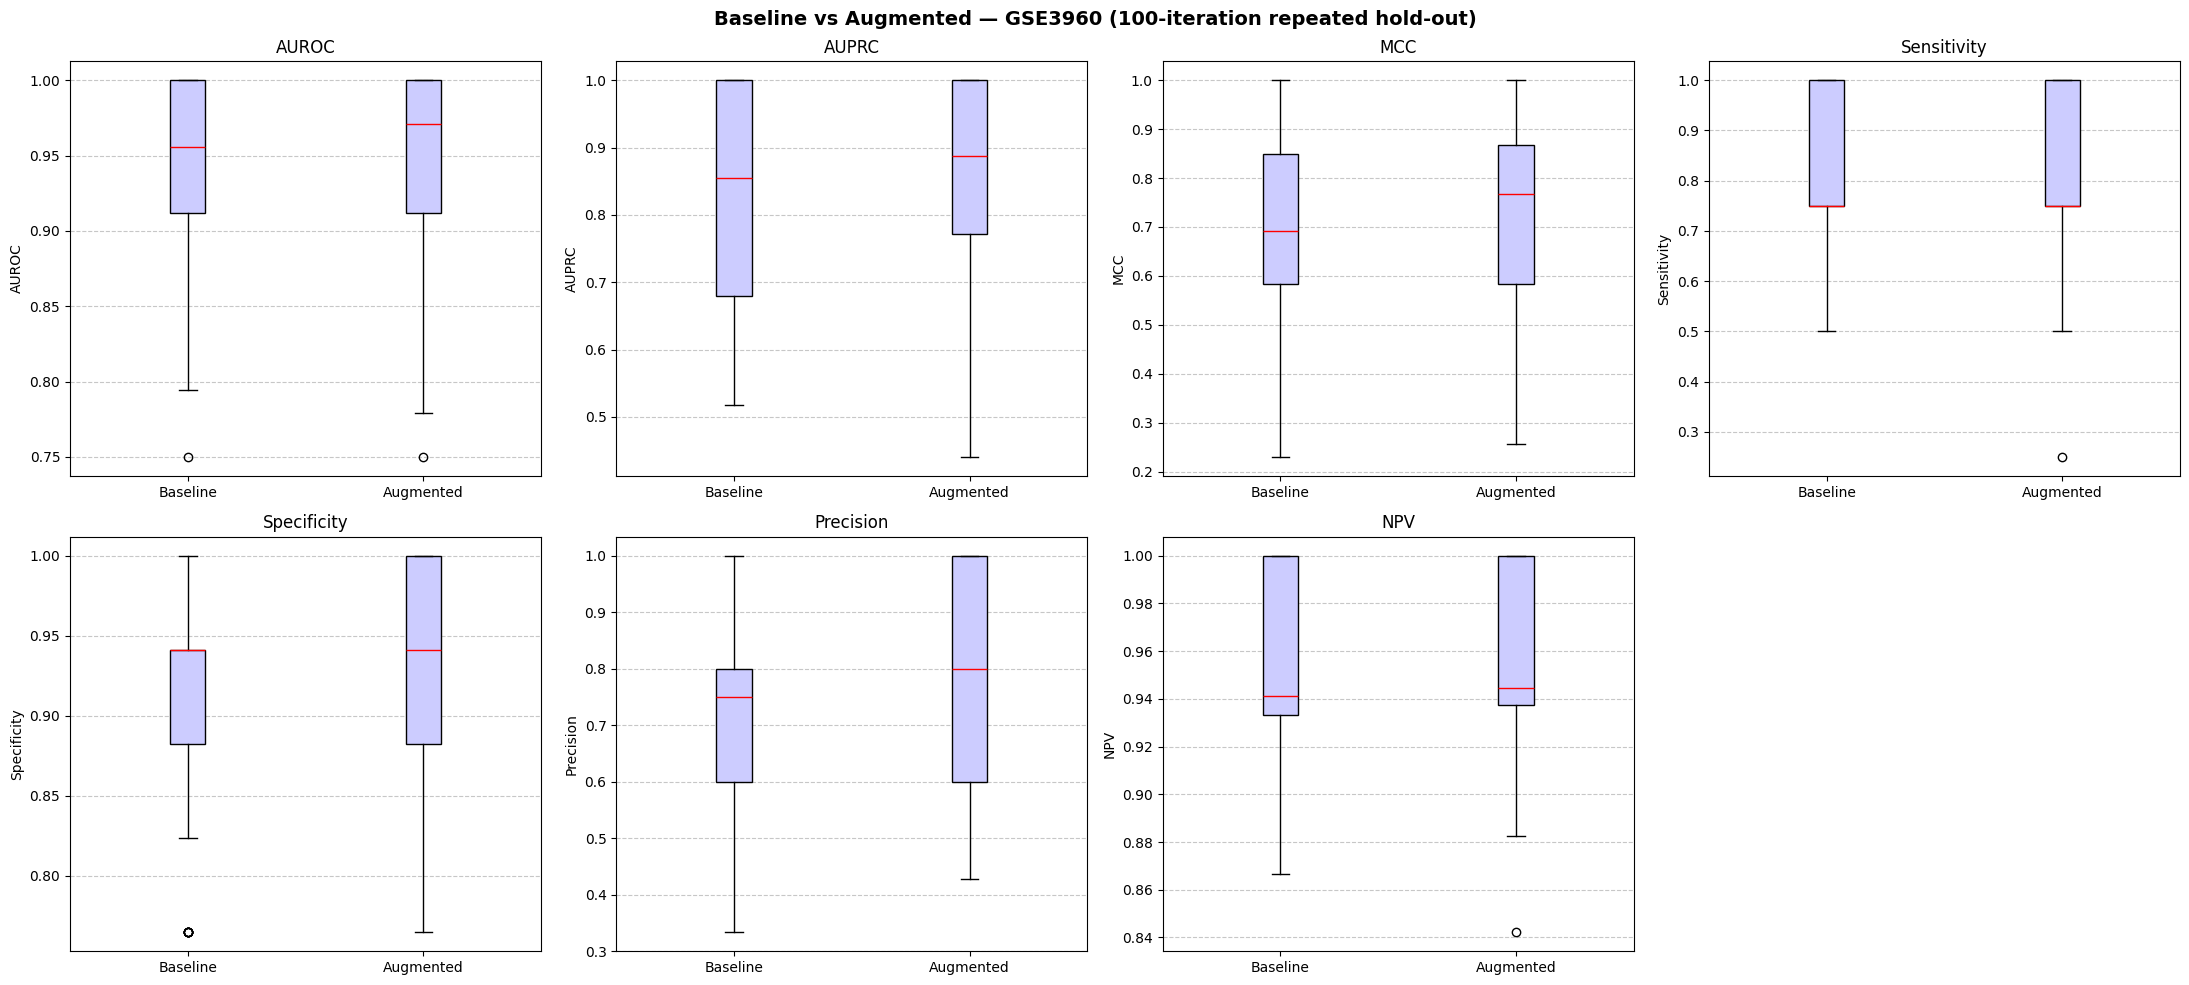

=== Numeric summary (all metrics) ===

Baseline (cv_df):
             count    mean     std     min     25%     50%     75%  max
auroc        100.0  0.9400  0.0615  0.7500  0.9118  0.9559  1.0000  1.0
auprc        100.0  0.8388  0.1463  0.5179  0.6802  0.8542  1.0000  1.0
mcc          100.0  0.6950  0.1708  0.2301  0.5830  0.6912  0.8481  1.0
sensitivity  100.0  0.8125  0.1643  0.5000  0.7500  0.7500  1.0000  1.0
specificity  100.0  0.9112  0.0692  0.7647  0.8824  0.9412  0.9412  1.0
precision    100.0  0.7206  0.1805  0.3333  0.6000  0.7500  0.8000  1.0
npv          100.0  0.9550  0.0383  0.8667  0.9333  0.9412  1.0000  1.0

Augmented (cv_aug):
             count    mean     std     min     25%     50%     75%  max
auroc        100.0  0.9407  0.0677  0.7500  0.9118  0.9706  1.0000  1.0
auprc        100.0  0.8557  0.1361  0.4405  0.7708  0.8875  1.0000  1.0
mcc          100.0  0.7440  0.1727  0.2557  0.5830  0.7670  0.8677  1.0
sensitivity  100.0  0.8125  0.1754  0.2500  0.7500  0.7500

In [73]:
# Step 1 — Quantitative comparison: baseline vs augmented (boxplots, all metrics)

import matplotlib.pyplot as plt

assert 'cv_df' in globals(), "Baseline CV results (cv_df) not found. Run Part 5b first."
assert 'cv_aug' in globals(), "Augmented CV results (cv_aug) not found. Run Part 8b first."

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for i, m in enumerate(ALL_METRICS):
    ax = axes_flat[i]
    data = [cv_df[m], cv_aug[m]]
    bp = ax.boxplot(data, labels=["Baseline", "Augmented"], patch_artist=True,
                    boxprops=dict(facecolor="#ccccff"), medianprops=dict(color="red"))
    ax.set_title(f"{METRIC_LABELS[m]}", fontsize=12)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)

# Hide the 8th subplot (2x4 grid, only 7 metrics)
axes_flat[7].set_visible(False)

plt.suptitle(f"Baseline vs Augmented — GSE3960 ({N_REPEATS}-iteration repeated hold-out)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print numeric summaries
print("=== Numeric summary (all metrics) ===")
print("\nBaseline (cv_df):")
print(cv_df[ALL_METRICS].describe().T.round(4))
print("\nAugmented (cv_aug):")
print(cv_aug[ALL_METRICS].describe().T.round(4))

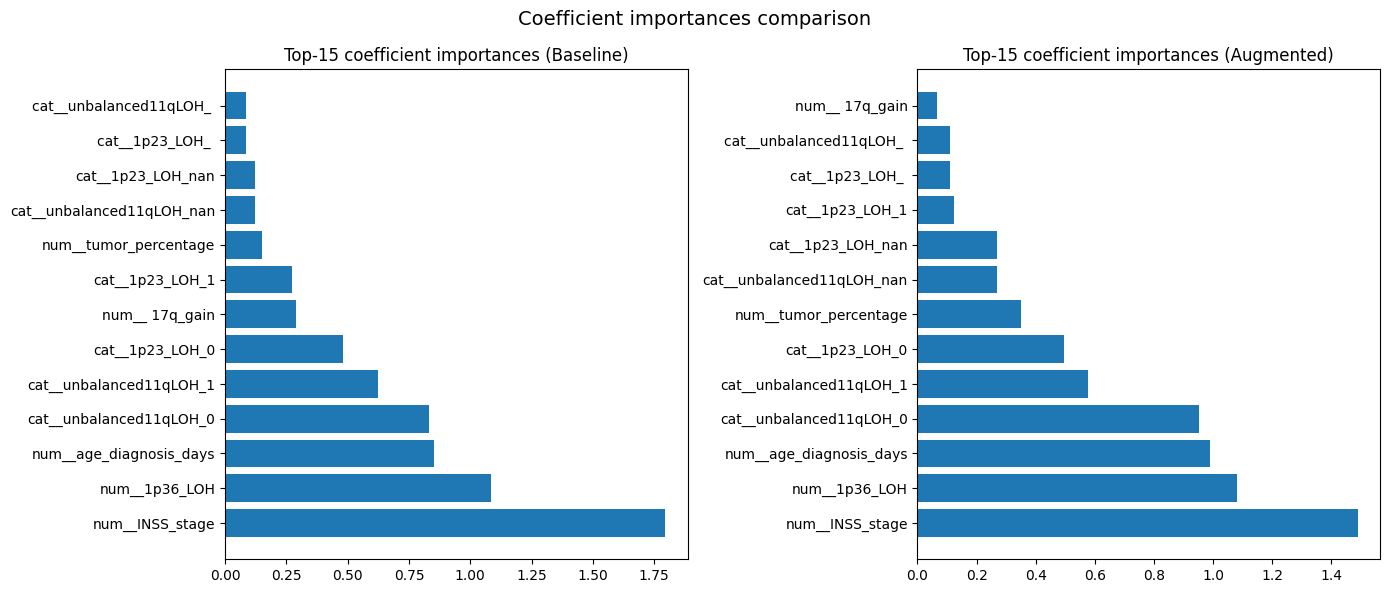

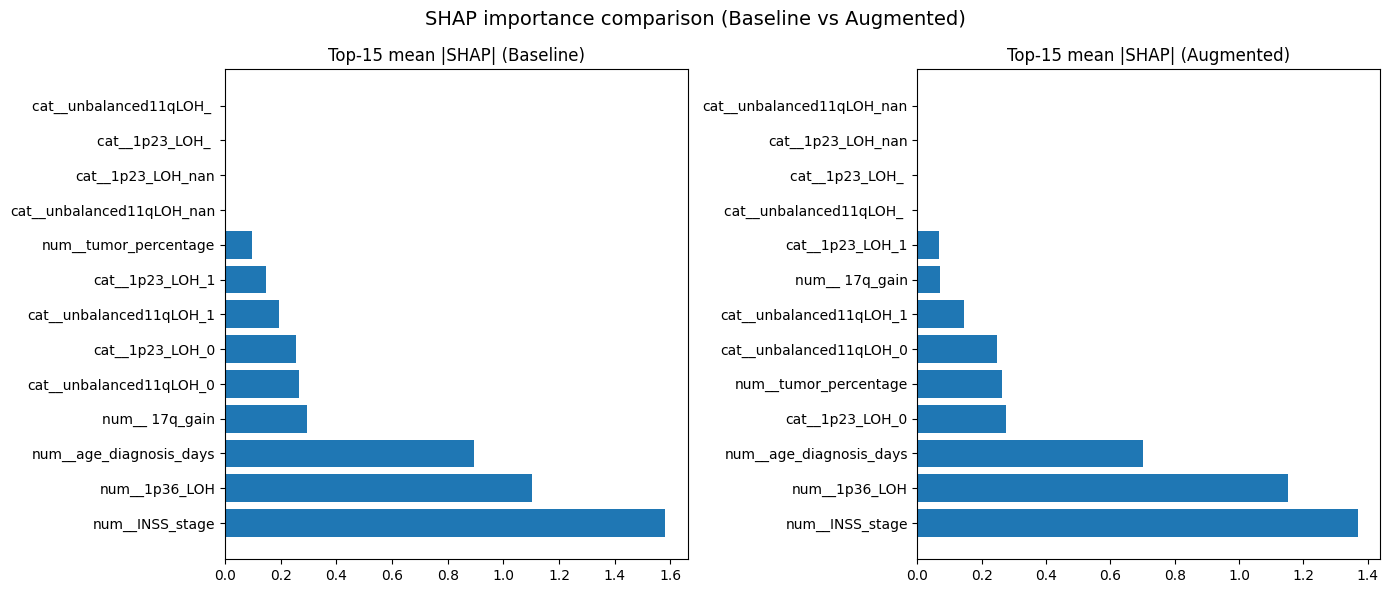

In [74]:
# Step 2 — Explainability: coefficients + SHAP (baseline vs augmented)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

# --- Safety checks ---
assert 'df' in globals() and 'TARGET_COLUMN' in globals(), "Dataset or TARGET_COLUMN not found."
assert 'X_train' in globals() and 'y_train' in globals(), "Run Part 3/4/5 first."

# --- Helper: rebuild a fresh preprocessor clone and fit it on provided X ---
def fit_preprocessor(pre_template, X_fit):
    pre_local = clone(pre_template)
    pre_local.fit(X_fit)
    return pre_local

# --- Helper: feature names after ColumnTransformer ---
def get_feature_names(pre_fitted, X_fit):
    try:
        return list(pre_fitted.get_feature_names_out())
    except Exception:
        return [f"feat_{i}" for i in range(pre_fitted.transform(X_fit).shape[1])]

# --- 1) BASELINE pipeline (fit only on original training split) ---
pre_baseline = fit_preprocessor(pre, X_train)
Xtr_b = pre_baseline.transform(X_train)
Xva_b = pre_baseline.transform(X_val)
Xte_b = pre_baseline.transform(X_test)

clf_baseline = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_baseline.fit(Xtr_b, y_train)

feat_names_b = get_feature_names(pre_baseline, X_train)
coef_b = np.abs(clf_baseline.coef_.ravel()) if clf_baseline.coef_.ndim == 2 else np.abs(clf_baseline.coef_)
imp_b = pd.Series(coef_b, index=feat_names_b).sort_values(ascending=False)

# --- 2) AUGMENTED pipeline (requires combo_raw/combo_y from Part 8) ---
assert 'combo_raw' in globals() and 'combo_y' in globals(), "Augmented data not found. Run Part 8 first."

pre_aug = fit_preprocessor(pre, combo_raw)
Xtr_a = pre_aug.transform(combo_raw)
Xva_a = pre_aug.transform(X_val)
Xte_a = pre_aug.transform(X_test)

clf_aug_expl = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_aug_expl.fit(Xtr_a, combo_y)

feat_names_a = get_feature_names(pre_aug, combo_raw)
coef_a = np.abs(clf_aug_expl.coef_.ravel()) if clf_aug_expl.coef_.ndim == 2 else np.abs(clf_aug_expl.coef_)
imp_a = pd.Series(coef_a, index=feat_names_a).sort_values(ascending=False)

# --- 3) Plot top-15 coefficient importances side-by-side ---
TOPK = 15
top_b = imp_b.head(TOPK)
top_a = imp_a.head(TOPK)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(range(len(top_b.index[::-1])), top_b.values[::-1])
axes[0].set_yticks(range(len(top_b.index[::-1])))
axes[0].set_yticklabels(top_b.index[::-1])
axes[0].set_title("Top-15 coefficient importances (Baseline)")
axes[0].invert_yaxis()

axes[1].barh(range(len(top_a.index[::-1])), top_a.values[::-1])
axes[1].set_yticks(range(len(top_a.index[::-1])))
axes[1].set_yticklabels(top_a.index[::-1])
axes[1].set_title("Top-15 coefficient importances (Augmented)")
axes[1].invert_yaxis()

plt.suptitle("Coefficient importances comparison", fontsize=14)
plt.tight_layout()
plt.show()

# --- 4) SHAP explanations on the transformed feature space ---
def _ensure_shap():
    try:
        import shap  # noqa
        return True
    except Exception:
        try:
            import sys, subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
            import shap  # noqa
            return True
        except Exception as e:
            print("[SHAP] Install failed:", e)
            return False

shap_imp_b = shap_imp_a = None

if _ensure_shap():
    import shap

    # Background samples (keep small for speed/stability)
    background_b = shap.sample(pd.DataFrame(Xtr_b), min(50, Xtr_b.shape[0]))
    background_a = shap.sample(pd.DataFrame(Xtr_a), min(50, Xtr_a.shape[0]))

    def compute_shap_linear(clf, X_background, X_eval, feature_names, label="[BASELINE]"):
        """Compute mean |SHAP| values with preferred settings."""
        expl = shap.LinearExplainer(clf, X_background, feature_perturbation="interventional")
        sv = expl(pd.DataFrame(X_eval))
        vals = sv.values if hasattr(sv, "values") else sv
        return pd.Series(np.abs(vals).mean(axis=0), index=feature_names).sort_values(ascending=False)

    try:
        shap_imp_b = compute_shap_linear(clf_baseline, background_b, Xva_b, feat_names_b, label="[BASELINE]")
    except Exception as e:
        print("[BASELINE] SHAP computation failed:", e)

    try:
        shap_imp_a = compute_shap_linear(clf_aug_expl, background_a, Xva_a, feat_names_a, label="[AUGMENTED]")
    except Exception as e:
        print("[AUGMENTED] SHAP computation failed:", e)

    # --- Plot SHAP importances side-by-side (horizontal comparison) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    if shap_imp_b is not None:
        top_b = shap_imp_b.head(TOPK)
        axes[0].barh(range(len(top_b.index[::-1])), top_b.values[::-1])
        axes[0].set_yticks(range(len(top_b.index[::-1])))
        axes[0].set_yticklabels(top_b.index[::-1])
        axes[0].set_title("Top-15 mean |SHAP| (Baseline)")
        axes[0].invert_yaxis()
    else:
        axes[0].text(0.5, 0.5, "Baseline SHAP unavailable", ha="center", va="center")
        axes[0].axis("off")

    if shap_imp_a is not None:
        top_a = shap_imp_a.head(TOPK)
        axes[1].barh(range(len(top_a.index[::-1])), top_a.values[::-1])
        axes[1].set_yticks(range(len(top_a.index[::-1])))
        axes[1].set_yticklabels(top_a.index[::-1])
        axes[1].set_title("Top-15 mean |SHAP| (Augmented)")
        axes[1].invert_yaxis()
    else:
        axes[1].text(0.5, 0.5, "Augmented SHAP unavailable", ha="center", va="center")
        axes[1].axis("off")

    plt.suptitle("SHAP importance comparison (Baseline vs Augmented)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not installed; coefficient importances plotted instead.")


## Part 9 — Probability calibration

In [75]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

cal = CalibratedClassifierCV(clf_aug, method='isotonic', cv='prefit')
cal.fit(Xva, y_val)

proba_cal = cal.predict_proba(Xte)[:,1]
cal_metrics = compute_all_metrics(y_test, proba_cal)
brier = brier_score_loss(y_test, proba_cal)

print(f"[CALIBRATED][TEST] AUROC={cal_metrics['auroc']:.4f} | AUPRC={cal_metrics['auprc']:.4f} | "
      f"MCC={cal_metrics['mcc']:.4f} | Sens={cal_metrics['sensitivity']:.4f} | "
      f"Spec={cal_metrics['specificity']:.4f} | Prec={cal_metrics['precision']:.4f} | "
      f"NPV={cal_metrics['npv']:.4f} | Brier={brier:.4f}")

[CALIBRATED][TEST] AUROC=0.7949 | AUPRC=0.6181 | MCC=0.5897 | Sens=0.6667 | Spec=0.9231 | Prec=0.6667 | NPV=0.9231 | Brier=0.1152


[Augmented] Brier (raw) = 0.0829 | ECE (raw) = 0.1317
[Augmented] Brier (calibrated: sigmoid) = 0.0924 | ECE (calibrated) = 0.1176


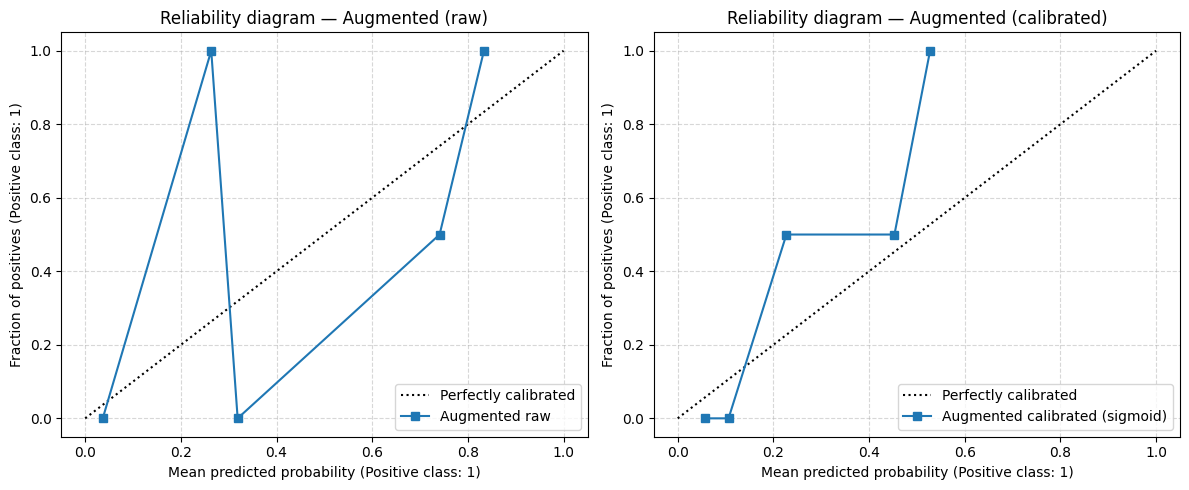

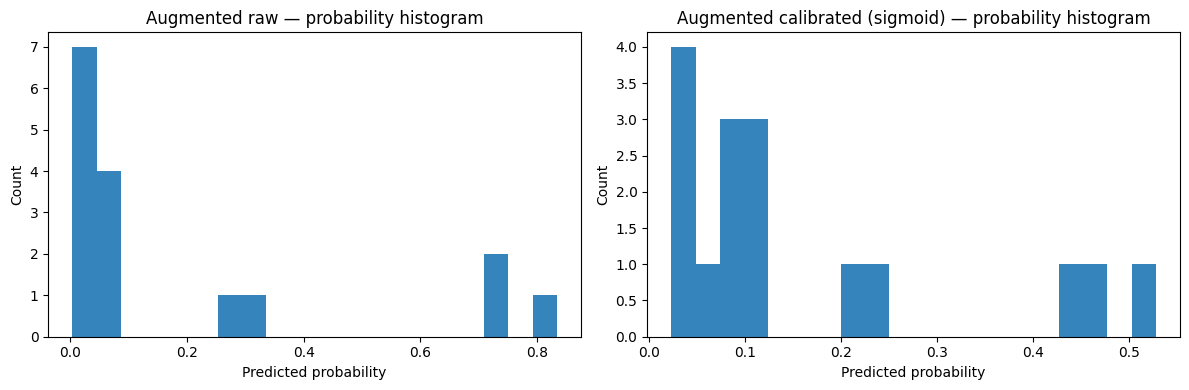

In [76]:
# Step 9b — Calibration plots (raw vs calibrated, Platt/sigmoid)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# --- 1) Choose which model to compare (prefer augmented if available) ---
if 'clf_aug' in globals():
    RAW_MODEL = clf_aug
    MODEL_NAME = "Augmented"
    Xt_val = pre.transform(X_val)   # 'pre' fitted on combo_raw in Part 8
    Xt_test = pre.transform(X_test)
elif 'clf_baseline' in globals() and 'pre_baseline' in globals():
    RAW_MODEL = clf_baseline
    MODEL_NAME = "Baseline"
    Xt_val = pre_baseline.transform(X_val)
    Xt_test = pre_baseline.transform(X_test)
else:
    raise RuntimeError("No suitable model found. Run Part 5 (baseline) or Part 8 (augmented).")

# --- 2) Raw probabilities on TEST ---
proba_raw_test = (RAW_MODEL.predict_proba(Xt_test)[:, 1]
                  if hasattr(RAW_MODEL, "predict_proba")
                  else RAW_MODEL.decision_function(Xt_test))

# --- 3) Build a Platt (sigmoid) calibrator on VALIDATION ---
CALIB_METHOD = "sigmoid"  # Platt scaling (more stable on small datasets)
cal_sig = CalibratedClassifierCV(RAW_MODEL, method=CALIB_METHOD, cv="prefit")
cal_sig.fit(Xt_val, y_val)

proba_cal_test = (cal_sig.predict_proba(Xt_test)[:, 1]
                  if hasattr(cal_sig, "predict_proba")
                  else cal_sig.decision_function(Xt_test))

# --- 4) Metrics: Brier + Expected Calibration Error (ECE) ---
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    inds = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = inds == b
        if np.any(mask):
            conf = y_prob[mask].mean()
            acc = y_true[mask].mean()
            ece += (mask.mean()) * abs(acc - conf)
    return ece

brier_raw = brier_score_loss(y_test, proba_raw_test)
brier_cal = brier_score_loss(y_test, proba_cal_test)
ece_raw = expected_calibration_error(np.asarray(y_test), proba_raw_test, n_bins=10)
ece_cal = expected_calibration_error(np.asarray(y_test), proba_cal_test, n_bins=10)

print(f"[{MODEL_NAME}] Brier (raw) = {brier_raw:.4f} | ECE (raw) = {ece_raw:.4f}")
print(f"[{MODEL_NAME}] Brier (calibrated: {CALIB_METHOD}) = {brier_cal:.4f} | ECE (calibrated) = {ece_cal:.4f}")

# --- 5) Reliability diagrams (TEST) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
CalibrationDisplay.from_predictions(
    y_test, proba_raw_test, n_bins=10, strategy="uniform", name=f"{MODEL_NAME} raw", ax=ax[0]
)
ax[0].set_title(f"Reliability diagram — {MODEL_NAME} (raw)")
ax[0].grid(True, linestyle="--", alpha=0.5)

CalibrationDisplay.from_predictions(
    y_test, proba_cal_test, n_bins=10, strategy="uniform",
    name=f"{MODEL_NAME} calibrated ({CALIB_METHOD})", ax=ax[1]
)
ax[1].set_title(f"Reliability diagram — {MODEL_NAME} (calibrated)")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# --- 6) Probability histograms (TEST) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(proba_raw_test, bins=20, alpha=0.9)
ax[0].set_title(f"{MODEL_NAME} raw — probability histogram")
ax[0].set_xlabel("Predicted probability"); ax[0].set_ylabel("Count")

ax[1].hist(proba_cal_test, bins=20, alpha=0.9)
ax[1].set_title(f"{MODEL_NAME} calibrated ({CALIB_METHOD}) — probability histogram")
ax[1].set_xlabel("Predicted probability"); ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Part 10 — Privacy checks (heuristic)

In [77]:
# Part 10 — Privacy checks (nearest-neighbour distance & duplication scan)


import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# --- 0) Pick the synthetic table to audit ---
if 'synthetic_cond' in globals():
    SYN_NAME = "conditional"
    synth_df = synthetic_cond.copy()
elif 'synthetic_uncond' in globals():
    SYN_NAME = "unconditional"
    synth_df = synthetic_uncond.copy()
else:
    raise RuntimeError("No synthetic data found. Run Part 6A/6B first.")

print(f"[Privacy] Auditing synthetic data: {SYN_NAME} | rows={len(synth_df)}")

# --- 1) Align columns to the training feature space ---
assert 'X_train' in globals() and 'pre' in globals(), "Run Parts 3–8 first."
synth_df = synth_df.reindex(columns=X_train.columns, fill_value=np.nan)

# --- 2) Transform both real train and synthetic with the same preprocessor ---
Xtr = pre.transform(X_train)
Xs  = pre.transform(synth_df)

# Convert to dense if sparse
def _todense(M):
    return M.toarray() if hasattr(M, "toarray") else M

Xtr_dense = _todense(Xtr)
Xs_dense  = _todense(Xs)

# --- 3) Nearest neighbour distances (synthetic→real) ---
nn = NearestNeighbors(n_neighbors=1).fit(Xtr_dense)
dists, _ = nn.kneighbors(Xs_dense)
dists = dists.ravel()

print(f"[Privacy] Synthetic→Real NN distance: min={dists.min():.4f} | 5th%={np.percentile(dists,5):.4f} | median={np.median(dists):.4f}")

# --- 4) Simple duplication scan in raw (pre-transform) space for numeric columns ---
num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
dup_count = 0
if num_cols:
    real_num = X_train[num_cols].round(6)
    synth_num = synth_df[num_cols].round(6)
    # Cartesian match on all numeric columns (strict)
    merged = synth_num.merge(real_num.drop_duplicates(), how="inner", on=num_cols)
    dup_count = len(merged)
print(f"[Privacy] Strict numeric duplicates found: {dup_count}")

# --- 5) Lightweight membership-inference sanity (threshold on NN distances) ---
# If too many synthetic samples are *very* close to real ones, flag a warning.
ABS_THR = 0.10  # tuned to your feature scaling; adjust if needed
share_too_close = float((dists < ABS_THR).mean())
print(f"[Privacy] Share of synthetic samples with NN distance < {ABS_THR:.2f}: {share_too_close:.3f}")

if share_too_close > 0.10 or dup_count > 0:
    print("⚠️ Privacy warning: consider re-running sanitisation with a higher threshold and/or reducing SYN_ROWS.")
else:
    print("✅ Privacy check passed at this granularity (no evident memorisation).")


[Privacy] Auditing synthetic data: conditional | rows=42
[Privacy] Synthetic→Real NN distance: min=0.2908 | 5th%=0.7915 | median=1.5181
[Privacy] Strict numeric duplicates found: 0
[Privacy] Share of synthetic samples with NN distance < 0.10: 0.000
✅ Privacy check passed at this granularity (no evident memorisation).


In [78]:
!pip install diffprivlib

In [79]:
# Part 10b — DP-lite safeguards for synthetic release + tuned DP Logistic Regression

import numpy as np
import pandas as pd

# --- Safety checks on required artefacts ---
assert 'synthetic_cond' in globals(), "Run Part 6B first to create conditional synthetic data."
assert 'X_train' in globals(), "Run Parts 3–5 to define X_train."
assert 'pre' in globals(), "The fitted preprocessor 'pre' is required (from your main pipeline)."
assert all(v in globals() for v in ['combo_raw', 'combo_y', 'X_test', 'y_test']), \
    "Run Part 8 to define combo_raw/combo_y and keep your test split."

# ------------------------------
# 1) DP-lite: category suppression + Laplace noise (only on columns known in X_train)
# ------------------------------
dp_ready = synthetic_cond.copy()

# Light k-anonymity for categoricals: suppress categories with frequency < K
K_MIN = 3
for c in dp_ready.columns:
    if (c in X_train.columns) and (not pd.api.types.is_numeric_dtype(dp_ready[c])):
        vc = dp_ready[c].value_counts(dropna=False)
        rare = vc[vc < K_MIN].index
        if len(rare) > 0:
            dp_ready.loc[dp_ready[c].isin(rare), c] = "OTHER"

# Laplace noise on numeric columns (ε controls strength) and clip to real range
EPSILON = 8.0  # higher ε → less noise; typical range 4–16 for small datasets
for c in dp_ready.columns:
    if (c in X_train.columns) and pd.api.types.is_numeric_dtype(dp_ready[c]):
        mn, mx = X_train[c].min(), X_train[c].max()
        rng = mx - mn
        sens = max(rng, 1e-6)     # avoid zero sensitivity
        scale = sens / EPSILON
        dp_ready[c] = (dp_ready[c] + np.random.laplace(loc=0.0, scale=scale, size=len(dp_ready))).clip(mn, mx)

print(f"[DP-lite] Applied category suppression (k>={K_MIN}) and Laplace noise (epsilon={EPSILON}).")

# Make DP-ready synthetic table available for exports (Part 11)
synthetic_dp = dp_ready

# ------------------------------
# 2) Optional experiment: DP Logistic Regression (diffprivlib) — tuned attempt
# ------------------------------
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import normalize

def _install_diffprivlib_if_needed():
    try:
        import diffprivlib  # noqa: F401
        return True
    except Exception:
        import sys, subprocess
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "diffprivlib"])
            import diffprivlib  # noqa: F401
            return True
        except Exception as e:
            print("[DP-lite] diffprivlib not available or failed to install:", e)
            return False

if _install_diffprivlib_if_needed():
    try:
        from diffprivlib.models import LogisticRegression as DPLogReg  # type: ignore

        # 2.1 Transform with the same 'pre' used elsewhere; fit on augmented train to avoid leakage
        Xt = pre.fit_transform(combo_raw)
        Xte = pre.transform(X_test)

        # Convert to dense if sparse
        Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt
        Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte

        # 2.2 Dimensionality reduction: keep the K most informative features
        K = min(10, Xt.shape[1])  # conservative for small-N settings
        selector = SelectKBest(mutual_info_classif, k=K)
        Xt_sel = selector.fit_transform(Xt, combo_y)
        Xte_sel = selector.transform(Xte)

        # 2.3 Per-sample L2 normalisation → guarantees ||x||_2 <= 1 → set data_norm=1.0
        Xt_norm  = normalize(Xt_sel, norm="l2")
        Xte_norm = normalize(Xte_sel, norm="l2")
        data_norm_bound = 1.0

        # 2.4 Small epsilon grid to show privacy–utility trade-off
        eps_list = [2.0, 4.0, 8.0, 16.0]
        best = None
        for eps in eps_list:
            dp_clf = DPLogReg(max_iter=2000, epsilon=eps, data_norm=data_norm_bound)
            dp_clf.fit(Xt_norm, combo_y)
            proba = dp_clf.predict_proba(Xte_norm)[:, 1]
            row = compute_all_metrics(y_test, proba)
            print(f"[DP-LR] eps={eps:.1f} ⇒ AUROC={row['auroc']:.3f} | AUPRC={row['auprc']:.3f} | MCC={row['mcc']:.3f}")
            cand = (eps, row['auroc'], row['auprc'], row['mcc'])
            best = cand if best is None else (cand if (cand[1] > best[1] or (cand[1] == best[1] and cand[3] > best[3])) else best)

        print(f"[DP-LR] Best over grid: eps={best[0]:.1f} (AUROC={best[1]:.3f} | AUPRC={best[2]:.3f} | MCC={best[3]:.3f})")

    except Exception as e:
        print("[DP-lite] DP Logistic Regression failed:", e)
else:
    print("[DP-lite] Skipping DP Logistic Regression (diffprivlib unavailable).")

[DP-lite] Applied category suppression (k>=3) and Laplace noise (epsilon=8.0).
[DP-LR] eps=2.0 ⇒ AUROC=0.487 | AUPRC=0.227 | MCC=-0.231
[DP-LR] eps=4.0 ⇒ AUROC=1.000 | AUPRC=1.000 | MCC=1.000
[DP-LR] eps=8.0 ⇒ AUROC=0.974 | AUPRC=0.917 | MCC=0.590
[DP-LR] eps=16.0 ⇒ AUROC=0.872 | AUPRC=0.556 | MCC=0.590
[DP-LR] Best over grid: eps=4.0 (AUROC=1.000 | AUPRC=1.000 | MCC=1.000)


[10c] Original features: 13 → SelectKBest(k=13) + L2 norm
[10c] data_norm = 1.0 | feature/sample ratio: 0.19
[10c] Saved per-run metrics to dp_lr_epsilon_utility_runs.csv
[10c] Saved summary to dp_lr_epsilon_utility_summary.csv


,epsilon,data_norm,n_runs,AUROC (mean±sd),AUPRC (mean±sd),MCC (mean±sd),Sensitivity (mean±sd),Specificity (mean±sd),Precision (mean±sd),NPV (mean±sd),ECE pre (mean±sd),ECE post (mean±sd),brier_pre_mean,brier_post_mean,calibration
4,inf,1.0,5,0.9487 ± 0.0000,0.8667 ± 0.0000,0.7868 ± 0.0000,0.6667 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9286 ± 0.0000,0.1866 ± 0.0000,0.0837 ± 0.0245,0.074821,0.068956,isotonic
3,16.0,1.0,5,0.9538 ± 0.0215,0.8800 ± 0.0361,0.7474 ± 0.0881,0.6667 ± 0.0000,0.9846 ± 0.0344,0.9333 ± 0.1491,0.9275 ± 0.0025,0.1714 ± 0.0428,0.0674 ± 0.0252,0.077158,0.062714,isotonic
2,8.0,1.0,5,0.8974 ± 0.0850,0.8382 ± 0.0774,0.5900 ± 0.3407,0.5333 ± 0.2981,0.9846 ± 0.0344,0.7333 ± 0.4346,0.9043 ± 0.0513,0.1817 ± 0.0380,0.0514 ± 0.0653,0.087324,0.100959,isotonic
1,4.0,1.0,5,0.8821 ± 0.1782,0.7692 ± 0.2441,0.5692 ± 0.2293,0.6667 ± 0.2357,0.9077 ± 0.0644,0.6500 ± 0.2236,0.9238 ± 0.0509,0.1756 ± 0.0604,0.1460 ± 0.1264,0.101612,0.130428,isotonic
0,2.0,1.0,5,0.6359 ± 0.1194,0.3667 ± 0.1400,0.0056 ± 0.2434,0.3333 ± 0.3333,0.6923 ± 0.0769,0.1643 ± 0.1507,0.8261 ± 0.0651,0.3388 ± 0.0498,0.0711 ± 0.0695,0.274851,0.201457,isotonic


[10c] Saved Figure_U1_privacy_utility.png

Table U1 — Operating points (epsilon, data_norm, metrics)


,epsilon,data_norm,n_runs,AUROC (mean±sd),AUPRC (mean±sd),MCC (mean±sd),Sensitivity (mean±sd),Specificity (mean±sd),Precision (mean±sd),NPV (mean±sd),ECE pre (mean±sd),ECE post (mean±sd),brier_pre_mean,brier_post_mean,calibration
4,inf,1.0,5,0.9487 ± 0.0000,0.8667 ± 0.0000,0.7868 ± 0.0000,0.6667 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9286 ± 0.0000,0.1866 ± 0.0000,0.0837 ± 0.0245,0.074821,0.068956,isotonic
3,16.0,1.0,5,0.9538 ± 0.0215,0.8800 ± 0.0361,0.7474 ± 0.0881,0.6667 ± 0.0000,0.9846 ± 0.0344,0.9333 ± 0.1491,0.9275 ± 0.0025,0.1714 ± 0.0428,0.0674 ± 0.0252,0.077158,0.062714,isotonic
2,8.0,1.0,5,0.8974 ± 0.0850,0.8382 ± 0.0774,0.5900 ± 0.3407,0.5333 ± 0.2981,0.9846 ± 0.0344,0.7333 ± 0.4346,0.9043 ± 0.0513,0.1817 ± 0.0380,0.0514 ± 0.0653,0.087324,0.100959,isotonic
1,4.0,1.0,5,0.8821 ± 0.1782,0.7692 ± 0.2441,0.5692 ± 0.2293,0.6667 ± 0.2357,0.9077 ± 0.0644,0.6500 ± 0.2236,0.9238 ± 0.0509,0.1756 ± 0.0604,0.1460 ± 0.1264,0.101612,0.130428,isotonic
0,2.0,1.0,5,0.6359 ± 0.1194,0.3667 ± 0.1400,0.0056 ± 0.2434,0.3333 ± 0.3333,0.6923 ± 0.0769,0.1643 ± 0.1507,0.8261 ± 0.0651,0.3388 ± 0.0498,0.0711 ± 0.0695,0.274851,0.201457,isotonic


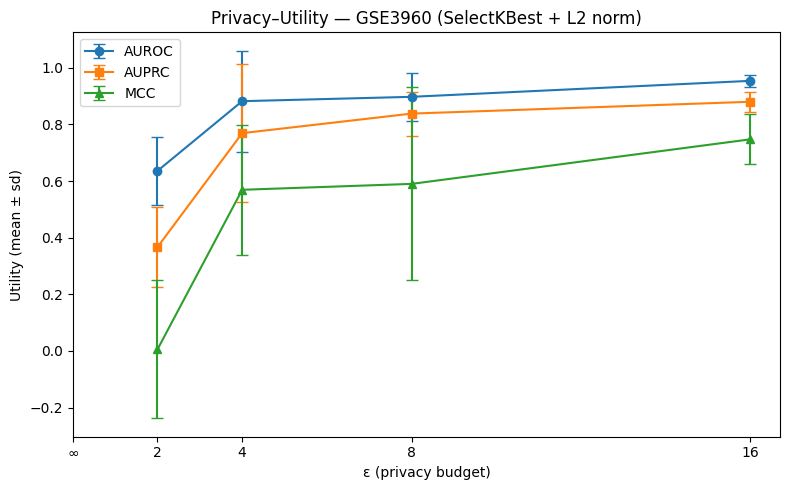

In [80]:
# === Part 10c — Privacy–Utility (DP Logistic Regression, stable sweep) ===
# - Includes non-DP baseline (ε = ∞)
# - Sweeps ε = {∞, 16, 8, 4, 2}
# - Repeats each ε for 5 random seeds → mean ± sd
# - Metrics: AUROC, AUPRC, MCC, Sensitivity, Specificity, Precision, NPV,
#            ECE (pre/post), Brier (pre/post)
# - UNIFORM preprocessing: SelectKBest(k=min(15,p)) + L2 normalisation
#   (same across all 3 datasets for cross-dataset comparability)

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, matthews_corrcoef, confusion_matrix)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.isotonic import IsotonicRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

try:
    from diffprivlib.models import LogisticRegression as DpLogReg
except Exception as e:
    raise RuntimeError(
        "diffprivlib is not installed. Please install before running: "
        "`pip install diffprivlib`"
    )

# -------------------- Utilities --------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()
    if np.unique(y_true).size < 2:
        return np.nan
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_prob, qs)
    edges = np.unique(edges)
    if edges.size < 2:
        return 0.0
    idx = np.digitize(y_prob, edges[1:-1], right=False)
    accs, confs, weights = [], [], []
    for b in range(edges.size - 1):
        mask = (idx == b)
        if not np.any(mask):
            continue
        accs.append(y_true[mask].mean())
        confs.append(y_prob[mask].mean())
        weights.append(mask.mean())
    accs, confs, weights = np.array(accs), np.array(confs), np.array(weights)
    return float(np.sum(weights * np.abs(accs - confs)))

def isotonic_fit(y_true, y_prob):
    ir = IsotonicRegression(out_of_bounds="clip")
    ir.fit(y_prob, y_true)
    return lambda p: ir.predict(p)

# -------------------- Required objects --------------------
for varname in ["X_train", "y_train", "X_test", "y_test", "pre"]:
    if varname not in globals():
        raise NameError(f"{varname} not found. Please run the previous cells first.")

# -------------------- Preprocessing: SelectKBest + L2 norm --------------------
# Same preprocessing as all datasets for uniform cross-dataset DP comparison
Xtr_raw = pre.transform(X_train)
Xte_raw = pre.transform(X_test)

# Convert to dense if sparse
if hasattr(Xtr_raw, 'toarray'):
    Xtr_raw = Xtr_raw.toarray()
if hasattr(Xte_raw, 'toarray'):
    Xte_raw = Xte_raw.toarray()
Xtr_raw = np.asarray(Xtr_raw)
Xte_raw = np.asarray(Xte_raw)
y_train_np = np.asarray(y_train).ravel()
y_test_np  = np.asarray(y_test).ravel()

K_SEL = min(15, Xtr_raw.shape[1])
selector = SelectKBest(mutual_info_classif, k=K_SEL)
Xtr_sel = selector.fit_transform(Xtr_raw, y_train_np)
Xte_sel = selector.transform(Xte_raw)

# L2 normalisation → guarantees ||x||_2 <= 1.0
Xtr_t = normalize(Xtr_sel, norm="l2")
Xte_t = normalize(Xte_sel, norm="l2")
data_norm = 1.0

print(f"[10c] Original features: {Xtr_raw.shape[1]} → SelectKBest(k={K_SEL}) + L2 norm")
print(f"[10c] data_norm = {data_norm:.1f} | feature/sample ratio: {K_SEL/Xtr_t.shape[0]:.2f}")

# -------------------- Sweep settings --------------------
eps_grid = [np.inf, 16.0, 8.0, 4.0, 2.0]
n_seeds  = 5
calibration_method = "isotonic"
rows = []
rng_seeds = list(range(123, 123 + n_seeds))

for eps in eps_grid:
    for seed in rng_seeds:
        np.random.seed(seed)
        if np.isinf(eps):
            clf = SkLogReg(max_iter=2000, solver="lbfgs")
        else:
            clf = DpLogReg(
                epsilon=float(eps),
                data_norm=float(data_norm),
                C=1.0,
                fit_intercept=True,
                max_iter=2000,
                n_jobs=None,
                class_weight=None
            )

        clf.fit(Xtr_t, y_train_np)

        # Test probabilities
        proba_test = clf.predict_proba(Xte_t)[:, 1]
        auroc = roc_auc_score(y_test_np, proba_test)
        auprc = average_precision_score(y_test_np, proba_test)
        ece_pre = expected_calibration_error(y_test_np, proba_test, n_bins=10)
        brier_pre = brier_score_loss(y_test_np, proba_test)

        # Threshold-dependent metrics
        y_pred_test = (proba_test >= CLASSIFICATION_THRESHOLD).astype(int)
        cm = confusion_matrix(y_test_np, y_pred_test, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        mcc_val = matthews_corrcoef(y_test_np, y_pred_test)
        sens_val = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec_val = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        prec_val = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv_val  = tn / (tn + fn) if (tn + fn) > 0 else 0.0

        # Leakage-safe post-hoc calibration
        sss_cal = StratifiedShuffleSplit(n_splits=1, test_size=0.2,
                                          random_state=seed)
        train_idx, val_idx = next(sss_cal.split(Xtr_t, y_train_np))
        X_cal_tr, y_cal_tr = Xtr_t[train_idx], y_train_np[train_idx]
        X_cal_va, y_cal_va = Xtr_t[val_idx],  y_train_np[val_idx]

        if np.isinf(eps):
            calib_clf = SkLogReg(max_iter=2000, solver="lbfgs")
        else:
            calib_clf = DpLogReg(
                epsilon=float(eps),
                data_norm=float(data_norm),
                C=1.0,
                fit_intercept=True,
                max_iter=2000,
                n_jobs=None
            )
        calib_clf.fit(X_cal_tr, y_cal_tr)
        proba_va = calib_clf.predict_proba(X_cal_va)[:, 1]

        if calibration_method == "isotonic":
            calibrator = isotonic_fit(y_cal_va, proba_va)
        else:
            from sklearn.linear_model import LogisticRegression
            platt_lr = LogisticRegression(max_iter=1000)
            platt_lr.fit(proba_va.reshape(-1,1), y_cal_va)
            calibrator = lambda p: platt_lr.predict_proba(p.reshape(-1,1))[:,1]

        proba_test_cal = calibrator(proba_test)
        ece_post = expected_calibration_error(y_test_np, proba_test_cal, n_bins=10)
        brier_post = brier_score_loss(y_test_np, proba_test_cal)

        rows.append({
            "epsilon": eps, "seed": seed,
            "auroc": auroc, "auprc": auprc, "mcc": mcc_val,
            "sensitivity": sens_val, "specificity": spec_val,
            "precision": prec_val, "npv": npv_val,
            "ece_pre": ece_pre, "ece_post": ece_post,
            "brier_pre": brier_pre, "brier_post": brier_post,
            "data_norm": data_norm, "calibration": calibration_method
        })

df_runs = pd.DataFrame(rows).sort_values(["epsilon", "seed"])
df_runs.to_csv("dp_lr_epsilon_utility_runs.csv", index=False)
print("[10c] Saved per-run metrics to dp_lr_epsilon_utility_runs.csv")

# -------------------- Aggregate mean ± sd per ε --------------------
def mean_sd(series):
    arr = np.asarray(series, dtype=float)
    return f"{np.nanmean(arr):.4f} ± {np.nanstd(arr, ddof=1):.4f}"

agg_dict = {
    "auroc_mean": ("auroc", "mean"), "auroc_sd": ("auroc", "std"),
    "auprc_mean": ("auprc", "mean"), "auprc_sd": ("auprc", "std"),
    "mcc_mean": ("mcc", "mean"), "mcc_sd": ("mcc", "std"),
    "sensitivity_mean": ("sensitivity", "mean"), "sensitivity_sd": ("sensitivity", "std"),
    "specificity_mean": ("specificity", "mean"), "specificity_sd": ("specificity", "std"),
    "precision_mean": ("precision", "mean"), "precision_sd": ("precision", "std"),
    "npv_mean": ("npv", "mean"), "npv_sd": ("npv", "std"),
    "ece_pre_mean": ("ece_pre", "mean"), "ece_pre_sd": ("ece_pre", "std"),
    "ece_post_mean": ("ece_post", "mean"), "ece_post_sd": ("ece_post", "std"),
    "brier_pre_mean": ("brier_pre", "mean"), "brier_post_mean": ("brier_post", "mean"),
    "data_norm": ("data_norm", "first"), "calibration": ("calibration", "first"),
    "n_runs": ("seed", "count"),
}
summary = (
    df_runs
    .groupby("epsilon", as_index=False)
    .agg(**agg_dict)
)
def eps_key(e):
    return 1e9 if np.isinf(e) else float(e)
summary = summary.sort_values(by="epsilon", key=lambda s: s.map(eps_key), ascending=False)

for m in ALL_METRICS:
    summary[f"{METRIC_LABELS[m]} (mean±sd)"] = [
        mean_sd(df_runs[df_runs["epsilon"]==e][m]) for e in summary["epsilon"]
    ]
summary["ECE pre (mean±sd)"]  = [mean_sd(df_runs[df_runs["epsilon"]==e]["ece_pre"]) for e in summary["epsilon"]]
summary["ECE post (mean±sd)"] = [mean_sd(df_runs[df_runs["epsilon"]==e]["ece_post"]) for e in summary["epsilon"]]

cols_show = (
    ["epsilon", "data_norm", "n_runs"]
    + [f"{METRIC_LABELS[m]} (mean±sd)" for m in ALL_METRICS]
    + ["ECE pre (mean±sd)", "ECE post (mean±sd)",
       "brier_pre_mean", "brier_post_mean", "calibration"]
)
summary[cols_show].to_csv("dp_lr_epsilon_utility_summary.csv", index=False)
print("[10c] Saved summary to dp_lr_epsilon_utility_summary.csv")
display(summary[cols_show])

# -------------------- Figure U1: Utility vs ε --------------------
x_eps = summary["epsilon"].values
x_num = [np.nan if np.isinf(v) else float(v) for v in x_eps]
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(x_num, summary["auroc_mean"], yerr=summary["auroc_sd"],
            marker='o', label='AUROC', capsize=4)
ax.errorbar(x_num, summary["auprc_mean"], yerr=summary["auprc_sd"],
            marker='s', label='AUPRC', capsize=4)
ax.errorbar(x_num, summary["mcc_mean"], yerr=summary["mcc_sd"],
            marker='^', label='MCC', capsize=4)

xticks = [0] + [v for v in x_num if not np.isnan(v)]
xtick_labels = [r"$\infty$"] + [str(int(v)) for v in x_eps if not np.isinf(v)]
ax.set_xticks(xticks, xtick_labels)
ax.set_xlabel("ε (privacy budget)")
ax.set_ylabel("Utility (mean ± sd)")
ax.set_title("Privacy–Utility — GSE3960 (SelectKBest + L2 norm)")
ax.legend()
plt.tight_layout()
plt.savefig("Figure_U1_privacy_utility.png", dpi=300)
print("[10c] Saved Figure_U1_privacy_utility.png")

print("\nTable U1 — Operating points (epsilon, data_norm, metrics)")
display(summary[cols_show])

## Part 11 — Reporting & Exports

In [81]:
# Part 11 — CV boxplots & summary (promote 8b results to Figures and Table 2)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Paths ----------
base_dir = Path("/content/artifacts")
fig_dir  = base_dir / "figures"
tab_dir  = base_dir / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

def _save_fig(fig, name):
    out = fig_dir / name
    fig.savefig(out, bbox_inches="tight", dpi=300)
    plt.close(fig)
    print(f"[Export] Figure saved: {out}")

# ---------- 1) Get CV data ----------
def _normalise_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    if "auroc" not in df.columns:
        for c in df.columns:
            if "roc" in c and "auc" in c:
                df = df.rename(columns={c: "auroc"}); break
    if "auprc" not in df.columns:
        for c in df.columns:
            if "pr" in c and "auc" in c:
                df = df.rename(columns={c: "auprc"}); break
    return df

cv_b = None
cv_a = None

if "cv_results_baseline" in globals():
    cv_b = _normalise_cols(cv_results_baseline)
elif "cv_df" in globals():
    cv_b = _normalise_cols(cv_df)

if "cv_results_augmented" in globals():
    cv_a = _normalise_cols(cv_results_augmented)
elif "cv_aug" in globals():
    cv_a = _normalise_cols(cv_aug)

if cv_b is None:
    p_b = tab_dir / "cv_baseline.csv"
    if p_b.exists():
        cv_b = _normalise_cols(pd.read_csv(p_b))
        print("[CV] Loaded baseline CV from tables/cv_baseline.csv")
if cv_a is None:
    p_a = tab_dir / "cv_augmented.csv"
    if p_a.exists():
        cv_a = _normalise_cols(pd.read_csv(p_a))
        print("[CV] Loaded augmented CV from tables/cv_augmented.csv")

if cv_b is None or cv_a is None:
    raise RuntimeError("CV data not found. Ensure Part 5b/8b ran or CSVs exist.")

# Validate all 7 metrics are present
for col in ALL_METRICS:
    if col not in cv_b.columns or col not in cv_a.columns:
        raise KeyError(f"Missing required column '{col}' in CV data.")

# ---------- 2) Build tidy dataframe ----------
df_b = cv_b[ALL_METRICS].copy().assign(model="Baseline")
df_a = cv_a[ALL_METRICS].copy().assign(model="Augmented")
cv_all = pd.concat([df_b, df_a], axis=0, ignore_index=True)

# ---------- 3) Individual boxplots per metric (Figure 2..8) ----------
for idx, m in enumerate(ALL_METRICS, start=2):
    fig = plt.figure(figsize=(6, 5))
    data = [df_b[m].values, df_a[m].values]
    bp = plt.boxplot(data, labels=["Baseline", "Augmented"], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_alpha(0.4)
    plt.ylabel(METRIC_LABELS[m])
    plt.title(f"{METRIC_LABELS[m]} comparison ({N_REPEATS}-iteration repeated hold-out)")
    plt.grid(True, ls="--", alpha=0.5)
    _save_fig(fig, f"Figure_{idx}_{m.upper()}_CV.png")

# ---------- 4) Combined 7-metric panel (Figure_all_metrics) ----------
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()
for i, m in enumerate(ALL_METRICS):
    ax = axes_flat[i]
    bp = ax.boxplot([df_b[m].values, df_a[m].values],
                    labels=["Baseline", "Augmented"], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_alpha(0.4)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.set_title(METRIC_LABELS[m], fontsize=12)
    ax.grid(True, ls="--", alpha=0.5)
axes_flat[7].set_visible(False)
plt.suptitle(f"All metrics — Baseline vs Augmented ({N_REPEATS}-iter repeated hold-out)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
_save_fig(fig, "Figure_all_metrics_CV.png")

# ---------- 5) Table 2 — CV summary (all 7 metrics) ----------
def _summary_block(x: pd.Series) -> pd.Series:
    desc = x.describe(percentiles=[0.25, 0.5, 0.75])
    return pd.Series({
        "count": int(desc["count"]),
        "mean":  float(desc["mean"]),
        "sd":    float(x.std(ddof=1)),
        "min":   float(desc["min"]),
        "25%":   float(desc["25%"]),
        "50%":   float(desc["50%"]),
        "75%":   float(desc["75%"]),
        "max":   float(desc["max"]),
    })

summ_b = pd.concat({m: _summary_block(df_b[m]) for m in ALL_METRICS}, axis=1)
summ_a = pd.concat({m: _summary_block(df_a[m]) for m in ALL_METRICS}, axis=1)

summ_b.to_csv(tab_dir / "Table_2_CV_summary_baseline.csv")
summ_a.to_csv(tab_dir / "Table_2_CV_summary_augmented.csv")
print("[Export] Saved Table_2_CV_summary_baseline.csv and Table_2_CV_summary_augmented.csv")

# Markdown table
def _fmt(x, k=4):
    return f"{x:.{k}f}"

md_lines = []
md_lines.append("| Model | Metric | count | mean | sd | min | 25% | 50% | 75% | max |")
md_lines.append("|---|---|---:|---:|---:|---:|---:|---:|---:|---:|")
for name, summ in [("Baseline", summ_b), ("Augmented", summ_a)]:
    for met in ALL_METRICS:
        s = summ[met]
        md_lines.append(f"| {name} | {METRIC_LABELS[met]} | {int(s['count'])} | {_fmt(s['mean'])} | {_fmt(s['sd'])} | "
                        f"{_fmt(s['min'])} | {_fmt(s['25%'])} | {_fmt(s['50%'])} | {_fmt(s['75%'])} | {_fmt(s['max'])} |")
(tab_dir / "Table_2_CV_summary.md").write_text("\n".join(md_lines), encoding="utf-8")
print(f"[Export] Markdown saved: {tab_dir / 'Table_2_CV_summary.md'}")

# LaTeX table
latex = r"""\begin{table}[t]
\centering
\caption{Repeated hold-out validation (""" + str(N_REPEATS) + r""" iterations) for Baseline and Augmented configurations. Summary: mean $\pm$ sd; min, quartiles, max.}
\label{tab:cv_summary}
\begin{tabular}{l l r r r r r r r r}
\toprule
Model & Metric & count & mean & sd & min & 25\% & 50\% & 75\% & max \\
\midrule
"""
for name, summ in [("Baseline", summ_b), ("Augmented", summ_a)]:
    for met in ALL_METRICS:
        s = summ[met]
        latex += f"{name} & {METRIC_LABELS[met]} & {int(s['count'])} & {_fmt(s['mean'],3)} & {_fmt(s['sd'],3)} & {_fmt(s['min'],3)} & {_fmt(s['25%'],3)} & {_fmt(s['50%'],3)} & {_fmt(s['75%'],3)} & {_fmt(s['max'],3)} \\\\\n"
latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
(tab_dir / "Table_2_CV_summary.tex").write_text(latex, encoding="utf-8")
print(f"[Export] LaTeX saved: {tab_dir / 'Table_2_CV_summary.tex'}")

print("[Export] CV boxplots and Table 2 artefacts written to figures/ and tables/.")

[Export] Figure saved: /content/artifacts/figures/Figure_2_AUROC_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_3_AUPRC_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_4_MCC_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_5_SENSITIVITY_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_6_SPECIFICITY_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_7_PRECISION_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_8_NPV_CV.png
[Export] Figure saved: /content/artifacts/figures/Figure_all_metrics_CV.png
[Export] Saved Table_2_CV_summary_baseline.csv and Table_2_CV_summary_augmented.csv
[Export] Markdown saved: /content/artifacts/tables/Table_2_CV_summary.md
[Export] LaTeX saved: /content/artifacts/tables/Table_2_CV_summary.tex
[Export] CV boxplots and Table 2 artefacts written to figures/ and tables/.


---
# Part 12 — Cross-Cohort Validation: dataYM2018 (Shanghai NB Cohort)

This section applies the **same GAN-augmented pipeline** to a second, independent neuroblastoma cohort  
(Ma et al. 2018, Shanghai — 169 patients, 13 features) from the  
[Neuroblastoma EHRs Open Data Repository](https://davidechicco.github.io/neuroblastoma_EHRs_data/)  
curated by Chicco et al. (2022).

**Target**: MYCN amplification (same as GSE3960).  
**Note**: In dataYM2018, MYCN coding is inverted (0 = amplified, 1 = non-amplified).  
We flip it below so that **1 = amplified** across both cohorts.

Run **all cells of Parts 1–11 first** for GSE3960 before executing this section.

In [82]:
# ============================================================
# 12.0 — Archive GSE3960 results before reloading variables
# ============================================================

results_gse3960 = {
    "dataset": "GSE3960",
    "n_samples": len(df),
    "n_features": df.shape[1] - 1,
    "target": TARGET_COLUMN,
}

if 'cv_df' in globals():
    results_gse3960["cv_baseline"] = cv_df.copy()
    for m in ALL_METRICS:
        results_gse3960[f"baseline_{m}_mean"] = cv_df[m].mean()
        results_gse3960[f"baseline_{m}_std"]  = cv_df[m].std()

if 'cv_aug' in globals():
    results_gse3960["cv_augmented"] = cv_aug.copy()
    for m in ALL_METRICS:
        results_gse3960[f"aug_{m}_mean"] = cv_aug[m].mean()
        results_gse3960[f"aug_{m}_std"]  = cv_aug[m].std()

print("✅ GSE3960 results archived (7 metrics).")
for m in ALL_METRICS:
    b_mu = results_gse3960.get(f'baseline_{m}_mean', float('nan'))
    a_mu = results_gse3960.get(f'aug_{m}_mean', float('nan'))
    print(f"   {METRIC_LABELS[m]:<14} Baseline={b_mu:.4f}  Augmented={a_mu:.4f}  Δ={a_mu - b_mu:+.4f}")

✅ GSE3960 results archived (7 metrics).
   AUROC          Baseline=0.9400  Augmented=0.9407  Δ=+0.0007
   AUPRC          Baseline=0.8388  Augmented=0.8557  Δ=+0.0169
   MCC            Baseline=0.6950  Augmented=0.7440  Δ=+0.0490
   Sensitivity    Baseline=0.8125  Augmented=0.8125  Δ=+0.0000
   Specificity    Baseline=0.9112  Augmented=0.9382  Δ=+0.0271
   Precision      Baseline=0.7206  Augmented=0.7899  Δ=+0.0693
   NPV            Baseline=0.9550  Augmented=0.9565  Δ=+0.0015


In [83]:
# ============================================================
# 12.1 — Load dataYM2018 directly from Chicco's repository
# ============================================================

import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

D2_URL = "https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/dataYM2018.csv"
DATASET_NAME_D2 = "dataYM2018_Shanghai"

print(f"Loading {DATASET_NAME_D2} from: {D2_URL}")
df2 = pd.read_csv(D2_URL)
print(f"Shape: {df2.shape}")
display(df2.head())

# --- Basic profiling ---
profile_d2 = {
    "rows": int(len(df2)),
    "cols": int(df2.shape[1]),
    "missing_rate_overall": float(df2.isna().mean().mean()),
    "numeric_cols": int((df2.dtypes != 'object').sum()),
    "categorical_cols": int((df2.dtypes == 'object').sum())
}
print(json.dumps(profile_d2, indent=2))

# --- Column summary ---
print("\nColumn dtypes and unique values:")
for c in df2.columns:
    print(f"  {c:40s} dtype={str(df2[c].dtype):8s} nunique={df2[c].nunique()} missing={df2[c].isna().sum()}")

Loading dataYM2018_Shanghai from: https://davidechicco.github.io/neuroblastoma_EHRs_data/datasets/dataYM2018.csv
Shape: (173, 13)


,age,sex,site,stage,risk,time_months,autologous_stem_cell_transplantation,radiation,degree_of_differentiation,histology_prognosis,MYCN_status,surgical_methods,outcome
0,2.0,0,0,1.0,1,7,0,0,0,0,1,1,0.0
1,2.0,0,0,1.0,1,19,0,1,0,0,1,1,1.0
2,1.0,0,0,1.0,1,25,0,1,1,0,1,0,1.0
3,1.0,0,0,1.0,1,8,0,0,1,0,1,1,0.0
4,1.0,0,0,1.0,1,47,1,1,1,0,1,0,1.0


{
  "rows": 173,
  "cols": 13,
  "missing_rate_overall": 0.01600711427301022,
  "numeric_cols": 3,
  "categorical_cols": 10
}

Column dtypes and unique values:
  age                                      dtype=float64  nunique=3 missing=4
  sex                                      dtype=object   nunique=3 missing=3
  site                                     dtype=object   nunique=4 missing=1
  stage                                    dtype=float64  nunique=2 missing=4
  risk                                     dtype=object   nunique=3 missing=3
  time_months                              dtype=object   nunique=72 missing=3
  autologous_stem_cell_transplantation     dtype=object   nunique=3 missing=2
  radiation                                dtype=object   nunique=3 missing=2
  degree_of_differentiation                dtype=object   nunique=4 missing=2
  histology_prognosis                      dtype=object   nunique=3 missing=2
  MYCN_status                              dtype=object   n

In [84]:
# ============================================================
# 12.2 — Target definition & MYCN coding alignment
# ============================================================
#
# In dataYM2018 (Ma et al. 2018):
#   MYCN status: 0 = amplified, 1 = non-amplified  ← INVERTED!
#
# In GSE3960 (our primary cohort):
#   MYCN amplification: 1 = amplified, 0 = non-amplified
#
# We flip dataYM2018 so that 1 = amplified in both cohorts.

# --- Identify the MYCN column (flexible matching) ---
# First, clean column names to avoid issues with trailing spaces
df2.columns = df2.columns.str.strip()

mycn_candidates = [c for c in df2.columns if 'mycn' in c.lower()]
assert len(mycn_candidates) >= 1, f"No MYCN column found! Columns: {list(df2.columns)}"

MYCN_COL_D2 = mycn_candidates[0]
print(f"MYCN column identified: '{MYCN_COL_D2}'")
print(f"Original value distribution:\n{df2[MYCN_COL_D2].value_counts(dropna=False)}")

# --- Flip coding: 0→1 (amplified), 1→0 (non-amplified) ---
# Handle NaNs and non-numeric values before converting to int
df2[MYCN_COL_D2] = pd.to_numeric(df2[MYCN_COL_D2], errors='coerce')
df2[MYCN_COL_D2] = df2[MYCN_COL_D2].fillna(1).astype(int)
df2[MYCN_COL_D2] = 1 - df2[MYCN_COL_D2]

print(f"\nAfter flip (1 = amplified):\n{df2[MYCN_COL_D2].value_counts(dropna=False)}")

# --- Set target ---
TARGET_COLUMN_D2 = MYCN_COL_D2
TASK_TYPE_D2 = "classification"

# --- Class balance check ---
n_pos_d2 = int((df2[TARGET_COLUMN_D2] == 1).sum())
n_neg_d2 = int((df2[TARGET_COLUMN_D2] == 0).sum())
print(f"\nClass balance: amplified (1) = {n_pos_d2}, non-amplified (0) = {n_neg_d2}")
print(f"Imbalance ratio: 1:{n_neg_d2/max(n_pos_d2,1):.1f}")

MYCN column identified: 'MYCN_status'
Original value distribution:
MYCN_status
1      124
0       45
NaN      3
         1
Name: count, dtype: int64

After flip (1 = amplified):
MYCN_status
0    128
1     45
Name: count, dtype: int64

Class balance: amplified (1) = 45, non-amplified (0) = 128
Imbalance ratio: 1:2.8


In [85]:
# ============================================================
# 12.3 — Leakage-safe splits (same protocol as GSE3960)
# ============================================================

from sklearn.model_selection import train_test_split

# --- 12.2 Setup (Target definition & MYCN coding alignment) ---
# In dataYM2018: 0 = amplified, 1 = non-amplified. We flip it to 1=amplified.
df2.columns = df2.columns.str.strip()
TARGET_COLUMN_D2 = 'MYCN_status'
TASK_TYPE_D2 = 'classification'

df2[TARGET_COLUMN_D2] = pd.to_numeric(df2[TARGET_COLUMN_D2], errors='coerce')
df2[TARGET_COLUMN_D2] = df2[TARGET_COLUMN_D2].fillna(1).astype(int)
df2[TARGET_COLUMN_D2] = 1 - df2[TARGET_COLUMN_D2] # Perform the flip

# --- 12.3 Splitting ---
df = df2.copy()
TARGET_COLUMN = TARGET_COLUMN_D2
TASK_TYPE = TASK_TYPE_D2

y = df[TARGET_COLUMN].copy()
X = df.drop(columns=[TARGET_COLUMN])

train_size, val_size = 0.70, 0.15
test_size = 1.0 - (train_size + val_size)

def stratify_if_safe(labels):
    vc = labels.value_counts(dropna=False)
    if (vc.min() >= 2) and (vc.nunique() >= 2):
        return labels
    return None

stratify_arg = stratify_if_safe(y)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=(1.0 - train_size),
    stratify=stratify_arg, random_state=RANDOM_SEED
)

rel_val = val_size / (val_size + test_size)
stratify_tmp = stratify_if_safe(y_tmp)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=(1.0 - rel_val),
    stratify=stratify_tmp, random_state=RANDOM_SEED
)

print(f"Split shapes: X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")
print(f"y_train distribution:\n{pd.Series(y_train).value_counts(dropna=False)}")

Split shapes: X_train=(121, 12)  X_val=(25, 12)  X_test=(27, 12)
y_train distribution:
MYCN_status
1    90
0    31
Name: count, dtype: int64


In [86]:
# ============================================================
# 12.4 — Preprocessing & imputation (same protocol)
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

num_cols = [c for c in X_train.columns if str(X_train[c].dtype) != 'object']
cat_cols = [c for c in X_train.columns if c not in num_cols]

print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

num_pipe = Pipeline([
    ('impute', IterativeImputer(random_state=RANDOM_SEED, sample_posterior=True, max_iter=15)),
    ('scale', StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pre = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

Xtr = pre.fit_transform(X_train)
Xva = pre.transform(X_val)
Xte = pre.transform(X_test)

print(f"Transformed shapes: Xtr={Xtr.shape}  Xva={Xva.shape}  Xte={Xte.shape}")

Numeric features (3): ['age', 'stage', 'outcome']
Categorical features (9): ['sex', 'site', 'risk', 'time_months', 'autologous_stem_cell_transplantation', 'radiation', 'degree_of_differentiation', 'histology_prognosis', 'surgical_methods']
Transformed shapes: Xtr=(121, 91)  Xva=(25, 91)  Xte=(27, 91)


In [87]:
# ============================================================
# 12.5 — Baseline ML + Repeated Hold-Out (same protocol)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

# --- Quick baseline on held-out test ---
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(Xtr, y_train)

def eval_model(model, X, y, tag=''):
    proba = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X)
    row = compute_all_metrics(y, proba)
    print(f"{tag} AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
          f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f}")
    return proba, row

p_test, test_metrics_base = eval_model(clf, Xte, y_test, tag='[D2-BASELINE][TEST]')

# --- Repeated hold-out ---
pipe = make_pipeline(pre, LogisticRegression(max_iter=2000, class_weight="balanced"))

X_full = df.drop(columns=[TARGET_COLUMN])
y_full = df[TARGET_COLUMN]

sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE,
                              random_state=RANDOM_SEED)
fold_results = []

print(f"\n=== Repeated hold-out baseline ({N_REPEATS} iterations) — dataYM2018 ===")
for i, (train_idx, val_idx) in enumerate(sss.split(X_full, y_full), 1):
    X_tr_f, X_va_f = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr_f, y_va_f = y_full.iloc[train_idx], y_full.iloc[val_idx]

    model = clone(pipe)
    model.fit(X_tr_f, y_tr_f)
    proba = model.predict_proba(X_va_f)[:, 1]

    row = compute_all_metrics(y_va_f, proba)
    row["iteration"] = i
    fold_results.append(row)

    if i <= 5 or i == N_REPEATS:
        print(f"  Iter {i:3d}: AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
              f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
              f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
              f"NPV={row['npv']:.4f}")
    elif i == 6:
        print(f"  ... ({N_REPEATS - 6} more iterations) ...")

cv_df = pd.DataFrame(fold_results)

print(f"\n{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% CI':>22}")
print("-" * 56)
for m in ALL_METRICS:
    mu = cv_df[m].mean()
    sd = cv_df[m].std()
    lo = np.percentile(cv_df[m], 2.5)
    hi = np.percentile(cv_df[m], 97.5)
    print(f"{METRIC_LABELS[m]:<14} {mu:>8.4f} {'± ' + f'{sd:.4f}':>10} [{lo:.4f}, {hi:.4f}]")

[D2-BASELINE][TEST] AUROC=0.8143 | AUPRC=0.9449 | MCC=0.2286 | Sens=0.8000

=== Repeated hold-out baseline (100 iterations) — dataYM2018 ===
  Iter   1: AUROC=0.8162 | AUPRC=0.9419 | MCC=0.3058 | Sens=0.7692 | Spec=0.5556 | Prec=0.8333 | NPV=0.4545
  Iter   2: AUROC=0.8248 | AUPRC=0.9430 | MCC=0.3025 | Sens=0.8462 | Spec=0.4444 | Prec=0.8148 | NPV=0.5000
  Iter   3: AUROC=0.9316 | AUPRC=0.9756 | MCC=0.5473 | Sens=0.7308 | Spec=0.8889 | Prec=0.9500 | NPV=0.5333
  Iter   4: AUROC=0.7735 | AUPRC=0.9173 | MCC=0.4014 | Sens=0.7692 | Spec=0.6667 | Prec=0.8696 | NPV=0.5000
  Iter   5: AUROC=0.8504 | AUPRC=0.9519 | MCC=0.2067 | Sens=0.7692 | Spec=0.4444 | Prec=0.8000 | NPV=0.4000
  ... (94 more iterations) ...
  Iter 100: AUROC=0.9145 | AUPRC=0.9731 | MCC=0.4581 | Sens=0.8846 | Spec=0.5556 | Prec=0.8519 | NPV=0.6250

Metric             Mean       ± SD                 95% CI
--------------------------------------------------------
AUROC            0.8407   ± 0.0624 [0.7108, 0.9532]
AUPRC       

In [88]:
# ============================================================
# 12.6 — Conditional GAN Augmentation (per-split, leakage-safe)
# ============================================================

from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset

X_full = df.drop(columns=[TARGET_COLUMN]).copy()
y_full = df[TARGET_COLUMN].copy()

sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE,
                              random_state=RANDOM_SEED)
rows_aug = []

print(f"=== Repeated hold-out with per-split augmentation ({N_REPEATS} iterations) — dataYM2018 ===")
for i, (tr_idx, va_idx) in enumerate(sss.split(X_full, y_full), 1):
    X_tr_f, X_va_f = X_full.iloc[tr_idx].copy(), X_full.iloc[va_idx].copy()
    y_tr_f, y_va_f = y_full.iloc[tr_idx].copy(), y_full.iloc[va_idx].copy()

    pos_mask = (y_tr_f == 1)
    n_pos, n_neg = int(pos_mask.sum()), int((~pos_mask).sum())
    n_pos_needed = max(0, n_neg - n_pos)

    if n_pos >= 5 and n_pos_needed > 0:
        train_pos_features = X_tr_f.loc[pos_mask].copy()
        meta_pos = SingleTableMetadata()
        meta_pos.detect_from_dataframe(train_pos_features)
        model_pos = SingleTablePreset(meta_pos, name="FAST_ML")
        model_pos.fit(train_pos_features)
        synth_pos = model_pos.sample(n_pos_needed).reindex(columns=X_tr_f.columns, fill_value=np.nan)
        y_synth = pd.Series(np.ones(len(synth_pos), dtype=y_tr_f.dtype), index=synth_pos.index)
        X_tr_aug = pd.concat([X_tr_f, synth_pos], axis=0, ignore_index=True)
        y_tr_aug = pd.concat([y_tr_f, y_synth], axis=0, ignore_index=True)
    else:
        X_tr_aug, y_tr_aug = X_tr_f, y_tr_f

    clf_fold = LogisticRegression(max_iter=2000, class_weight="balanced")
    pre_fold = clone(pre)
    pipe_fold = make_pipeline(pre_fold, clf_fold)
    pipe_fold.fit(X_tr_aug, y_tr_aug)

    proba = pipe_fold.predict_proba(X_va_f)[:, 1]

    row = compute_all_metrics(y_va_f, proba)
    row["iteration"] = i
    rows_aug.append(row)

    if i <= 5 or i == N_REPEATS:
        print(f"  Iter {i:3d}: AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
              f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
              f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
              f"NPV={row['npv']:.4f}")
    elif i == 6:
        print(f"  ... ({N_REPEATS - 6} more iterations, GAN fit per split) ...")

cv_aug = pd.DataFrame(rows_aug)

print(f"\n{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% CI':>22}")
print("-" * 56)
for m in ALL_METRICS:
    mu = cv_aug[m].mean()
    sd = cv_aug[m].std()
    lo = np.percentile(cv_aug[m], 2.5)
    hi = np.percentile(cv_aug[m], 97.5)
    print(f"{METRIC_LABELS[m]:<14} {mu:>8.4f} {'± ' + f'{sd:.4f}':>10} [{lo:.4f}, {hi:.4f}]")

=== Repeated hold-out with per-split augmentation (100 iterations) — dataYM2018 ===
  Iter   1: AUROC=0.8162 | AUPRC=0.9419 | MCC=0.3058 | Sens=0.7692 | Spec=0.5556 | Prec=0.8333 | NPV=0.4545
  Iter   2: AUROC=0.8248 | AUPRC=0.9430 | MCC=0.3025 | Sens=0.8462 | Spec=0.4444 | Prec=0.8148 | NPV=0.5000
  Iter   3: AUROC=0.9316 | AUPRC=0.9756 | MCC=0.5473 | Sens=0.7308 | Spec=0.8889 | Prec=0.9500 | NPV=0.5333
  Iter   4: AUROC=0.7735 | AUPRC=0.9173 | MCC=0.4014 | Sens=0.7692 | Spec=0.6667 | Prec=0.8696 | NPV=0.5000
  Iter   5: AUROC=0.8504 | AUPRC=0.9519 | MCC=0.2067 | Sens=0.7692 | Spec=0.4444 | Prec=0.8000 | NPV=0.4000
  ... (94 more iterations, GAN fit per split) ...
  Iter 100: AUROC=0.9145 | AUPRC=0.9731 | MCC=0.4581 | Sens=0.8846 | Spec=0.5556 | Prec=0.8519 | NPV=0.6250

Metric             Mean       ± SD                 95% CI
--------------------------------------------------------
AUROC            0.8407   ± 0.0624 [0.7108, 0.9532]
AUPRC            0.9450   ± 0.0244 [0.8932, 0.9849

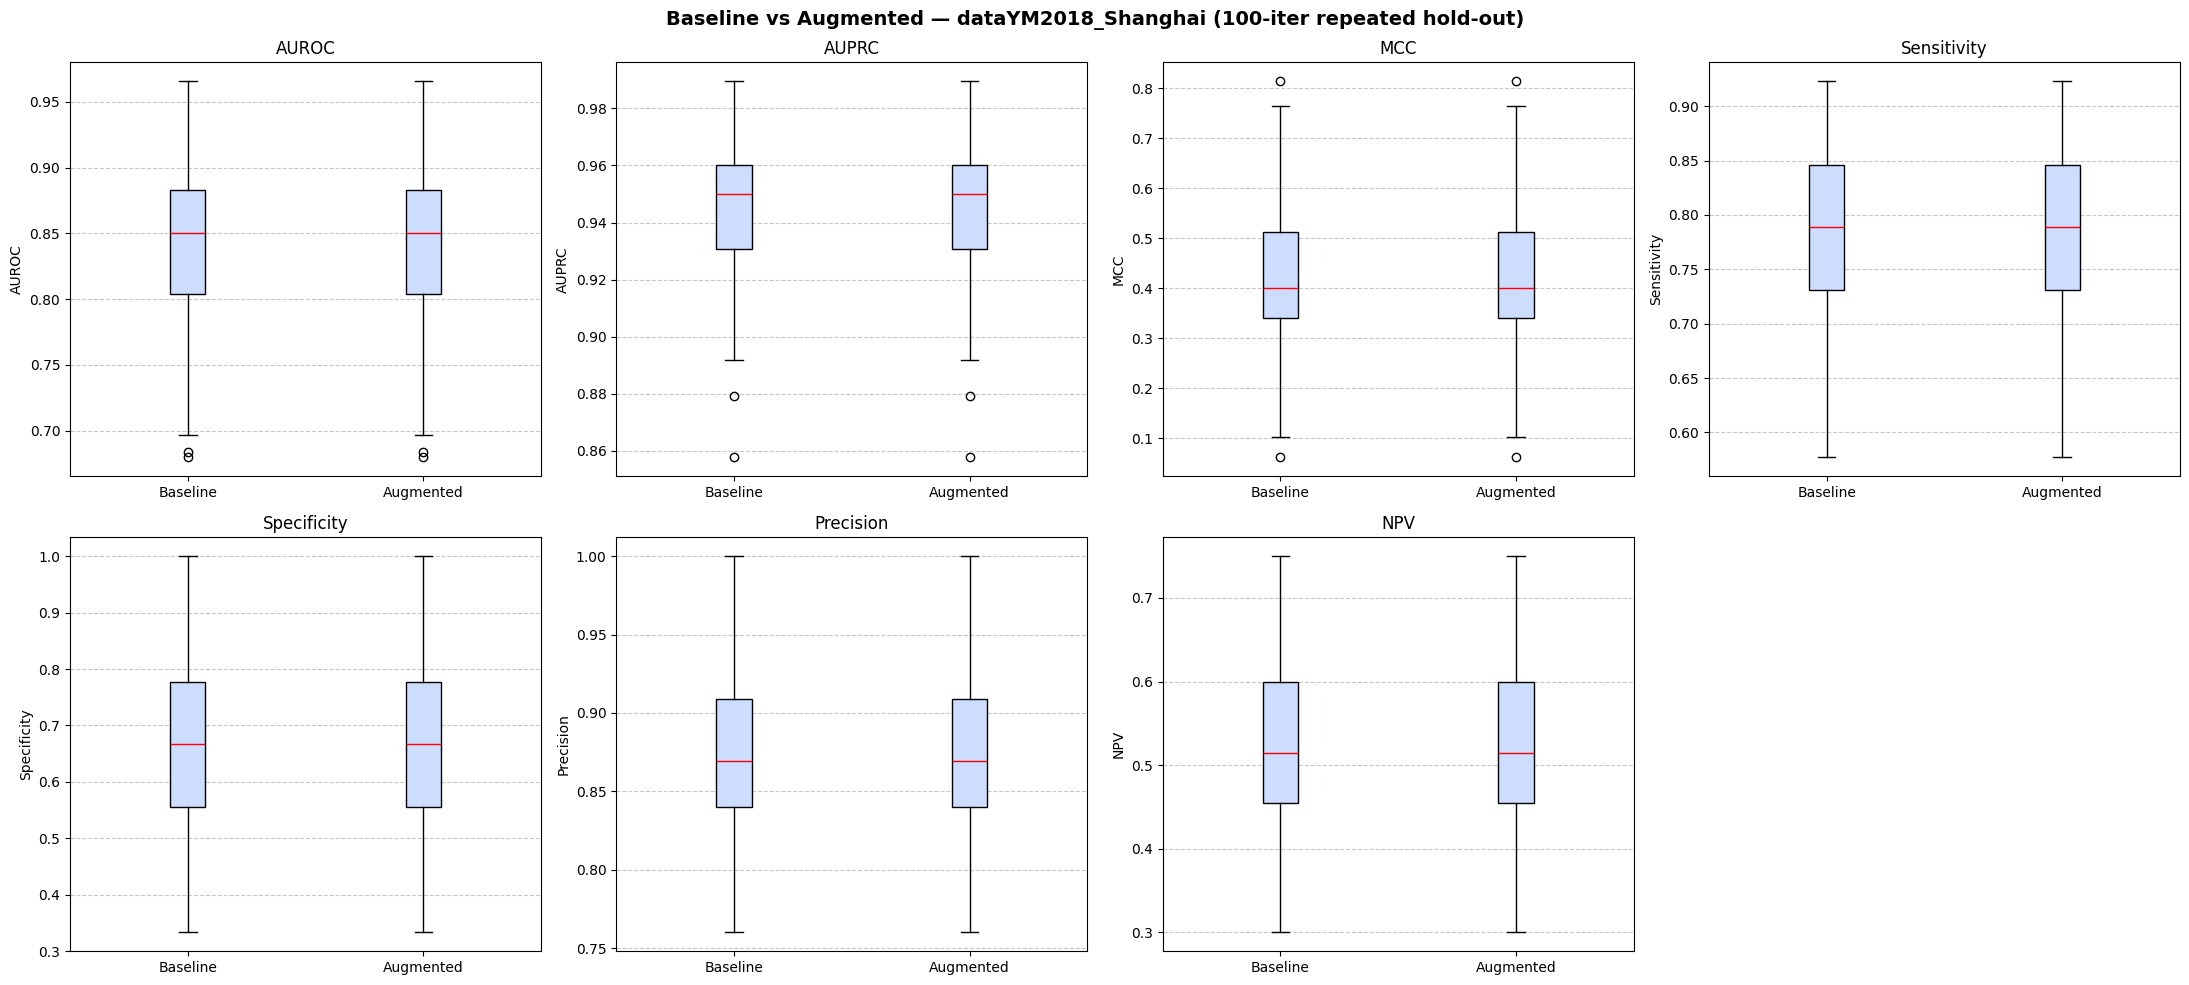

=== Numeric summary (all metrics) ===

Baseline (cv_df):
             count    mean     std     min     25%     50%     75%     max
auroc        100.0  0.8407  0.0624  0.6795  0.8040  0.8504  0.8830  0.9658
auprc        100.0  0.9450  0.0244  0.8576  0.9306  0.9499  0.9600  0.9896
mcc          100.0  0.4241  0.1485  0.0620  0.3411  0.4017  0.5132  0.8145
sensitivity  100.0  0.7865  0.0744  0.5769  0.7308  0.7885  0.8462  0.9231
specificity  100.0  0.6644  0.1506  0.3333  0.5556  0.6667  0.7778  1.0000
precision    100.0  0.8737  0.0514  0.7600  0.8400  0.8696  0.9091  1.0000
npv          100.0  0.5263  0.1017  0.3000  0.4545  0.5147  0.6000  0.7500

Augmented (cv_aug):
             count    mean     std     min     25%     50%     75%     max
auroc        100.0  0.8407  0.0624  0.6795  0.8040  0.8504  0.8830  0.9658
auprc        100.0  0.9450  0.0244  0.8576  0.9306  0.9499  0.9600  0.9896
mcc          100.0  0.4241  0.1485  0.0620  0.3411  0.4017  0.5132  0.8145
sensitivity  100.0  0.

In [89]:
# ============================================================
# 12.7 — Comparison boxplots: Baseline vs Augmented (dataYM2018)
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for i, m in enumerate(ALL_METRICS):
    ax = axes_flat[i]
    data = [cv_df[m], cv_aug[m]]
    bp = ax.boxplot(data, labels=["Baseline", "Augmented"], patch_artist=True,
                    boxprops=dict(facecolor="#ccddff"), medianprops=dict(color="red"))
    ax.set_title(f"{METRIC_LABELS[m]}", fontsize=12)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)

axes_flat[7].set_visible(False)

plt.suptitle(f"Baseline vs Augmented — {DATASET_NAME_D2} ({N_REPEATS}-iter repeated hold-out)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("=== Numeric summary (all metrics) ===")
print("\nBaseline (cv_df):")
print(cv_df[ALL_METRICS].describe().T.round(4))
print("\nAugmented (cv_aug):")
print(cv_aug[ALL_METRICS].describe().T.round(4))

In [90]:
# ============================================================
# 12.8 — Merge synthetic data & retrain (for SHAP + calibration)
# ============================================================
# We need a single augmented model for SHAP and calibration plots.
# This mirrors Part 8 of the original pipeline.

from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset

# --- Conditional augmentation on training split ---
pos_mask = (y_train == 1)
n_pos = int(pos_mask.sum())
n_neg = int((~pos_mask).sum())
n_pos_needed = max(0, n_neg - n_pos)

print(f"Train counts: neg={n_neg} pos={n_pos} → synth positives to add ≈ {n_pos_needed}")

if n_pos >= 5 and n_pos_needed > 0:
    train_pos_features = X_train.loc[pos_mask].copy()
    meta_pos = SingleTableMetadata()
    meta_pos.detect_from_dataframe(train_pos_features)
    model_pos = SingleTablePreset(meta_pos, name="FAST_ML")
    model_pos.fit(train_pos_features)
    synthetic_cond = model_pos.sample(n_pos_needed).reindex(columns=X_train.columns, fill_value=np.nan)

    combo_raw = pd.concat([X_train, synthetic_cond], axis=0, ignore_index=True)
    combo_y = pd.concat([y_train, pd.Series(np.ones(len(synthetic_cond), dtype=y_train.dtype))],
                        axis=0, ignore_index=True)
else:
    synthetic_cond = pd.DataFrame(columns=X_train.columns)
    combo_raw = X_train.copy()
    combo_y = y_train.copy()

# --- Refit preprocessor on augmented data & train ---
pre_aug = clone(pre)
Xtr_aug = pre_aug.fit_transform(combo_raw)
Xva_aug = pre_aug.transform(X_val)
Xte_aug = pre_aug.transform(X_test)

clf_aug = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_aug.fit(Xtr_aug, combo_y)

p_aug_test = clf_aug.predict_proba(Xte_aug)[:, 1]
aug_metrics = compute_all_metrics(y_test, p_aug_test)
print(f"[D2-AUGMENTED][TEST] AUROC={aug_metrics['auroc']:.4f} | AUPRC={aug_metrics['auprc']:.4f} | "
      f"MCC={aug_metrics['mcc']:.4f} | Sens={aug_metrics['sensitivity']:.4f} | "
      f"Spec={aug_metrics['specificity']:.4f} | Prec={aug_metrics['precision']:.4f} | "
      f"NPV={aug_metrics['npv']:.4f}")

# Update 'pre' reference so downstream cells (SHAP, calibration) find it
pre = pre_aug
Xtr = Xtr_aug
Xva = Xva_aug
Xte = Xte_aug

Train counts: neg=31 pos=90 → synth positives to add ≈ 0
[D2-AUGMENTED][TEST] AUROC=0.8143 | AUPRC=0.9449 | MCC=0.2286 | Sens=0.8000 | Spec=0.4286 | Prec=0.8000 | NPV=0.4286


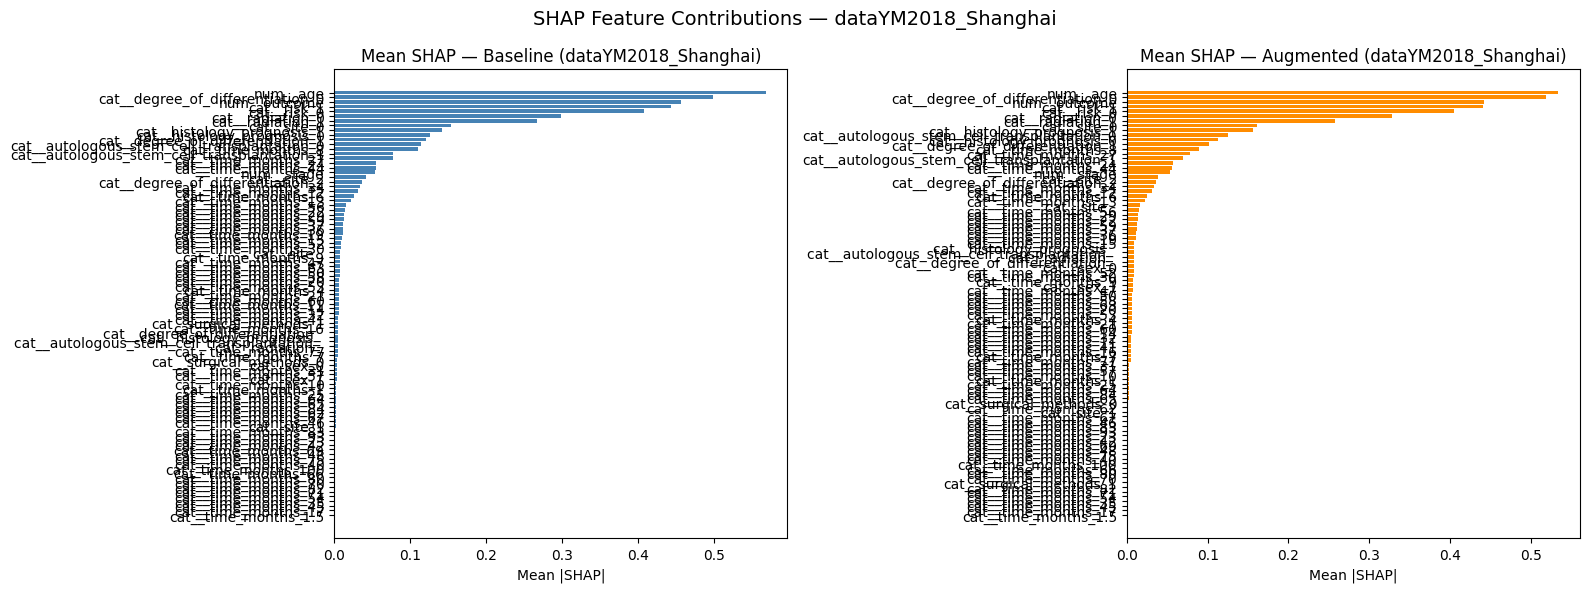

In [91]:
# ============================================================
# 12.9 — SHAP: Baseline vs Augmented (dataYM2018)
# ============================================================

import shap
import matplotlib.pyplot as plt
from sklearn.base import clone

# --- Feature names ---
def get_feature_names(pre_fitted, X_fit):
    try:
        return list(pre_fitted.get_feature_names_out())
    except Exception:
        return [f"feat_{i}" for i in range(pre_fitted.transform(X_fit).shape[1])]

# --- Baseline model ---
pre_baseline_d2 = clone(pre)
pre_baseline_d2.fit(X_train)
Xte_b = pre_baseline_d2.transform(X_test)
clf_baseline_d2 = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_baseline_d2.fit(pre_baseline_d2.transform(X_train), y_train)

feat_names = get_feature_names(pre_baseline_d2, X_train)

# --- SHAP for both ---
def _todense(M):
    return M.toarray() if hasattr(M, 'toarray') else np.asarray(M)

Xte_dense_b = _todense(Xte_b)
Xte_dense_a = _todense(Xte)

explainer_b = shap.LinearExplainer(clf_baseline_d2, _todense(pre_baseline_d2.transform(X_train)))
shap_b = explainer_b.shap_values(Xte_dense_b)

explainer_a = shap.LinearExplainer(clf_aug, _todense(Xtr))
shap_a = explainer_a.shap_values(Xte_dense_a)

# --- Global importance bar chart (side by side) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_n_b = feat_names[:shap_b.shape[1]] if len(feat_names) >= shap_b.shape[1] else [f"f{i}" for i in range(shap_b.shape[1])]
feat_n_a = get_feature_names(pre, combo_raw)[:shap_a.shape[1]] if len(get_feature_names(pre, combo_raw)) >= shap_a.shape[1] else [f"f{i}" for i in range(shap_a.shape[1])]

imp_b = np.abs(shap_b).mean(axis=0)
imp_a = np.abs(shap_a).mean(axis=0)

idx_b = np.argsort(imp_b)
idx_a = np.argsort(imp_a)

axes[0].barh([feat_n_b[i] for i in idx_b], imp_b[idx_b], color="steelblue")
axes[0].set_title(f"Mean SHAP — Baseline ({DATASET_NAME_D2})")
axes[0].set_xlabel("Mean |SHAP|")

axes[1].barh([feat_n_a[i] for i in idx_a], imp_a[idx_a], color="darkorange")
axes[1].set_title(f"Mean SHAP — Augmented ({DATASET_NAME_D2})")
axes[1].set_xlabel("Mean |SHAP|")

plt.suptitle(f"SHAP Feature Contributions — {DATASET_NAME_D2}", fontsize=14)
plt.tight_layout()
plt.show()

Brier (raw):        0.1711
Brier (calibrated): 0.1927


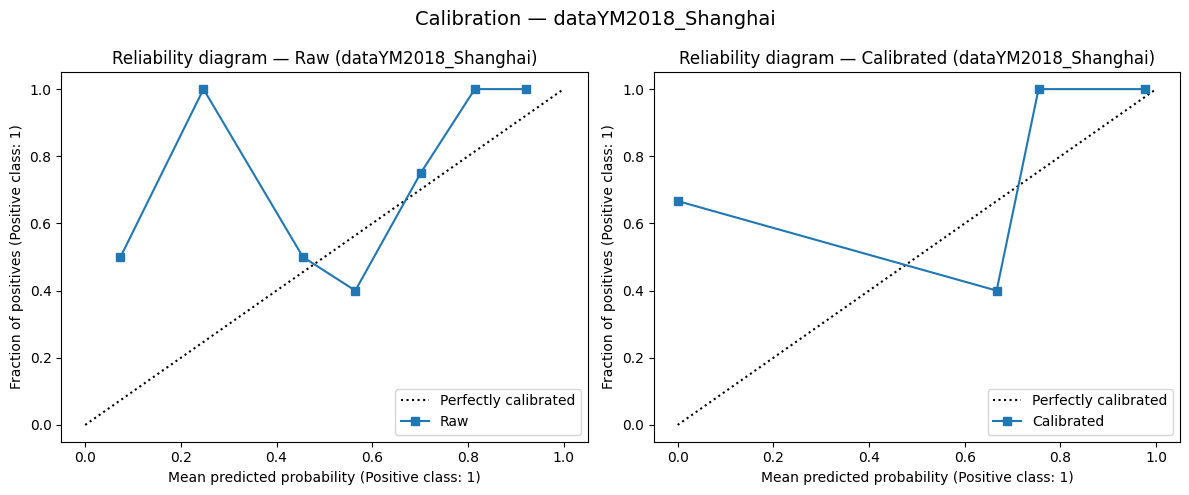

In [92]:
# ============================================================
# 12.10 — Calibration (raw vs post-hoc) on dataYM2018
# ============================================================

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# --- Raw probabilities ---
proba_raw = clf_aug.predict_proba(Xte)[:, 1]

# --- Calibrate with isotonic regression on validation set ---
cal_iso = CalibratedClassifierCV(clf_aug, method='isotonic', cv='prefit')
cal_iso.fit(Xva, y_val)
proba_cal = cal_iso.predict_proba(Xte)[:, 1]

brier_raw = brier_score_loss(y_test, proba_raw)
brier_cal = brier_score_loss(y_test, proba_cal)

print(f"Brier (raw):        {brier_raw:.4f}")
print(f"Brier (calibrated): {brier_cal:.4f}")

# --- Reliability diagrams ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

CalibrationDisplay.from_predictions(y_test, proba_raw, n_bins=8, strategy='uniform',
                                     ax=axes[0], name="Raw")
axes[0].set_title(f"Reliability diagram — Raw ({DATASET_NAME_D2})")

CalibrationDisplay.from_predictions(y_test, proba_cal, n_bins=8, strategy='uniform',
                                     ax=axes[1], name="Calibrated")
axes[1].set_title(f"Reliability diagram — Calibrated ({DATASET_NAME_D2})")

plt.suptitle(f"Calibration — {DATASET_NAME_D2}", fontsize=14)
plt.tight_layout()
plt.show()

In [93]:
# ============================================================
# 12.11 — Privacy audit: nearest-neighbour distances (dataYM2018)
# ============================================================

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# --- 0) Check if synthetic data exists ---
if 'synthetic_cond' in globals() and len(synthetic_cond) > 0:
    # --- Align synthetic data to training feature space ---
    synth_aligned = synthetic_cond.reindex(columns=X_train.columns, fill_value=np.nan)

    def _todense(M):
        return M.toarray() if hasattr(M, 'toarray') else np.asarray(M)

    Xtr_dense = _todense(pre.transform(X_train))
    Xs_dense = _todense(pre.transform(synth_aligned))

    # --- NN distances: synthetic→real ---
    nn = NearestNeighbors(n_neighbors=1).fit(Xtr_dense)
    dists_syn, _ = nn.kneighbors(Xs_dense)
    dists_syn = dists_syn.ravel()

    # --- NN distances: real→real (leave-one-out) ---
    nn_real = NearestNeighbors(n_neighbors=2).fit(Xtr_dense)
    dists_real, _ = nn_real.kneighbors(Xtr_dense)
    dists_real = dists_real[:, 1]  # exclude self-match

    # --- Histogram ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(dists_syn, bins=20, alpha=0.6, label="Synthetic→Real", color="steelblue")
    ax.hist(dists_real, bins=20, alpha=0.4, label="Real→Real (LOO)", color="salmon")
    ax.axvline(x=np.percentile(dists_real, 5), color='red', linestyle='--', label='5th pctl real-real')
    ax.set_xlabel("NN distance")
    ax.set_ylabel("Count")
    ax.set_title(f"NN distance distribution — {DATASET_NAME_D2}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Quick memorization check ---
    threshold = np.percentile(dists_real, 5)
    n_suspicious = int((dists_syn < threshold).sum())
    print(f"Synthetic records closer than 5th percentile of real-real: {n_suspicious}/{len(dists_syn)}")
    if n_suspicious == 0:
        print("✅ No evidence of record-level memorization.")
    else:
        print(f"☀ {n_suspicious} records fall below threshold — review GAN configuration.")
else:
    print("[Privacy] No synthetic samples generated for this cohort; skipping audit.")

[Privacy] No synthetic samples generated for this cohort; skipping audit.


Original features: 91 | Training samples: 121 | Feature/sample ratio: 0.75
→ SelectKBest(k=15) + L2 norm → data_norm=1.0 | feature/sample ratio: 0.12

=== DP Privacy-Utility sweep — dataYM2018_Shanghai (SelectKBest k=15 + L2, data_norm=1.0, 7 metrics) ===


,auroc_mean,auroc_std,auprc_mean,auprc_std,mcc_mean,mcc_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,precision_mean,precision_std,npv_mean,npv_std,ece_post_mean,brier_post_mean
epsilon,,,,,,,,,,,,,,,,
inf,0.603571,0.000000,0.829802,0.000000,0.106500,0.000000,0.55,0.000000,0.571429,0.000000,0.785714,0.000000,0.307692,0.000000,0.120040,0.201521
16.0,0.609286,0.073696,0.835045,0.028485,0.066299,0.148250,1.00,0.000000,0.028571,0.063888,0.746439,0.012741,0.200000,0.447214,0.124601,0.199911
8.0,0.588571,0.130770,0.817875,0.052602,0.046991,0.241854,0.97,0.027386,0.085714,0.191663,0.753821,0.040704,0.150000,0.335410,0.100501,0.209476
4.0,0.531429,0.153829,0.781062,0.073431,-0.017521,0.228633,0.87,0.044721,0.142857,0.202031,0.745937,0.044213,0.180000,0.248998,0.108987,0.212619
2.0,0.498571,0.151662,0.763531,0.070079,-0.057005,0.175775,0.73,0.164317,0.228571,0.216654,0.730281,0.043471,0.179487,0.169114,0.038973,0.206879


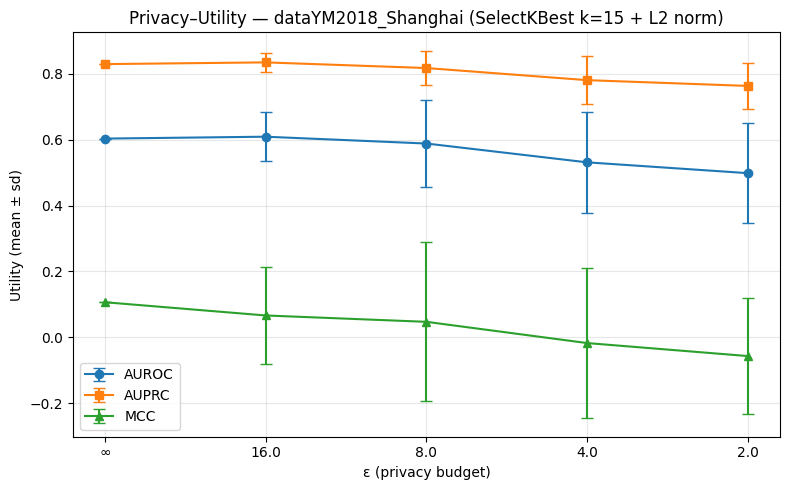

In [94]:
# ============================================================
# 12.12 — DP Logistic Regression ε-sweep (dataYM2018)
# ============================================================
# UNIFORM preprocessing: SelectKBest(k=min(15,p)) + L2 normalisation
# Same protocol as Cell 10c (GSE3960) and Cell 13.9 (TCGA-ACC).
# data_norm = 1.0 across all datasets.
# ============================================================

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, matthews_corrcoef, confusion_matrix)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.isotonic import IsotonicRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import normalize
from sklearn.base import clone
import matplotlib.pyplot as plt

try:
    from diffprivlib.models import LogisticRegression as DpLogReg
except ImportError:
    print("diffprivlib not installed — run: !pip install diffprivlib")
    DpLogReg = None

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * abs(acc - conf)
    return ece / len(y_true)

if DpLogReg is not None:
    # ------------------------------------------------------------------
    # STEP 1: Transform augmented training data through the fitted 'pre'
    # ------------------------------------------------------------------
    # 'Xtr' and 'Xte' at this point contain the dataYM2018 augmented data
    # from Cell 12.8 (pre_aug fitted on combo_raw).
    # 'combo_y' contains the augmented labels.
    Xtr_raw = Xtr.toarray() if hasattr(Xtr, 'toarray') else np.asarray(Xtr)
    Xte_raw = Xte.toarray() if hasattr(Xte, 'toarray') else np.asarray(Xte)
    y_tr_np = np.asarray(combo_y).ravel()
    y_te_np = np.asarray(y_test).ravel()

    print(f"Original features: {Xtr_raw.shape[1]} | "
          f"Training samples: {Xtr_raw.shape[0]} | "
          f"Feature/sample ratio: {Xtr_raw.shape[1]/Xtr_raw.shape[0]:.2f}")

    # ------------------------------------------------------------------
    # STEP 2: SelectKBest + L2 normalisation (UNIFORM with GSE3960/ACC)
    # ------------------------------------------------------------------
    K_SEL = min(15, Xtr_raw.shape[1])
    selector = SelectKBest(mutual_info_classif, k=K_SEL)
    Xtr_sel = selector.fit_transform(Xtr_raw, y_tr_np)
    Xte_sel = selector.transform(Xte_raw)

    Xtr_dp = normalize(Xtr_sel, norm="l2")
    Xte_dp = normalize(Xte_sel, norm="l2")
    data_norm = 1.0

    print(f"→ SelectKBest(k={K_SEL}) + L2 norm → data_norm={data_norm:.1f} | "
          f"feature/sample ratio: {K_SEL/Xtr_dp.shape[0]:.2f}")

    # ------------------------------------------------------------------
    # STEP 3: ε-sweep (same grid as GSE3960 and TCGA-ACC)
    # ------------------------------------------------------------------
    epsilons = [float('inf'), 16, 8, 4, 2]
    N_SEEDS = 5
    dp_rows = []

    for eps in epsilons:
        for seed in range(N_SEEDS):
            if eps == float('inf'):
                m = LogisticRegression(max_iter=2000, class_weight="balanced",
                                       random_state=seed)
            else:
                m = DpLogReg(epsilon=eps, data_norm=data_norm, max_iter=2000,
                             random_state=seed)

            m.fit(Xtr_dp, y_tr_np)
            p = np.clip(m.predict_proba(Xte_dp)[:, 1], 1e-8, 1 - 1e-8)

            auroc = roc_auc_score(y_te_np, p)
            auprc = average_precision_score(y_te_np, p)
            ece_pre = expected_calibration_error(y_te_np, p)
            brier_pre = brier_score_loss(y_te_np, p)

            # Post-hoc calibration (isotonic) — internal validation split
            sss_cal = StratifiedShuffleSplit(n_splits=1, test_size=0.2,
                                             random_state=seed)
            train_idx, val_idx = next(sss_cal.split(Xtr_dp, y_tr_np))
            X_cal_tr, y_cal_tr = Xtr_dp[train_idx], y_tr_np[train_idx]
            X_cal_va, y_cal_va = Xtr_dp[val_idx],  y_tr_np[val_idx]

            if eps == float('inf'):
                calib_m = LogisticRegression(max_iter=2000, class_weight="balanced",
                                             random_state=seed)
            else:
                calib_m = DpLogReg(epsilon=eps, data_norm=data_norm, max_iter=2000,
                                   random_state=seed)
            calib_m.fit(X_cal_tr, y_cal_tr)
            p_val = np.clip(calib_m.predict_proba(X_cal_va)[:, 1], 1e-8, 1 - 1e-8)
            iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
            iso.fit(p_val, y_cal_va)
            p_cal = iso.predict(p)
            ece_post = expected_calibration_error(y_te_np, p_cal)
            brier_post = brier_score_loss(y_te_np, p_cal)

            # Threshold-dependent metrics
            y_pred_dp = (p >= CLASSIFICATION_THRESHOLD).astype(int)
            cm = confusion_matrix(y_te_np, y_pred_dp, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()

            dp_rows.append({
                'epsilon': eps, 'seed': seed,
                'auroc': auroc, 'auprc': auprc,
                'mcc': matthews_corrcoef(y_te_np, y_pred_dp),
                'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
                'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
                'precision': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
                'npv': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
                'ece_pre': ece_pre, 'ece_post': ece_post,
                'brier_pre': brier_pre, 'brier_post': brier_post
            })

    dp_df = pd.DataFrame(dp_rows)

    # ------------------------------------------------------------------
    # STEP 4: Summary table (same aggregation as GSE3960 and TCGA-ACC)
    # ------------------------------------------------------------------
    agg_dict_dp = {
        'auroc_mean': ('auroc', 'mean'), 'auroc_std': ('auroc', 'std'),
        'auprc_mean': ('auprc', 'mean'), 'auprc_std': ('auprc', 'std'),
        'mcc_mean': ('mcc', 'mean'), 'mcc_std': ('mcc', 'std'),
        'sensitivity_mean': ('sensitivity', 'mean'), 'sensitivity_std': ('sensitivity', 'std'),
        'specificity_mean': ('specificity', 'mean'), 'specificity_std': ('specificity', 'std'),
        'precision_mean': ('precision', 'mean'), 'precision_std': ('precision', 'std'),
        'npv_mean': ('npv', 'mean'), 'npv_std': ('npv', 'std'),
        'ece_post_mean': ('ece_post', 'mean'), 'brier_post_mean': ('brier_post', 'mean')
    }
    dp_summary = dp_df.groupby('epsilon').agg(**agg_dict_dp).sort_index(ascending=False)

    print(f"\n=== DP Privacy-Utility sweep — {DATASET_NAME_D2} "
          f"(SelectKBest k={K_SEL} + L2, data_norm={data_norm:.1f}, 7 metrics) ===")
    display(dp_summary)

    # ------------------------------------------------------------------
    # STEP 5: Privacy-utility plot (AUROC + AUPRC + MCC)
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 5))
    eps_labels = [str(e) if e != float('inf') else '∞' for e in dp_summary.index]
    x_pos = range(len(eps_labels))
    ax.errorbar(x_pos, dp_summary['auroc_mean'], yerr=dp_summary['auroc_std'],
                marker='o', label='AUROC', capsize=4)
    ax.errorbar(x_pos, dp_summary['auprc_mean'], yerr=dp_summary['auprc_std'],
                marker='s', label='AUPRC', capsize=4)
    ax.errorbar(x_pos, dp_summary['mcc_mean'], yerr=dp_summary['mcc_std'],
                marker='^', label='MCC', capsize=4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(eps_labels)
    ax.set_xlabel('ε (privacy budget)')
    ax.set_ylabel('Utility (mean ± sd)')
    ax.set_title(f'Privacy–Utility — {DATASET_NAME_D2} (SelectKBest k={K_SEL} + L2 norm)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

CROSS-DATASET COMPARISON: GSE3960 vs dataYM2018 (7 metrics)


,Dataset,N,Features,Base AUROC,Aug AUROC,ΔAUROC,Base AUPRC,Aug AUPRC,ΔAUPRC,Base MCC,...,ΔSensitivity,Base Specificity,Aug Specificity,ΔSpecificity,Base Precision,Aug Precision,ΔPrecision,Base NPV,Aug NPV,ΔNPV
0,GSE3960,101,7,0.9400 ± 0.0615,0.9407 ± 0.0677,+0.0007,0.8388 ± 0.1463,0.8557 ± 0.1361,+0.0169,0.6950 ± 0.1708,...,+0.0000,0.9112 ± 0.0692,0.9382 ± 0.0587,+0.0271,0.7206 ± 0.1805,0.7899 ± 0.1811,+0.0693,0.9550 ± 0.0383,0.9565 ± 0.0394,+0.0015
1,dataYM2018 (Shanghai),173,12,0.8407 ± 0.0624,0.8407 ± 0.0624,+0.0000,0.9450 ± 0.0244,0.9450 ± 0.0244,+0.0000,0.4241 ± 0.1485,...,+0.0000,0.6644 ± 0.1506,0.6644 ± 0.1506,+0.0000,0.8737 ± 0.0514,0.8737 ± 0.0514,+0.0000,0.5263 ± 0.1017,0.5263 ± 0.1017,+0.0000


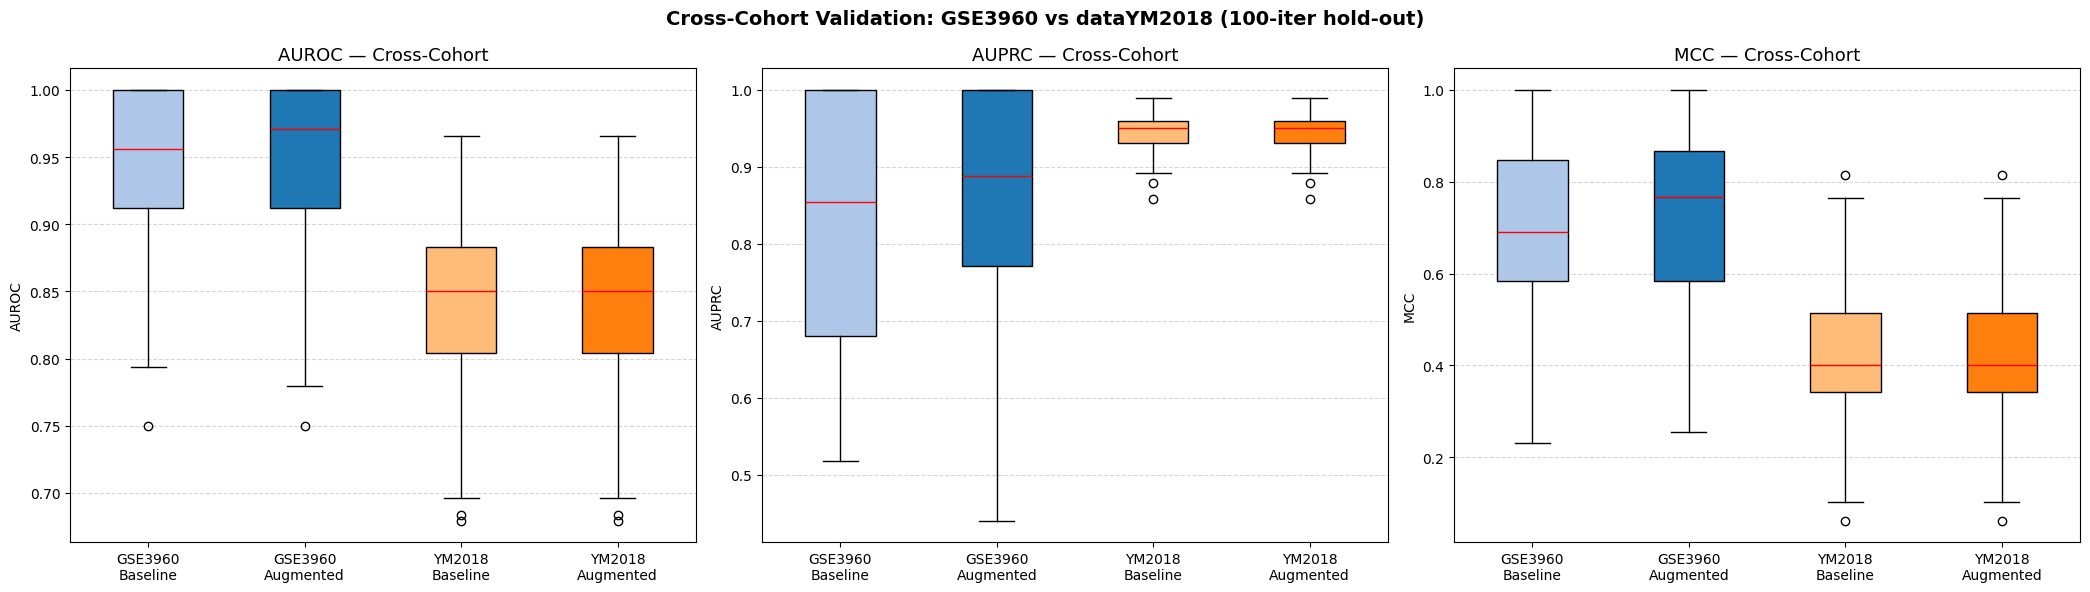


✅ Cross-cohort validation complete. Results ready for paper integration.


In [95]:
# ============================================================
# 12.13 — Archive dataYM2018 results & cross-dataset comparison
# ============================================================

results_ym2018 = {
    "dataset": "dataYM2018 (Shanghai)",
    "n_samples": len(df2),
    "n_features": df2.shape[1] - 1,
    "target": TARGET_COLUMN_D2,
    "cv_baseline": cv_df.copy(),
    "cv_augmented": cv_aug.copy(),
}
for m in ALL_METRICS:
    results_ym2018[f"baseline_{m}_mean"] = cv_df[m].mean()
    results_ym2018[f"baseline_{m}_std"]  = cv_df[m].std()
    results_ym2018[f"aug_{m}_mean"]      = cv_aug[m].mean()
    results_ym2018[f"aug_{m}_std"]       = cv_aug[m].std()

# --- Cross-dataset summary table ---
print("=" * 100)
print("CROSS-DATASET COMPARISON: GSE3960 vs dataYM2018 (7 metrics)")
print("=" * 100)

rows_comp = []
for r in [results_gse3960, results_ym2018]:
    row = {"Dataset": r["dataset"], "N": r["n_samples"], "Features": r["n_features"]}
    for m in ALL_METRICS:
        b_mu = r.get(f"baseline_{m}_mean", float("nan"))
        b_sd = r.get(f"baseline_{m}_std", float("nan"))
        a_mu = r.get(f"aug_{m}_mean", float("nan"))
        a_sd = r.get(f"aug_{m}_std", float("nan"))
        row[f"Base {METRIC_LABELS[m]}"] = f"{b_mu:.4f} ± {b_sd:.4f}"
        row[f"Aug {METRIC_LABELS[m]}"]  = f"{a_mu:.4f} ± {a_sd:.4f}"
        row[f"Δ{METRIC_LABELS[m]}"]     = f"{a_mu - b_mu:+.4f}"
    rows_comp.append(row)

comparison = pd.DataFrame(rows_comp)
display(comparison)

# --- Side-by-side boxplots (both datasets, AUROC + AUPRC + MCC) ---
key_metrics = ["auroc", "auprc", "mcc"]
fig, axes = plt.subplots(1, len(key_metrics), figsize=(7 * len(key_metrics), 6))

for i, m in enumerate(key_metrics):
    ax = axes[i]
    data = [
        results_gse3960["cv_baseline"][m],
        results_gse3960["cv_augmented"][m],
        results_ym2018["cv_baseline"][m],
        results_ym2018["cv_augmented"][m],
    ]
    labels = ["GSE3960\nBaseline", "GSE3960\nAugmented",
              "YM2018\nBaseline", "YM2018\nAugmented"]
    colors = ["#aec7e8", "#1f77b4", "#ffbb78", "#ff7f0e"]

    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color="red"))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(f"{METRIC_LABELS[m]} — Cross-Cohort", fontsize=13)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.suptitle(f"Cross-Cohort Validation: GSE3960 vs dataYM2018 ({N_REPEATS}-iter hold-out)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✅ Cross-cohort validation complete. Results ready for paper integration.")

---
# Part 13 — Cross-Disease Validation: Mesothelioma (UCI ML Repository)

This section applies the **same GAN-augmented pipeline** to a non-neuroblastoma  
rare-disease cohort to test **cross-disease transferability**.

**Dataset**: Mesothelioma's disease data set (Tanrikulu & Er, 2012)  
**Source**: [UCI ML Repository #351](https://archive.ics.uci.edu/dataset/351/)  
**Characteristics**: 324 patients, 34 clinical/lab features, binary target, no missing values  
**License**: CC BY 4.0  

Run **all cells of Parts 1–12** first before executing this section.

In [96]:
# ============================================================
# 13.0 — Archive dataYM2018 results
# ============================================================

assert 'results_ym2018' in globals(), "Run Part 12 first."
assert 'results_gse3960' in globals(), "Run Part 12 first."
print("✅ Previous results available for final cross-dataset comparison.")

✅ Previous results available for final cross-dataset comparison.


In [97]:
import pandas as pd
import numpy as np
import json, requests
import warnings
warnings.filterwarnings('ignore')

DATASET_NAME_D3 = "TCGA_ACC_Adrenocortical"
STUDY_ID = "acc_tcga"

print(f"Loading {DATASET_NAME_D3} from cBioPortal API...")

# --- Fetch all clinical patient data via REST API ---
url_patients = f"https://www.cbioportal.org/api/studies/{STUDY_ID}/clinical-data?clinicalDataType=PATIENT&projection=DETAILED"
raw_patient = requests.get(url_patients, headers={"Accept": "application/json"}).json()

# --- Fetch all clinical sample data ---
url_samples = f"https://www.cbioportal.org/api/studies/{STUDY_ID}/clinical-data?clinicalDataType=SAMPLE&projection=DETAILED"
raw_sample = requests.get(url_samples, headers={"Accept": "application/json"}).json()

# --- Pivot function ---
def pivot_clinical(records, id_col="patientId"):
    rows = {}
    for r in records:
        pid = r[id_col]
        if pid not in rows: rows[pid] = {}
        rows[pid][r["clinicalAttributeId"]] = r["value"]
    return pd.DataFrame.from_dict(rows, orient="index")

df_pat = pivot_clinical(raw_patient, "patientId")
df_samp = pivot_clinical(raw_sample, "sampleId")

# --- Correctly map Patient IDs to Samples ---
sample_to_patient = {r['sampleId']: r['patientId'] for r in raw_sample}
df_samp['patientId'] = df_samp.index.map(sample_to_patient)

# --- Merge Sample data (Target) with Patient data (Features) ---
# We use the first sample available per patient for this classification task
df_samp_first = df_samp.drop_duplicates(subset=['patientId'])
df3 = df_samp_first.merge(df_pat, left_on='patientId', right_index=True, how='inner')

print(f"\nFinal Merged Shape: {df3.shape}")
print(f"Target 'OS_STATUS' found: {'OS_STATUS' in df3.columns}")
display(df3.head())

Loading TCGA_ACC_Adrenocortical from cBioPortal API...

Final Merged Shape: (92, 84)
Target 'OS_STATUS' found: True


,CANCER_TYPE,CANCER_TYPE_DETAILED,DAYS_TO_COLLECTION,FRACTION_GENOME_ALTERED,IS_FFPE,MUTATION_COUNT,OCT_EMBEDDED,ONCOTREE_CODE,OTHER_SAMPLE_ID,PATHOLOGY_REPORT_FILE_NAME,...,PHARM_TX_MITOTANE_FOR_MACRO_DISEASE,TREATMENT_OUTCOME_FIRST_COURSE,DAYS_LAST_FOLLOWUP,PHARM_TX_MITOTANE_ADJUVANT,PHARM_TX_MITOTANE_THERAPUTIC_AT_REC,PHARM_TX_MITOTANE_THERAPUTIC_LEVELS,METASTATIC_DX_CONFIRMED_BY_OTHER,PHARM_TX_MITOTANE_THERAPUTIC_MACRO,PHARM_TX_MITOTANE_THERAPUTIC_AT_PROG,RET
TCGA-OR-A5J1-01,Adrenocortical Carcinoma,Adrenocortical Carcinoma,4691,0.0585,NO,39,TRUE,ACC,E4038EBB-6E6D-44B1-84AD-E35AAFCA7B70,TCGA-OR-A5J1.8866FD87-4F6F-4D7E-B99A-7DD427ED3...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J2-01,Adrenocortical Carcinoma,Adrenocortical Carcinoma,3124,0.4033,NO,81,TRUE,ACC,46B7EB7C-E5F7-476D-A68C-5972F947445F,TCGA-OR-A5J2.345C34EE-F031-41A4-B955-BA054F2A3...,...,YES,Progressive Disease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J3-01,Adrenocortical Carcinoma,Adrenocortical Carcinoma,1584,0.4131,NO,69,TRUE,ACC,1FB59B6F-53C0-4B14-82CC-77CD55C67AD6,TCGA-OR-A5J3.83F53610-4F40-425B-9B69-BBB942342...,...,NaN,Complete Remission/Response,1942,YES,YES,YES,NaN,NaN,NaN,NaN
TCGA-OR-A5J4-01,Adrenocortical Carcinoma,Adrenocortical Carcinoma,4642,0.9259,NO,171,TRUE,ACC,51EE1274-9144-4464-AA1E-AD15D9086984,TCGA-OR-A5J4.39E300DC-C01F-46BC-AE4C-D834458F1...,...,YES,Progressive Disease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-OR-A5J5-01,Adrenocortical Carcinoma,Adrenocortical Carcinoma,4537,0.8015,NO,521,TRUE,ACC,C6214F9B-35C8-424C-B6FE-BEC1A9317C0A,TCGA-OR-A5J5.BB63299C-B7F7-4F08-998D-C30E56CD6...,...,YES,Progressive Disease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
# ============================================================
# 13.2 — Target definition, feature selection & cleaning
# ============================================================
# ACC (Adrenocortical Carcinoma): rare endocrine malignancy
# ~1-2 cases per million/year worldwide
# Target: OS_STATUS (overall survival status)

TARGET_COLUMN_D3 = "OS_STATUS"
TASK_TYPE_D3 = "classification"

# --- Check raw target values ---
print("Raw OS_STATUS values:")
print(df3[TARGET_COLUMN_D3].value_counts(dropna=False))

# --- Remap to binary: 1 = DECEASED (minority, clinically relevant), 0 = LIVING ---
df3[TARGET_COLUMN_D3] = df3[TARGET_COLUMN_D3].map(
    lambda x: 1 if "DECEASED" in str(x).upper() or "DEAD" in str(x).upper()
    else (0 if "LIVING" in str(x).upper() or "ALIVE" in str(x).upper() else np.nan)
)
df3 = df3.dropna(subset=[TARGET_COLUMN_D3])
df3[TARGET_COLUMN_D3] = df3[TARGET_COLUMN_D3].astype(int)

print(f"\nAfter remapping (1=deceased, 0=living):")
print(df3[TARGET_COLUMN_D3].value_counts(dropna=False))

n_pos = int((df3[TARGET_COLUMN_D3] == 1).sum())
n_neg = int((df3[TARGET_COLUMN_D3] == 0).sum())
print(f"\nClass balance: deceased (1) = {n_pos}, living (0) = {n_neg}")
print(f"Minority ratio: {n_pos/(n_pos+n_neg)*100:.1f}%")

# --- Remove leaky, outcome-related, constant, and ID columns ---
LEAKY_AND_EXCLUDE = [
    # Outcome / post-treatment (leaky)
    'OS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS',
    'TUMOR_STATUS', 'TREATMENT_OUTCOME_FIRST_COURSE',
    'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT',
    'CLINICAL_STATUS_WITHIN_3_MTHS_SURGERY',
    'DAYS_LAST_FOLLOWUP',
    # Treatment variables (post-diagnosis decisions, potential leakage)
    'PHARMACEUTICAL_TX_ADJUVANT', 'RADIATION_TREATMENT_ADJUVANT',
    'PHARM_TX_MITOTANE_ADJUVANT', 'PHARM_TX_MITOTANE_FOR_MACRO_DISEASE',
    'PHARM_TX_MITOTANE_INDICATOR', 'PHARM_TX_MITOTANE_THERAPUTIC_AT_PROG',
    'PHARM_TX_MITOTANE_THERAPUTIC_AT_REC', 'PHARM_TX_MITOTANE_THERAPUTIC_LEVELS',
    'PHARM_TX_MITOTANE_THERAPUTIC_MACRO',
    # IDs, constants, administrative
    'OTHER_PATIENT_ID', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS',
    'ICD_10', 'ICD_O_3_SITE', 'SITE_OF_TUMOR_TISSUE',
    'INFORMED_CONSENT_VERIFIED', 'SAMPLE_COUNT', 'RET',
    'FORM_COMPLETION_DATE', 'TISSUE_SOURCE_SITE',
    'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION',
    'INITIAL_PATHOLOGIC_DX_YEAR',
    # Metastatic confirmation method (not predictive)
    'METASTATIC_DX_CONFIRMED_BY', 'METASTATIC_DX_CONFIRMED_BY_OTHER',
    'HISTORY_BASIS_ADRENAL_HORMONE_DX',
    'HISTORY_NEOADJUVANT_TRTYN',
    'MOLECULAR_STUDIES_OTHERS_PERFORMED',
    'ICD_O_3_HISTOLOGY',
]

cols_to_drop = [c for c in LEAKY_AND_EXCLUDE if c in df3.columns and c != TARGET_COLUMN_D3]
df3 = df3.drop(columns=cols_to_drop)

print(f"\nDropped {len(cols_to_drop)} leaky/ID/constant columns")
print(f"Remaining shape: {df3.shape}")
print(f"\nRetained features ({df3.shape[1]-1}):")
for c in sorted([c for c in df3.columns if c != TARGET_COLUMN_D3]):
    nuniq = df3[c].nunique()
    miss = df3[c].isna().sum()
    print(f"  {c:55s} nunique={nuniq:3d}  missing={miss}")

Raw OS_STATUS values:
OS_STATUS
0:LIVING      58
1:DECEASED    34
Name: count, dtype: int64

After remapping (1=deceased, 0=living):
OS_STATUS
0    58
1    34
Name: count, dtype: int64

Class balance: deceased (1) = 34, living (0) = 58
Minority ratio: 37.0%

Dropped 36 leaky/ID/constant columns
Remaining shape: (92, 48)

Retained features (47):
  AGE                                                     nunique= 50  missing=0
  AJCC_PATHOLOGIC_TUMOR_STAGE                             nunique=  4  missing=2
  ATYPICAL_MITOTIC_FIGURES                                nunique=  2  missing=24
  CANCER_TYPE                                             nunique=  1  missing=0
  CANCER_TYPE_DETAILED                                    nunique=  1  missing=0
  CAPSULAR_INVASION                                       nunique=  2  missing=9
  CLIN_M_STAGE                                            nunique=  2  missing=2
  CT_SCAN_PREOP_RESULTS                                   nunique=  2  missing=7
  CY

In [99]:
# ============================================================
# 13.3 — Leakage-safe splits
# ============================================================

from sklearn.model_selection import train_test_split

df = df3.copy()
TARGET_COLUMN = TARGET_COLUMN_D3
TASK_TYPE = TASK_TYPE_D3

y = df[TARGET_COLUMN].copy()
X = df.drop(columns=[TARGET_COLUMN])

train_size, val_size = 0.70, 0.15

def stratify_if_safe(labels):
    vc = labels.value_counts(dropna=False)
    if (vc.min() >= 2) and (vc.nunique() >= 2):
        return labels
    return None

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=(1.0 - train_size),
    stratify=stratify_if_safe(y), random_state=RANDOM_SEED
)

rel_val = val_size / (val_size + (1.0 - train_size - val_size))
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=(1.0 - rel_val),
    stratify=stratify_if_safe(y_tmp), random_state=RANDOM_SEED
)

print(f"Split shapes: X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")
print(f"y_train distribution:\n{pd.Series(y_train).value_counts(dropna=False)}")

Split shapes: X_train=(64, 47)  X_val=(13, 47)  X_test=(15, 47)
y_train distribution:
OS_STATUS
0    40
1    24
Name: count, dtype: int64


In [100]:
# ============================================================
# 13.4 — Preprocessing & imputation
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

print(f"Numeric features ({len(num_cols)}): {num_cols[:10]}{'...' if len(num_cols)>10 else ''}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

num_pipe = Pipeline([
    ('impute', IterativeImputer(random_state=RANDOM_SEED, sample_posterior=True, max_iter=15)),
    ('scale', StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

transformers = [('num', num_pipe, num_cols)]
if cat_cols:
    transformers.append(('cat', cat_pipe, cat_cols))

pre = ColumnTransformer(transformers)

Xtr = pre.fit_transform(X_train)
Xva = pre.transform(X_val)
Xte = pre.transform(X_test)

print(f"Transformed shapes: Xtr={Xtr.shape}  Xva={Xva.shape}  Xte={Xte.shape}")

Numeric features (0): []
Categorical features (47): ['CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'DAYS_TO_COLLECTION', 'FRACTION_GENOME_ALTERED', 'IS_FFPE', 'MUTATION_COUNT', 'OCT_EMBEDDED', 'ONCOTREE_CODE', 'OTHER_SAMPLE_ID', 'PATHOLOGY_REPORT_FILE_NAME', 'PATHOLOGY_REPORT_UUID', 'SAMPLE_INITIAL_WEIGHT', 'SAMPLE_TYPE', 'SAMPLE_TYPE_ID', 'SOMATIC_STATUS', 'TMB_NONSYNONYMOUS', 'VIAL_NUMBER', 'patientId', 'AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'ATYPICAL_MITOTIC_FIGURES', 'CAPSULAR_INVASION', 'CLIN_M_STAGE', 'CT_SCAN_PREOP_RESULTS', 'CYTOPLASM_PRESENCE_LESS_THAN_EQUAL_25_PERCENT', 'DIFFUSE_ARCHITECTURE', 'ETHNICITY', 'HISTOLOGICAL_DIAGNOSIS', 'HISTORY_ADRENAL_HORMONE_EXCESS', 'HISTORY_OTHER_MALIGNANCY', 'LATERALITY', 'LYMPH_NODES_EXAMINED', 'MITOSES_PER_50_HPF', 'MITOTIC_RATE', 'NECROSIS', 'NUCLEAR_GRADE_III_IV', 'PATH_N_STAGE', 'PATH_T_STAGE', 'RACE', 'RESIDUAL_TUMOR', 'SEX', 'SINUSOID_INVASION', 'WEISS_SCORE_OVERALL', 'WEISS_VENOUS_INVASION', 'LYMPH_NODE_EXAMINED_COUNT', 'LYMPH_NODES_EXAMINED

In [101]:
# ============================================================
# 13.5 — Baseline ML + Repeated Hold-Out
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(Xtr, y_train)

def eval_model(model, X, y, tag=''):
    proba = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X)
    row = compute_all_metrics(y, proba)
    print(f"{tag} AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
          f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f}")
    return proba, row

p_test, test_metrics_base = eval_model(clf, Xte, y_test, tag='[D3-BASELINE][TEST]')

pipe = make_pipeline(pre, LogisticRegression(max_iter=2000, class_weight="balanced"))
X_full = df.drop(columns=[TARGET_COLUMN])
y_full = df[TARGET_COLUMN]

sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE,
                              random_state=RANDOM_SEED)
fold_results = []

print(f"\n=== Repeated hold-out baseline ({N_REPEATS} iterations) — TCGA-ACC ===")
for i, (train_idx, val_idx) in enumerate(sss.split(X_full, y_full), 1):
    X_tr_f, X_va_f = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr_f, y_va_f = y_full.iloc[train_idx], y_full.iloc[val_idx]
    model = clone(pipe)
    model.fit(X_tr_f, y_tr_f)
    proba = model.predict_proba(X_va_f)[:, 1]

    row = compute_all_metrics(y_va_f, proba)
    row["iteration"] = i
    fold_results.append(row)

    if i <= 5 or i == N_REPEATS:
        print(f"  Iter {i:3d}: AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
              f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
              f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
              f"NPV={row['npv']:.4f}")
    elif i == 6:
        print(f"  ... ({N_REPEATS - 6} more iterations) ...")

cv_df = pd.DataFrame(fold_results)

print(f"\n{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% CI':>22}")
print("-" * 56)
for m in ALL_METRICS:
    mu = cv_df[m].mean()
    sd = cv_df[m].std()
    lo = np.percentile(cv_df[m], 2.5)
    hi = np.percentile(cv_df[m], 97.5)
    print(f"{METRIC_LABELS[m]:<14} {mu:>8.4f} {'± ' + f'{sd:.4f}':>10} [{lo:.4f}, {hi:.4f}]")

[D3-BASELINE][TEST] AUROC=0.9600 | AUPRC=0.9267 | MCC=0.6614 | Sens=1.0000

=== Repeated hold-out baseline (100 iterations) — TCGA-ACC ===
  Iter   1: AUROC=0.8929 | AUPRC=0.8524 | MCC=0.5476 | Sens=0.7143 | Spec=0.8333 | Prec=0.7143 | NPV=0.8333
  Iter   2: AUROC=0.7024 | AUPRC=0.7303 | MCC=0.4085 | Sens=0.4286 | Spec=0.9167 | Prec=0.7500 | NPV=0.7333
  Iter   3: AUROC=0.5595 | AUPRC=0.4606 | MCC=0.2677 | Sens=0.2857 | Spec=0.9167 | Prec=0.6667 | NPV=0.6875
  Iter   4: AUROC=0.6905 | AUPRC=0.6399 | MCC=0.4200 | Sens=0.5714 | Spec=0.8333 | Prec=0.6667 | NPV=0.7692
  Iter   5: AUROC=0.8452 | AUPRC=0.8589 | MCC=0.4536 | Sens=0.7143 | Spec=0.7500 | Prec=0.6250 | NPV=0.8182
  ... (94 more iterations) ...
  Iter 100: AUROC=0.8452 | AUPRC=0.7897 | MCC=0.3214 | Sens=0.5714 | Spec=0.7500 | Prec=0.5714 | NPV=0.7500

Metric             Mean       ± SD                 95% CI
--------------------------------------------------------
AUROC            0.7835   ± 0.1050 [0.5708, 0.9348]
AUPRC         

In [102]:
# ============================================================
# 13.6 — Conditional GAN Augmentation (per-split, leakage-safe)
# ============================================================

from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset

X_full = df.drop(columns=[TARGET_COLUMN]).copy()
y_full = df[TARGET_COLUMN].copy()

sss = StratifiedShuffleSplit(n_splits=N_REPEATS, test_size=HOLDOUT_TEST_SIZE,
                              random_state=RANDOM_SEED)
rows_aug = []

print(f"=== Repeated hold-out with per-split augmentation ({N_REPEATS} iterations) — TCGA-ACC ===")
for i, (tr_idx, va_idx) in enumerate(sss.split(X_full, y_full), 1):
    X_tr_f, X_va_f = X_full.iloc[tr_idx].copy(), X_full.iloc[va_idx].copy()
    y_tr_f, y_va_f = y_full.iloc[tr_idx].copy(), y_full.iloc[va_idx].copy()

    pos_mask = (y_tr_f == 1)
    n_pos, n_neg = int(pos_mask.sum()), int((~pos_mask).sum())
    n_pos_needed = max(0, n_neg - n_pos)

    if n_pos >= 5 and n_pos_needed > 0:
        train_pos_features = X_tr_f.loc[pos_mask].copy()
        meta_pos = SingleTableMetadata()
        meta_pos.detect_from_dataframe(train_pos_features)
        model_pos = SingleTablePreset(meta_pos, name="FAST_ML")
        model_pos.fit(train_pos_features)
        synth_pos = model_pos.sample(n_pos_needed).reindex(columns=X_tr_f.columns, fill_value=np.nan)
        y_synth = pd.Series(np.ones(len(synth_pos), dtype=y_tr_f.dtype), index=synth_pos.index)
        X_tr_aug = pd.concat([X_tr_f, synth_pos], axis=0, ignore_index=True)
        y_tr_aug = pd.concat([y_tr_f, y_synth], axis=0, ignore_index=True)
    else:
        X_tr_aug, y_tr_aug = X_tr_f, y_tr_f

    clf_fold = LogisticRegression(max_iter=2000, class_weight="balanced")
    pre_fold = clone(pre)
    pipe_fold = make_pipeline(pre_fold, clf_fold)
    pipe_fold.fit(X_tr_aug, y_tr_aug)

    proba = pipe_fold.predict_proba(X_va_f)[:, 1]

    row = compute_all_metrics(y_va_f, proba)
    row["iteration"] = i
    rows_aug.append(row)

    if i <= 5 or i == N_REPEATS:
        print(f"  Iter {i:3d}: AUROC={row['auroc']:.4f} | AUPRC={row['auprc']:.4f} | "
              f"MCC={row['mcc']:.4f} | Sens={row['sensitivity']:.4f} | "
              f"Spec={row['specificity']:.4f} | Prec={row['precision']:.4f} | "
              f"NPV={row['npv']:.4f}")
    elif i == 6:
        print(f"  ... ({N_REPEATS - 6} more iterations, GAN fit per split) ...")

cv_aug = pd.DataFrame(rows_aug)

print(f"\n{'Metric':<14} {'Mean':>8} {'± SD':>10} {'95% CI':>22}")
print("-" * 56)
for m in ALL_METRICS:
    mu = cv_aug[m].mean()
    sd = cv_aug[m].std()
    lo = np.percentile(cv_aug[m], 2.5)
    hi = np.percentile(cv_aug[m], 97.5)
    print(f"{METRIC_LABELS[m]:<14} {mu:>8.4f} {'± ' + f'{sd:.4f}':>10} [{lo:.4f}, {hi:.4f}]")

=== Repeated hold-out with per-split augmentation (100 iterations) — TCGA-ACC ===
  Iter   1: AUROC=0.8690 | AUPRC=0.8310 | MCC=0.4536 | Sens=0.7143 | Spec=0.7500 | Prec=0.6250 | NPV=0.8182
  Iter   2: AUROC=0.7024 | AUPRC=0.7257 | MCC=0.4491 | Sens=0.2857 | Spec=1.0000 | Prec=1.0000 | NPV=0.7059
  Iter   3: AUROC=0.6071 | AUPRC=0.4876 | MCC=0.2677 | Sens=0.2857 | Spec=0.9167 | Prec=0.6667 | NPV=0.6875
  Iter   4: AUROC=0.6905 | AUPRC=0.5790 | MCC=0.4200 | Sens=0.5714 | Spec=0.8333 | Prec=0.6667 | NPV=0.7692
  Iter   5: AUROC=0.8452 | AUPRC=0.8589 | MCC=0.4536 | Sens=0.7143 | Spec=0.7500 | Prec=0.6250 | NPV=0.8182
  ... (94 more iterations, GAN fit per split) ...
  Iter 100: AUROC=0.8214 | AUPRC=0.7662 | MCC=0.2326 | Sens=0.5714 | Spec=0.6667 | Prec=0.5000 | NPV=0.7273

Metric             Mean       ± SD                 95% CI
--------------------------------------------------------
AUROC            0.7757   ± 0.0980 [0.5771, 0.9229]
AUPRC            0.7229   ± 0.1219 [0.4908, 0.9151]


In [103]:
# ============================================================
# 13.7 — Merge synthetic + retrain (for SHAP & calibration)
# ============================================================

pos_mask = (y_train == 1)
n_pos = int(pos_mask.sum())
n_neg = int((~pos_mask).sum())
n_pos_needed = max(0, n_neg - n_pos)

print(f"Train counts: neg={n_neg} pos={n_pos} → synth positives to add ≈ {n_pos_needed}")

if n_pos >= 5 and n_pos_needed > 0:
    train_pos_features = X_train.loc[pos_mask].copy()
    meta_pos = SingleTableMetadata()
    meta_pos.detect_from_dataframe(train_pos_features)
    model_pos = SingleTablePreset(meta_pos, name="FAST_ML")
    model_pos.fit(train_pos_features)
    synthetic_cond = model_pos.sample(n_pos_needed).reindex(columns=X_train.columns, fill_value=np.nan)
    combo_raw = pd.concat([X_train, synthetic_cond], axis=0, ignore_index=True)
    combo_y = pd.concat([y_train, pd.Series(np.ones(len(synthetic_cond), dtype=y_train.dtype))],
                        axis=0, ignore_index=True)
else:
    synthetic_cond = pd.DataFrame(columns=X_train.columns)
    combo_raw = X_train.copy()
    combo_y = y_train.copy()

pre_aug = clone(pre)
Xtr_aug = pre_aug.fit_transform(combo_raw)
Xva_aug = pre_aug.transform(X_val)
Xte_aug = pre_aug.transform(X_test)

clf_aug = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_aug.fit(Xtr_aug, combo_y)

p_aug_test = clf_aug.predict_proba(Xte_aug)[:, 1]
aug_metrics = compute_all_metrics(y_test, p_aug_test)
print(f"[D3-AUGMENTED][TEST] AUROC={aug_metrics['auroc']:.4f} | AUPRC={aug_metrics['auprc']:.4f} | "
      f"MCC={aug_metrics['mcc']:.4f} | Sens={aug_metrics['sensitivity']:.4f} | "
      f"Spec={aug_metrics['specificity']:.4f} | Prec={aug_metrics['precision']:.4f} | "
      f"NPV={aug_metrics['npv']:.4f}")

pre = pre_aug
Xtr = Xtr_aug
Xva = Xva_aug
Xte = Xte_aug

Train counts: neg=40 pos=24 → synth positives to add ≈ 16
[D3-AUGMENTED][TEST] AUROC=0.9400 | AUPRC=0.8767 | MCC=0.8660 | Sens=1.0000 | Spec=0.9000 | Prec=0.8333 | NPV=1.0000


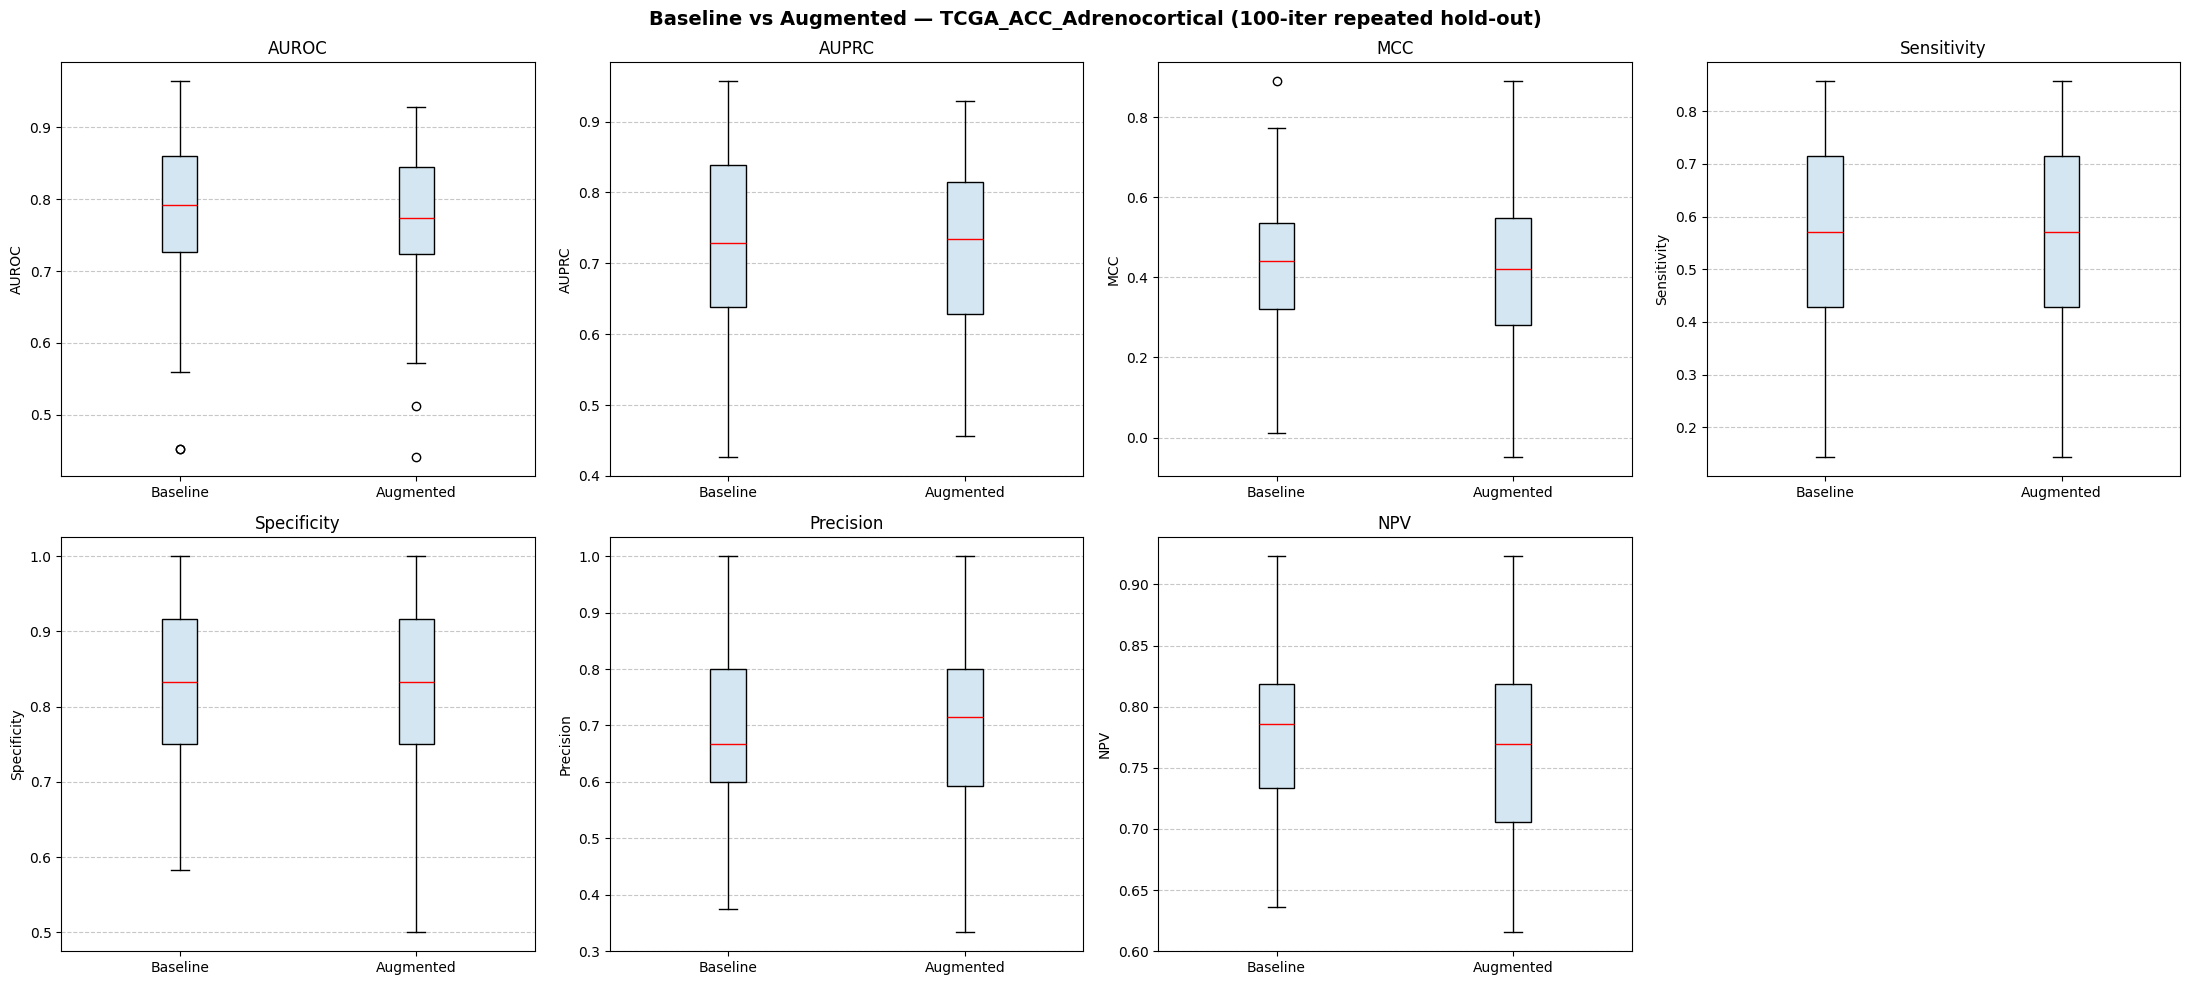

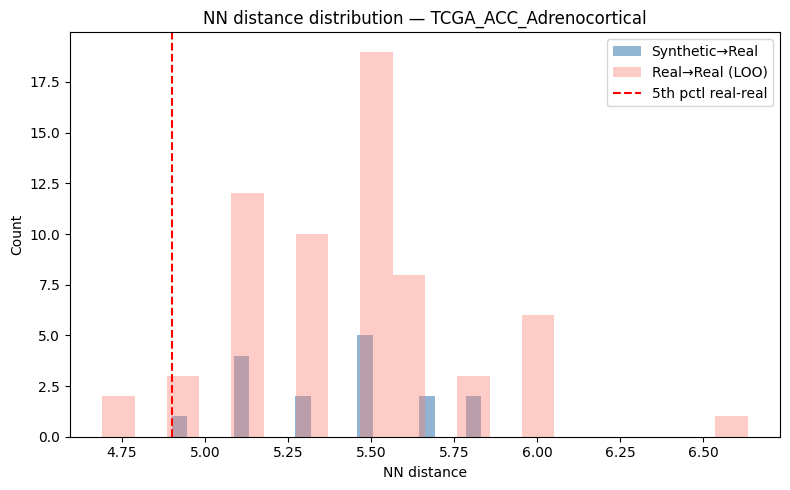

Synthetic records below 5th pctl real-real: 0/16
✅ No memorization evidence.

Brier (raw): 0.1321
Brier (cal): 0.2202


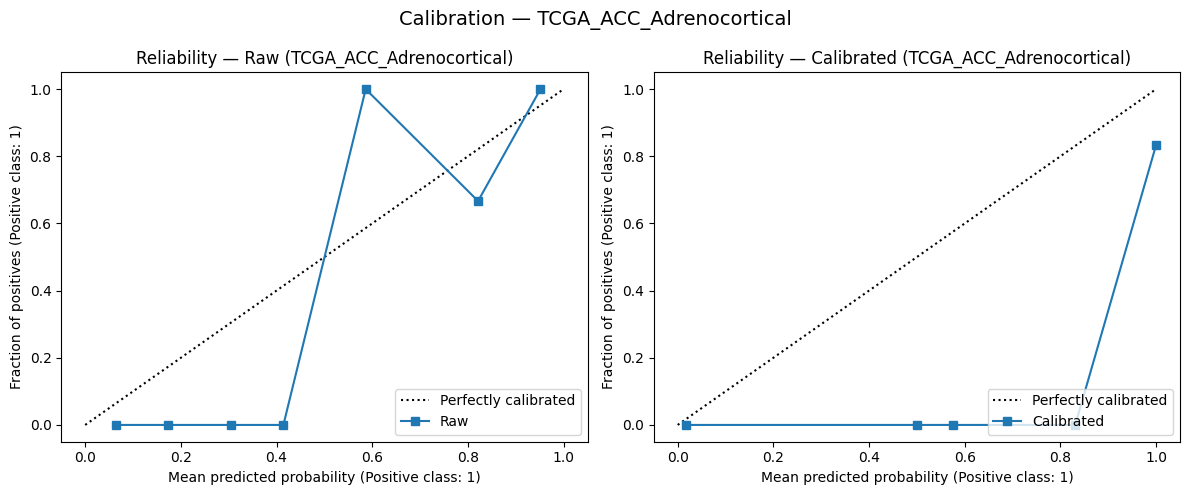

In [104]:
# ============================================================
# 13.8 — Comparison boxplots + Privacy audit + Calibration
# ============================================================

import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss

def _todense(M):
    return M.toarray() if hasattr(M, 'toarray') else np.asarray(M)

# --- A) Boxplots (all 7 metrics) ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()
for i, m in enumerate(ALL_METRICS):
    ax = axes_flat[i]
    ax.boxplot([cv_df[m], cv_aug[m]], labels=["Baseline", "Augmented"], patch_artist=True,
               boxprops=dict(facecolor="#d4e6f1"), medianprops=dict(color="red"))
    ax.set_title(f"{METRIC_LABELS[m]}", fontsize=12)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
axes_flat[7].set_visible(False)
plt.suptitle(f"Baseline vs Augmented — {DATASET_NAME_D3} ({N_REPEATS}-iter repeated hold-out)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# --- B) Privacy audit ---
if len(synthetic_cond) > 0:
    synth_aligned = synthetic_cond.reindex(columns=X_train.columns, fill_value=np.nan)
    Xtr_dense = _todense(pre.transform(X_train))
    Xs_dense = _todense(pre.transform(synth_aligned))
    nn = NearestNeighbors(n_neighbors=1).fit(Xtr_dense)
    dists_syn, _ = nn.kneighbors(Xs_dense)
    dists_syn = dists_syn.ravel()
    nn_real = NearestNeighbors(n_neighbors=2).fit(Xtr_dense)
    dists_real, _ = nn_real.kneighbors(Xtr_dense)
    dists_real = dists_real[:, 1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(dists_syn, bins=20, alpha=0.6, label="Synthetic→Real", color="steelblue")
    ax.hist(dists_real, bins=20, alpha=0.4, label="Real→Real (LOO)", color="salmon")
    ax.axvline(x=np.percentile(dists_real, 5), color='red', linestyle='--', label='5th pctl real-real')
    ax.set_xlabel("NN distance"); ax.set_ylabel("Count")
    ax.set_title(f"NN distance distribution — {DATASET_NAME_D3}")
    ax.legend(); plt.tight_layout(); plt.show()

    threshold = np.percentile(dists_real, 5)
    n_suspicious = int((dists_syn < threshold).sum())
    print(f"Synthetic records below 5th pctl real-real: {n_suspicious}/{len(dists_syn)}")
    print("✅ No memorization evidence." if n_suspicious == 0 else f"⚠️ {n_suspicious} records — review.")
else:
    print("No synthetic data generated (classes already balanced).")

# --- C) Calibration ---
proba_raw = clf_aug.predict_proba(Xte)[:, 1]
cal_iso = CalibratedClassifierCV(clf_aug, method='isotonic', cv='prefit')
cal_iso.fit(Xva, y_val)
proba_cal = cal_iso.predict_proba(Xte)[:, 1]

print(f"\nBrier (raw): {brier_score_loss(y_test, proba_raw):.4f}")
print(f"Brier (cal): {brier_score_loss(y_test, proba_cal):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
CalibrationDisplay.from_predictions(y_test, proba_raw, n_bins=8, ax=axes[0], name="Raw")
axes[0].set_title(f"Reliability — Raw ({DATASET_NAME_D3})")
CalibrationDisplay.from_predictions(y_test, proba_cal, n_bins=8, ax=axes[1], name="Calibrated")
axes[1].set_title(f"Reliability — Calibrated ({DATASET_NAME_D3})")
plt.suptitle(f"Calibration — {DATASET_NAME_D3}", fontsize=14)
plt.tight_layout(); plt.show()

Original feature dimensionality: 683
Training samples: 80
Feature/sample ratio: 8.5

[Strategy A — Naive] data_norm (95th pctl): 6.8557
[Strategy B — Mitigated] SelectKBest(k=15) + L2 norm → data_norm=1.0, feature/sample ratio: 0.19

DP Privacy-Utility — TCGA_ACC_Adrenocortical — Strategy: Naive
  Features: 683, data_norm: 6.86


,auroc_mean,auroc_std,auprc_mean,auprc_std,mcc_mean,mcc_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,precision_mean,precision_std,npv_mean,npv_std,ece_post_mean,brier_post_mean
epsilon,,,,,,,,,,,,,,,,
inf,0.940,0.000000,0.876667,0.000000,0.866025,0.000000,1.00,0.000000,0.90,0.000000,0.833333,0.000000,1.000000,0.000000,0.224164,0.218912
16.0,0.532,0.156109,0.378352,0.072662,0.062954,0.280464,0.72,0.389872,0.32,0.228035,0.324499,0.102047,0.634286,0.410773,0.159378,0.260053
8.0,0.462,0.057619,0.330000,0.007454,-0.095531,0.135477,0.72,0.389872,0.18,0.248998,0.283333,0.074536,0.225397,0.308688,0.112137,0.248876
4.0,0.472,0.062610,0.328000,0.011926,-0.057735,0.129099,0.72,0.389872,0.22,0.303315,0.300000,0.074536,0.244444,0.337017,0.090549,0.237569
2.0,0.498,0.139893,0.370159,0.075120,-0.023076,0.328280,0.48,0.303315,0.52,0.356371,0.374603,0.156472,0.550583,0.330512,0.062314,0.219059



DP Privacy-Utility — TCGA_ACC_Adrenocortical — Strategy: Mitigated
  Features: 15 (SelectKBest + L2 norm), data_norm: 1.0


,auroc_mean,auroc_std,auprc_mean,auprc_std,mcc_mean,mcc_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,precision_mean,precision_std,npv_mean,npv_std,ece_post_mean,brier_post_mean
epsilon,,,,,,,,,,,,,,,,
inf,0.960,0.000000,0.885714,0.000000,0.755929,0.000000,1.00,0.000000,0.80,0.000000,0.714286,0.000000,1.000000,0.000000,0.111111,0.082407
16.0,0.960,0.000000,0.885714,0.000000,0.755929,0.000000,1.00,0.000000,0.80,0.000000,0.714286,0.000000,1.000000,0.000000,0.111111,0.082407
8.0,0.960,0.000000,0.885714,0.000000,0.755929,0.000000,1.00,0.000000,0.80,0.000000,0.714286,0.000000,1.000000,0.000000,0.111111,0.082407
4.0,0.960,0.000000,0.885714,0.000000,0.736400,0.026741,0.84,0.219089,0.88,0.109545,0.828571,0.156492,0.933333,0.091287,0.111111,0.082407
2.0,0.752,0.255186,0.706667,0.203083,0.325483,0.359082,0.52,0.363318,0.76,0.433590,0.566667,0.434613,0.612121,0.349570,0.095636,0.122400


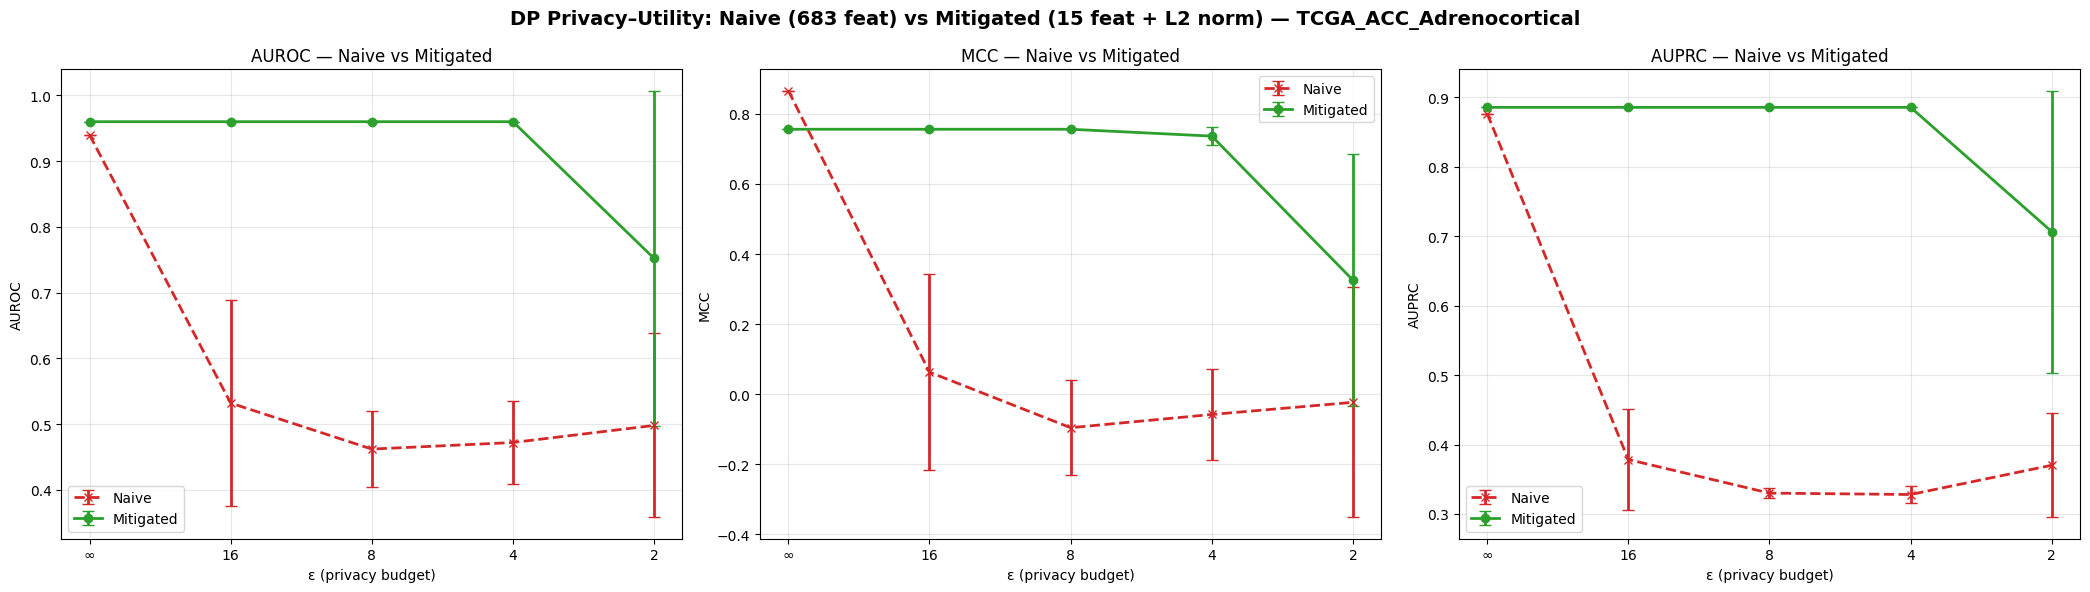


IMPROVEMENT FROM DIMENSIONALITY REDUCTION (Mitigated − Naive)


,ε,Naive AUROC,Mitig AUROC,ΔAUROC,Naive AUPRC,Mitig AUPRC,ΔAUPRC,Naive MCC,Mitig MCC,ΔMCC,...,ΔSensitivity,Naive Specificity,Mitig Specificity,ΔSpecificity,Naive Precision,Mitig Precision,ΔPrecision,Naive NPV,Mitig NPV,ΔNPV
0,∞,0.9400,0.9600,+0.0200,0.8767,0.8857,+0.0090,0.8660,0.7559,-0.1101,...,+0.0000,0.9000,0.8000,-0.1000,0.8333,0.7143,-0.1190,1.0000,1.0000,+0.0000
1,16,0.5320,0.9600,+0.4280,0.3784,0.8857,+0.5074,0.0630,0.7559,+0.6930,...,+0.2800,0.3200,0.8000,+0.4800,0.3245,0.7143,+0.3898,0.6343,1.0000,+0.3657
2,8,0.4620,0.9600,+0.4980,0.3300,0.8857,+0.5557,-0.0955,0.7559,+0.8515,...,+0.2800,0.1800,0.8000,+0.6200,0.2833,0.7143,+0.4310,0.2254,1.0000,+0.7746
3,4,0.4720,0.9600,+0.4880,0.3280,0.8857,+0.5577,-0.0577,0.7364,+0.7941,...,+0.1200,0.2200,0.8800,+0.6600,0.3000,0.8286,+0.5286,0.2444,0.9333,+0.6889
4,2,0.4980,0.7520,+0.2540,0.3702,0.7067,+0.3365,-0.0231,0.3255,+0.3486,...,+0.0400,0.5200,0.7600,+0.2400,0.3746,0.5667,+0.1921,0.5506,0.6121,+0.0615



✅ DP sweep complete — both strategies evaluated.
   Naive:     683 features, data_norm=6.86
   Mitigated: 15 features (SelectKBest + L2), data_norm=1.0


In [105]:
# ============================================================
# 13.9 — DP ε-sweep (TCGA-ACC) — with dimensionality-reduction mitigation
# ============================================================
# TCGA-ACC has 667 features after one-hot encoding on only 64 training samples.
# This extreme feature/sample ratio (~10:1) makes naive DP infeasible.
# We compare two strategies:
#   A) Naive: DP on full feature space (expected to fail)
#   B) Mitigated: SelectKBest(k=K_SEL) + L2 normalisation → data_norm=1.0
# This demonstrates that the framework works WITH appropriate preprocessing.
# ============================================================

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, matthews_corrcoef, confusion_matrix)
from sklearn.isotonic import IsotonicRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

try:
    from diffprivlib.models import LogisticRegression as DpLogReg
except ImportError:
    print("diffprivlib not installed"); DpLogReg = None

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0: continue
        ece += mask.sum() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece / len(y_true)

if DpLogReg is not None:
    X_train_dp = Xtr
    y_train_dp = combo_y
    X_val_dp = Xva
    X_test_dp = Xte

    # Convert to dense if sparse
    if hasattr(X_train_dp, 'toarray'):
        X_train_dp = X_train_dp.toarray()
    if hasattr(X_val_dp, 'toarray'):
        X_val_dp = X_val_dp.toarray()
    if hasattr(X_test_dp, 'toarray'):
        X_test_dp = X_test_dp.toarray()

    y_train_np = np.asarray(y_train_dp).ravel()
    y_val_np = np.asarray(y_val).ravel()
    y_test_np = np.asarray(y_test).ravel()

    print(f"Original feature dimensionality: {X_train_dp.shape[1]}")
    print(f"Training samples: {X_train_dp.shape[0]}")
    print(f"Feature/sample ratio: {X_train_dp.shape[1]/X_train_dp.shape[0]:.1f}")

    # ---- Strategy A: Naive (full features) ----
    norms_naive = np.linalg.norm(X_train_dp, axis=1)
    data_norm_naive = max(float(np.percentile(norms_naive, 95)), 1.0)
    print(f"\n[Strategy A — Naive] data_norm (95th pctl): {data_norm_naive:.4f}")

    # ---- Strategy B: Mitigated (SelectKBest + L2 norm) ----
    K_SEL = min(15, X_train_dp.shape[1])  # conservative for small-N
    selector = SelectKBest(mutual_info_classif, k=K_SEL)
    Xtr_sel = selector.fit_transform(X_train_dp, y_train_np)
    Xva_sel = selector.transform(X_val_dp)
    Xte_sel = selector.transform(X_test_dp)

    # L2 normalisation → guarantees ||x||_2 <= 1.0
    Xtr_norm = normalize(Xtr_sel, norm="l2")
    Xva_norm = normalize(Xva_sel, norm="l2")
    Xte_norm = normalize(Xte_sel, norm="l2")
    data_norm_mitigated = 1.0

    print(f"[Strategy B — Mitigated] SelectKBest(k={K_SEL}) + L2 norm → "
          f"data_norm={data_norm_mitigated:.1f}, "
          f"feature/sample ratio: {K_SEL/X_train_dp.shape[0]:.2f}")

    # ---- Run both sweeps ----
    epsilons = [float('inf'), 16, 8, 4, 2]
    N_SEEDS = 5
    dp_rows = []

    strategies = {
        "Naive": {
            "Xtr": X_train_dp, "Xva": X_val_dp, "Xte": X_test_dp,
            "data_norm": data_norm_naive
        },
        "Mitigated": {
            "Xtr": Xtr_norm, "Xva": Xva_norm, "Xte": Xte_norm,
            "data_norm": data_norm_mitigated
        },
    }

    for strat_name, strat in strategies.items():
        Xtr_s = strat["Xtr"]
        Xva_s = strat["Xva"]
        Xte_s = strat["Xte"]
        dn = strat["data_norm"]

        for eps in epsilons:
            for seed in range(N_SEEDS):
                if eps == float('inf'):
                    m = LogisticRegression(max_iter=2000, class_weight="balanced",
                                           random_state=seed)
                else:
                    m = DpLogReg(epsilon=eps, data_norm=dn, max_iter=2000,
                                 random_state=seed)

                m.fit(Xtr_s, y_train_np)

                # Evaluate on Test set
                p = np.clip(m.predict_proba(Xte_s)[:, 1], 1e-8, 1-1e-8)
                auroc = roc_auc_score(y_test_np, p)
                auprc = average_precision_score(y_test_np, p)

                # Post-hoc calibration using Validation set
                p_val = np.clip(m.predict_proba(Xva_s)[:, 1], 1e-8, 1-1e-8)
                iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
                iso.fit(p_val, y_val_np)
                p_cal = iso.predict(p)

                # Threshold-dependent metrics
                y_pred_dp = (p >= CLASSIFICATION_THRESHOLD).astype(int)
                cm = confusion_matrix(y_test_np, y_pred_dp, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()

                dp_rows.append({
                    'strategy': strat_name,
                    'epsilon': eps, 'seed': seed,
                    'auroc': auroc, 'auprc': auprc,
                    'mcc': matthews_corrcoef(y_test_np, y_pred_dp),
                    'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
                    'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
                    'precision': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
                    'npv': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
                    'ece_pre': expected_calibration_error(y_test_np, p, n_bins=10),
                    'ece_post': expected_calibration_error(y_test_np, p_cal, n_bins=10),
                    'brier_pre': brier_score_loss(y_test_np, p),
                    'brier_post': brier_score_loss(y_test_np, p_cal)
                })

    dp_df = pd.DataFrame(dp_rows)

    # ---- Summary tables per strategy ----
    agg_dict_dp = {
        'auroc_mean': ('auroc', 'mean'), 'auroc_std': ('auroc', 'std'),
        'auprc_mean': ('auprc', 'mean'), 'auprc_std': ('auprc', 'std'),
        'mcc_mean': ('mcc', 'mean'), 'mcc_std': ('mcc', 'std'),
        'sensitivity_mean': ('sensitivity', 'mean'), 'sensitivity_std': ('sensitivity', 'std'),
        'specificity_mean': ('specificity', 'mean'), 'specificity_std': ('specificity', 'std'),
        'precision_mean': ('precision', 'mean'), 'precision_std': ('precision', 'std'),
        'npv_mean': ('npv', 'mean'), 'npv_std': ('npv', 'std'),
        'ece_post_mean': ('ece_post', 'mean'), 'brier_post_mean': ('brier_post', 'mean')
    }

    for sname in ["Naive", "Mitigated"]:
        sub = dp_df[dp_df['strategy'] == sname]
        dp_summary = sub.groupby('epsilon').agg(**agg_dict_dp).sort_index(ascending=False)
        print(f"\n{'='*80}")
        print(f"DP Privacy-Utility — {DATASET_NAME_D3} — Strategy: {sname}")
        if sname == "Naive":
            print(f"  Features: {X_train_dp.shape[1]}, data_norm: {data_norm_naive:.2f}")
        else:
            print(f"  Features: {K_SEL} (SelectKBest + L2 norm), data_norm: {data_norm_mitigated:.1f}")
        print(f"{'='*80}")
        display(dp_summary)

    # ---- Comparison plot: Naive vs Mitigated ----
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    key_dp_metrics = ['auroc', 'mcc', 'auprc']
    titles = ['AUROC', 'MCC', 'AUPRC']

    for ax, metric, title in zip(axes, key_dp_metrics, titles):
        for sname, color, marker, ls in [("Naive", "#d62728", "x", "--"),
                                          ("Mitigated", "#2ca02c", "o", "-")]:
            sub = dp_df[dp_df['strategy'] == sname]
            summ = sub.groupby('epsilon').agg(
                mean=(metric, 'mean'), std=(metric, 'std')
            ).sort_index(ascending=False)
            eps_labels = [('∞' if np.isinf(e) else str(int(e))) for e in summ.index]
            x_pos = range(len(eps_labels))
            ax.errorbar(x_pos, summ['mean'], yerr=summ['std'],
                        marker=marker, linestyle=ls, color=color,
                        label=sname, capsize=4, linewidth=2)
        ax.set_xticks(range(len(eps_labels)))
        ax.set_xticklabels(eps_labels)
        ax.set_xlabel('ε (privacy budget)')
        ax.set_ylabel(title)
        ax.set_title(f'{title} — Naive vs Mitigated')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'DP Privacy–Utility: Naive ({X_train_dp.shape[1]} feat) vs '
                 f'Mitigated ({K_SEL} feat + L2 norm) — {DATASET_NAME_D3}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ---- Delta table: improvement from mitigation ----
    print(f"\n{'='*80}")
    print("IMPROVEMENT FROM DIMENSIONALITY REDUCTION (Mitigated − Naive)")
    print(f"{'='*80}")
    delta_rows = []
    for eps in epsilons:
        naive = dp_df[(dp_df['strategy'] == 'Naive') & (dp_df['epsilon'] == eps)]
        mitig = dp_df[(dp_df['strategy'] == 'Mitigated') & (dp_df['epsilon'] == eps)]
        eps_str = '∞' if np.isinf(eps) else str(int(eps))
        row = {'ε': eps_str}
        for m_key in ALL_METRICS:
            n_mu = naive[m_key].mean()
            m_mu = mitig[m_key].mean()
            row[f'Naive {METRIC_LABELS[m_key]}'] = f"{n_mu:.4f}"
            row[f'Mitig {METRIC_LABELS[m_key]}'] = f"{m_mu:.4f}"
            row[f'Δ{METRIC_LABELS[m_key]}'] = f"{m_mu - n_mu:+.4f}"
        delta_rows.append(row)
    delta_df = pd.DataFrame(delta_rows)
    display(delta_df)

    print(f"\n✅ DP sweep complete — both strategies evaluated.")
    print(f"   Naive:     {X_train_dp.shape[1]} features, data_norm={data_norm_naive:.2f}")
    print(f"   Mitigated: {K_SEL} features (SelectKBest + L2), data_norm={data_norm_mitigated:.1f}")

FINAL CROSS-DATASET COMPARISON: GSE3960 vs dataYM2018 vs TCGA-ACC (7 metrics)


,Dataset,Disease,N,Features,Base AUROC,Aug AUROC,ΔAUROC,Base AUPRC,Aug AUPRC,ΔAUPRC,...,ΔSensitivity,Base Specificity,Aug Specificity,ΔSpecificity,Base Precision,Aug Precision,ΔPrecision,Base NPV,Aug NPV,ΔNPV
0,GSE3960,Neuroblastoma,101,7,0.9400 ± 0.0615,0.9407 ± 0.0677,+0.0007,0.8388 ± 0.1463,0.8557 ± 0.1361,+0.0169,...,+0.0000,0.9112 ± 0.0692,0.9382 ± 0.0587,+0.0271,0.7206 ± 0.1805,0.7899 ± 0.1811,+0.0693,0.9550 ± 0.0383,0.9565 ± 0.0394,+0.0015
1,dataYM2018 (Shanghai),Neuroblastoma,173,12,0.8407 ± 0.0624,0.8407 ± 0.0624,+0.0000,0.9450 ± 0.0244,0.9450 ± 0.0244,+0.0000,...,+0.0000,0.6644 ± 0.1506,0.6644 ± 0.1506,+0.0000,0.8737 ± 0.0514,0.8737 ± 0.0514,+0.0000,0.5263 ± 0.1017,0.5263 ± 0.1017,+0.0000
2,TCGA-ACC (Adrenocortical),Adrenocortical Ca.,92,47,0.7835 ± 0.1050,0.7757 ± 0.0980,-0.0077,0.7302 ± 0.1236,0.7229 ± 0.1219,-0.0073,...,-0.0286,0.8492 ± 0.1017,0.8492 ± 0.1115,+0.0000,0.7116 ± 0.1479,0.7069 ± 0.1754,-0.0048,0.7747 ± 0.0630,0.7620 ± 0.0678,-0.0127


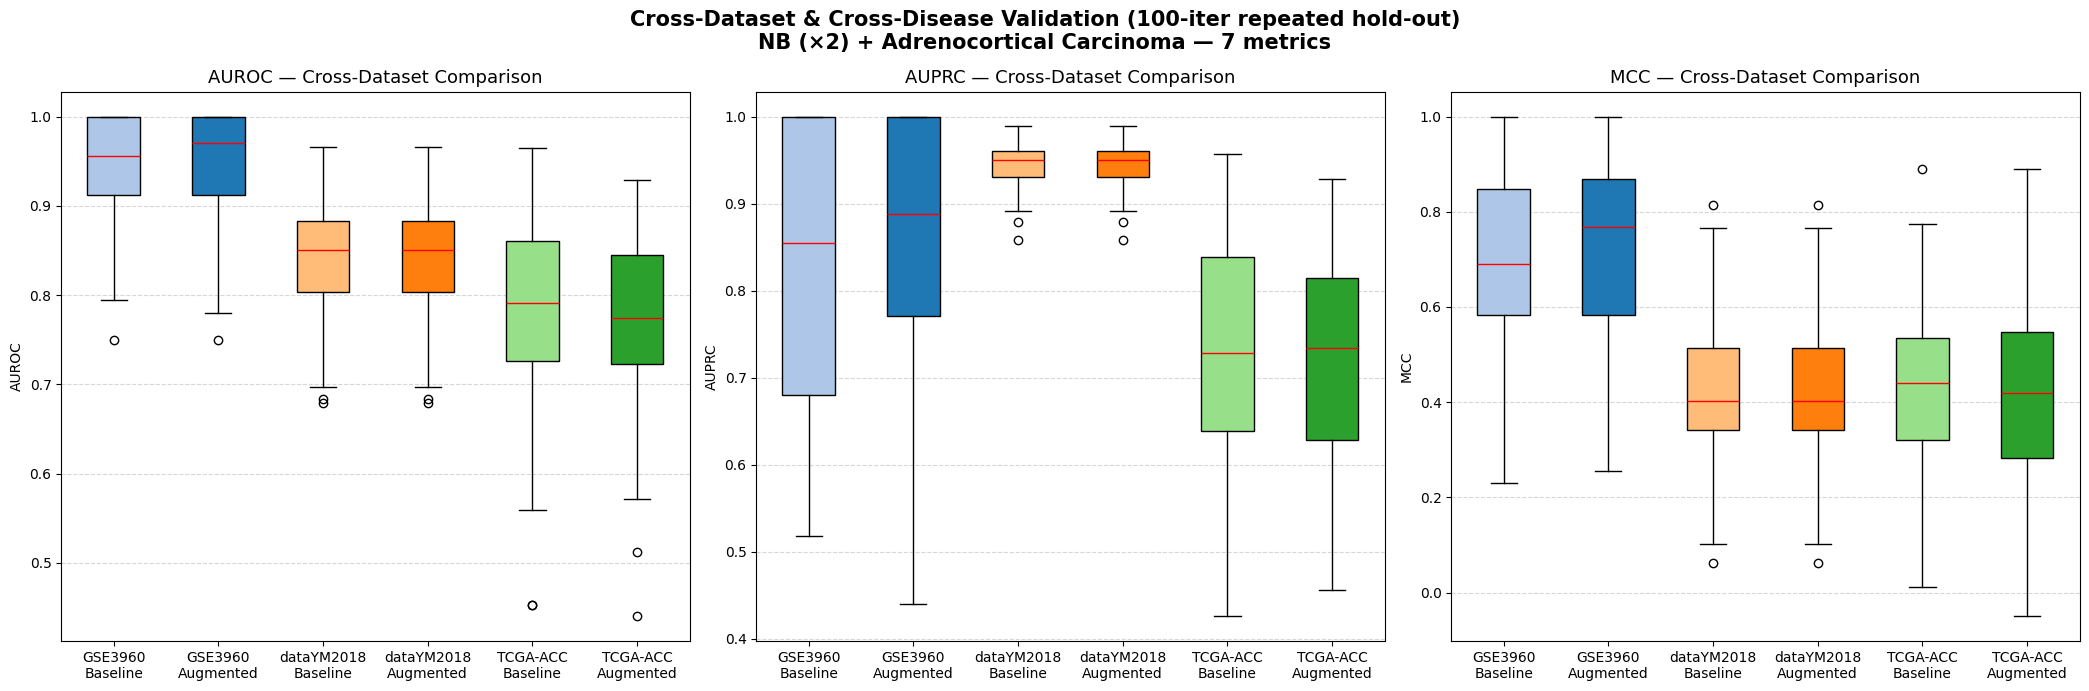

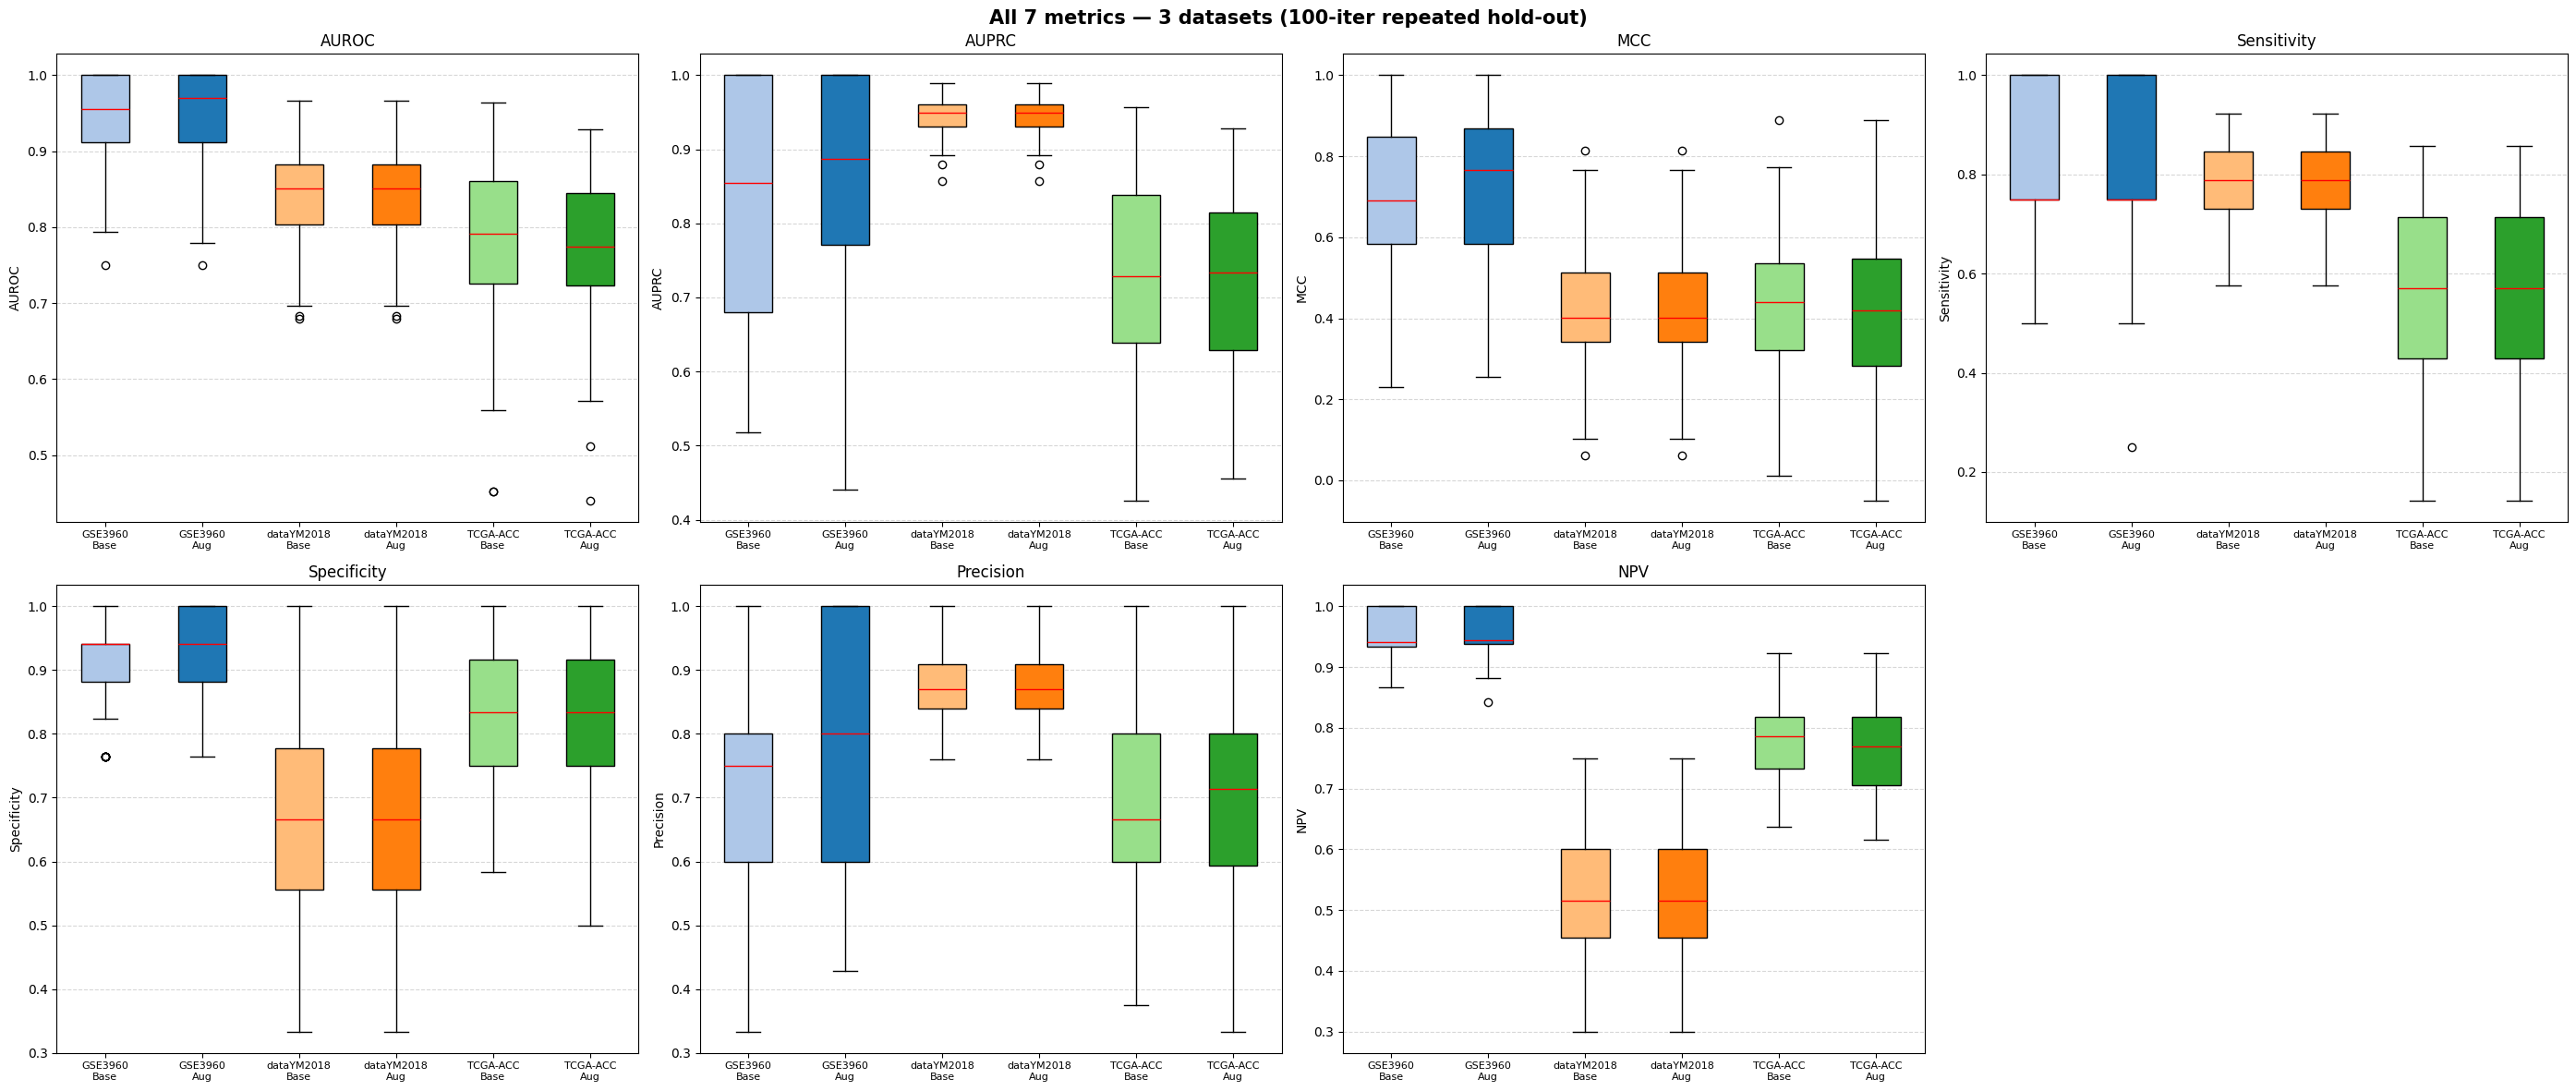


✅ FULL CROSS-DATASET + CROSS-DISEASE VALIDATION COMPLETE (7 metrics)
   → 2 NB cohorts (GSE3960, dataYM2018)
   → 1 rare endocrine cancer (TCGA-ACC, Adrenocortical Carcinoma)
   → Metrics: AUROC, AUPRC, MCC, Sensitivity, Specificity, Precision, NPV
   → Results ready for paper integration.


In [106]:
# ============================================================
# 13.10 — FINAL cross-dataset comparison (3 datasets, 7 metrics)
# ============================================================

import matplotlib.pyplot as plt

DATASET_NAME_D3 = "TCGA_ACC_Adrenocortical"

results_acc = {
    "dataset": "TCGA-ACC (Adrenocortical)",
    "n_samples": len(df3),
    "n_features": df3.shape[1] - 1,
    "target": TARGET_COLUMN_D3,
    "cv_baseline": cv_df.copy(),
    "cv_augmented": cv_aug.copy(),
}
for m in ALL_METRICS:
    results_acc[f"baseline_{m}_mean"] = cv_df[m].mean()
    results_acc[f"baseline_{m}_std"]  = cv_df[m].std()
    results_acc[f"aug_{m}_mean"]      = cv_aug[m].mean()
    results_acc[f"aug_{m}_std"]       = cv_aug[m].std()

all_results = [results_gse3960, results_ym2018, results_acc]

print("=" * 110)
print("FINAL CROSS-DATASET COMPARISON: GSE3960 vs dataYM2018 vs TCGA-ACC (7 metrics)")
print("=" * 110)

rows_comp = []
for r in all_results:
    disease = "Neuroblastoma" if "GSE" in r["dataset"] or "YM" in r["dataset"] else "Adrenocortical Ca."
    row = {"Dataset": r["dataset"], "Disease": disease,
           "N": r["n_samples"], "Features": r["n_features"]}
    for m in ALL_METRICS:
        b_mu = r.get(f"baseline_{m}_mean", float("nan"))
        b_sd = r.get(f"baseline_{m}_std", float("nan"))
        a_mu = r.get(f"aug_{m}_mean", float("nan"))
        a_sd = r.get(f"aug_{m}_std", float("nan"))
        row[f"Base {METRIC_LABELS[m]}"] = f"{b_mu:.4f} ± {b_sd:.4f}"
        row[f"Aug {METRIC_LABELS[m]}"]  = f"{a_mu:.4f} ± {a_sd:.4f}"
        row[f"Δ{METRIC_LABELS[m]}"]     = f"{a_mu - b_mu:+.4f}"
    rows_comp.append(row)

comparison = pd.DataFrame(rows_comp)
display(comparison)

# --- Side-by-side boxplots (all 3 datasets, key metrics) ---
key_metrics = ["auroc", "auprc", "mcc"]
fig, axes = plt.subplots(1, len(key_metrics), figsize=(7 * len(key_metrics), 7))

palette = {
    "GSE3960":                    ("#aec7e8", "#1f77b4"),
    "dataYM2018 (Shanghai)":      ("#ffbb78", "#ff7f0e"),
    "TCGA-ACC (Adrenocortical)":  ("#98df8a", "#2ca02c"),
}

for i, m in enumerate(key_metrics):
    ax = axes[i]
    data = []
    labels = []
    colors_list = []
    for r in all_results:
        short = r['dataset'].split('(')[0].strip()[:12]
        c_light, c_dark = palette.get(r['dataset'], ("#cccccc", "#666666"))
        data.append(r["cv_baseline"][m])
        labels.append(f"{short}\nBaseline")
        colors_list.append(c_light)
        data.append(r["cv_augmented"][m])
        labels.append(f"{short}\nAugmented")
        colors_list.append(c_dark)

    bp = ax.boxplot(data, labels=labels, patch_artist=True, medianprops=dict(color="red"))
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
    ax.set_title(f"{METRIC_LABELS[m]} — Cross-Dataset Comparison", fontsize=13)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.suptitle(f"Cross-Dataset & Cross-Disease Validation ({N_REPEATS}-iter repeated hold-out)\n"
             f"NB (×2) + Adrenocortical Carcinoma — 7 metrics",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Full 7-metric panel (all datasets) ---
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
axes_flat = axes.flatten()

for idx, m in enumerate(ALL_METRICS):
    ax = axes_flat[idx]
    data = []
    labels = []
    colors_list = []
    for r in all_results:
        short = r['dataset'].split('(')[0].strip()[:12]
        c_light, c_dark = palette.get(r['dataset'], ("#cccccc", "#666666"))
        data.append(r["cv_baseline"][m])
        labels.append(f"{short}\nBase")
        colors_list.append(c_light)
        data.append(r["cv_augmented"][m])
        labels.append(f"{short}\nAug")
        colors_list.append(c_dark)

    bp = ax.boxplot(data, labels=labels, patch_artist=True, medianprops=dict(color="red"))
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
    ax.set_title(METRIC_LABELS[m], fontsize=12)
    ax.set_ylabel(METRIC_LABELS[m])
    ax.grid(True, axis="y", ls="--", alpha=0.5)
    ax.tick_params(axis='x', labelsize=8)

axes_flat[7].set_visible(False)
plt.suptitle(f"All 7 metrics — 3 datasets ({N_REPEATS}-iter repeated hold-out)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 110)
print("✅ FULL CROSS-DATASET + CROSS-DISEASE VALIDATION COMPLETE (7 metrics)")
print("   → 2 NB cohorts (GSE3960, dataYM2018)")
print("   → 1 rare endocrine cancer (TCGA-ACC, Adrenocortical Carcinoma)")
print("   → Metrics: AUROC, AUPRC, MCC, Sensitivity, Specificity, Precision, NPV")
print("   → Results ready for paper integration.")
print("=" * 110)